In [ ]:
# ================================================================
# SECTION 1
# DATA PREPROCESSING & SEVEN-FEATURE CONSTRUCTION
# ================================================================
#
# Research:
# Development of an Edge AI Framework for Real-Time Detection
# of Petroleum Product Adulteration
#
# Purpose:
# 1. Load the completed 216,080-row physics-guided raw dataset
# 2. Perform strict data-quality and experimental-design checks
# 3. Generate Optical Sensor from Refractive Index + Colour
# 4. Generate Temperature during preprocessing
# 5. Construct the final seven model input features
# 6. Construct four prediction targets
# 7. Perform condition-aware train/validation/test splitting
# 8. Fit StandardScaler using TRAINING data only
# 9. Save all preprocessing objects and processed datasets
#
# IMPORTANT:
# - Raw dataset contains FIVE physicochemical properties.
# - Optical Sensor and Temperature are NOT added to the raw CSV.
# - Optical Sensor and Temperature are generated here before training.
# - The final LMT-ANN uses SEVEN input features.
# - Laboratory data are NOT used in this section.
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import json
import pickle
import random
import warnings

import numpy as np
import pandas as pd

from pathlib import Path
from IPython.display import display

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


warnings.filterwarnings("ignore")


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# ================================================================
# 3. PROJECT DIRECTORIES
# ================================================================

PROJECT_ROOT = Path("/content/physics_guided_petroleum_dataset")

DATASET_DIR = PROJECT_ROOT / "01_Dataset"
PREPROCESSING_DIR = PROJECT_ROOT / "05_Preprocessing"

DATASET_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSING_DIR.mkdir(parents=True, exist_ok=True)


# ================================================================
# 4. LOCATE RAW DATASET
# ================================================================

possible_dataset_paths = [
    Path("/content/physics_guided_petroleum_adulteration.csv"),
    PROJECT_ROOT / "physics_guided_petroleum_adulteration.csv",
    DATASET_DIR / "physics_guided_petroleum_adulteration.csv",
]

dataset_path = None

for path in possible_dataset_paths:
    if path.exists():
        dataset_path = path
        break


if dataset_path is None:

    csv_files = list(Path("/content").glob("*.csv"))

    if len(csv_files) == 1:
        dataset_path = csv_files[0]

    else:
        raise FileNotFoundError(
            "Could not locate the completed raw dataset.\n\n"
            "Expected filename:\n"
            "physics_guided_petroleum_adulteration.csv"
        )


print("=" * 80)
print("SECTION 1 — DATA PREPROCESSING & SEVEN-FEATURE CONSTRUCTION")
print("=" * 80)

print(f"\nRaw dataset:")
print(dataset_path)


# ================================================================
# 5. LOAD RAW DATASET
# ================================================================
#
# IMPORTANT:
# keep_default_na=False is intentional.
#
# The raw dataset uses the literal string:
#
#     None
#
# to represent pure fuel / no adulterant.
#
# We therefore MUST NOT allow pandas to convert "None" into NaN.
# ================================================================

data = pd.read_csv(
    dataset_path,
    keep_default_na=False
)

print("\nDataset loaded successfully.")
print(f"Rows    : {len(data):,}")
print(f"Columns : {len(data.columns)}")


# ================================================================
# 6. EXPECTED RAW DATASET STRUCTURE
# ================================================================

EXPECTED_COLUMNS = [
    "Sample_ID",
    "Base_Fuel",
    "Adulterant",
    "Adulteration_%",
    "Base_Volume_mL",
    "Adulterant_Volume_mL",
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Colour_Value",
]

print("\nChecking raw dataset columns...")

if list(data.columns) != EXPECTED_COLUMNS:

    print("\nActual columns:")
    print(list(data.columns))

    print("\nExpected columns:")
    print(EXPECTED_COLUMNS)

    raise ValueError(
        "\nRaw dataset columns do not exactly match the expected structure."
    )

print("✓ Raw dataset columns are correct.")


# ================================================================
# 7. RAW DATASET SIZE CHECK
# ================================================================

EXPECTED_ROWS = 216_080

if len(data) != EXPECTED_ROWS:

    raise ValueError(
        f"\nExpected {EXPECTED_ROWS:,} rows, "
        f"but found {len(data):,} rows."
    )

print(f"✓ Exact row count confirmed: {EXPECTED_ROWS:,}")


# ================================================================
# 8. CONFIRM RAW DATASET DOES NOT ALREADY CONTAIN
#    THE TWO ENGINEERED FEATURES OR MODEL TARGETS
# ================================================================

FORBIDDEN_RAW_COLUMNS = [
    "Optical_Sensor",
    "Temperature",
    "Temperature_C",
    "Label",
    "Fuel_Target",
    "Status_Target",
    "Adulterant_Target",
    "Adulteration_Percentage_Target",
]

unexpected_columns = [
    col for col in FORBIDDEN_RAW_COLUMNS
    if col in data.columns
]

if unexpected_columns:

    raise ValueError(
        "\nThe raw dataset contains columns that should only be "
        "created during preprocessing:\n"
        f"{unexpected_columns}"
    )

print("✓ Raw dataset contains no engineered model features or targets.")


# ================================================================
# 9. CHECK FOR DUPLICATE RAW ROWS
# ================================================================

duplicate_rows = data.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_rows:,}")

if duplicate_rows > 0:

    raise ValueError(
        "Duplicate rows detected in the raw dataset."
    )

print("✓ No duplicate rows.")


# ================================================================
# 10. CHECK MISSING VALUES
# ================================================================
#
# Because keep_default_na=False was used, the literal "None"
# remains a valid categorical value.
#
# Therefore, actual missing values should be ZERO.
# ================================================================

missing_values = data.isnull().sum()

total_missing = int(missing_values.sum())

print(f"\nTotal actual missing values: {total_missing:,}")

if total_missing > 0:

    print("\nVariables containing missing values:")
    display(
        missing_values[
            missing_values > 0
        ].to_frame("Missing_Count")
    )

    raise ValueError(
        "Unexpected missing values detected."
    )

print("✓ No actual missing values.")


# ================================================================
# 11. BASIC DATA TYPES
# ================================================================

numeric_columns = [
    "Sample_ID",
    "Adulteration_%",
    "Base_Volume_mL",
    "Adulterant_Volume_mL",
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Colour_Value",
]

for col in numeric_columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="raise"
    )


# ================================================================
# 12. CHECK NUMERIC VALUES ARE FINITE
# ================================================================

numeric_array = data[numeric_columns].to_numpy(dtype=float)

if not np.isfinite(numeric_array).all():

    raise ValueError(
        "Non-finite numeric values detected."
    )

print("✓ All numeric values are finite.")


# ================================================================
# 13. VALID FUEL TYPES
# ================================================================

VALID_FUELS = {
    "PMS",
    "AGO",
    "DPK",
}

actual_fuels = set(
    data["Base_Fuel"].unique()
)

print("\nBase fuels found:")
print(sorted(actual_fuels))

if actual_fuels != VALID_FUELS:

    raise ValueError(
        "\nUnexpected base fuel categories.\n"
        f"Expected: {sorted(VALID_FUELS)}\n"
        f"Found   : {sorted(actual_fuels)}"
    )

print("✓ Base fuel categories are correct.")


# ================================================================
# 14. VALID ADULTERANTS
# ================================================================

VALID_ADULTERANTS = {
    "None",
    "Kerosene",
    "AGO",
    "Water",
    "Waste_Engine_Oil",
    "Methanol",
    "Ethanol",
}

actual_adulterants = set(
    data["Adulterant"].unique()
)

print("\nAdulterants found:")
print(sorted(actual_adulterants))

if not actual_adulterants.issubset(
    VALID_ADULTERANTS
):

    unexpected = (
        actual_adulterants -
        VALID_ADULTERANTS
    )

    raise ValueError(
        "\nUnexpected adulterant categories:\n"
        f"{unexpected}"
    )

print("✓ Adulterant categories are correct.")


# ================================================================
# 15. VALID ADULTERATION LEVELS
# ================================================================

VALID_LEVELS = [
    0,
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45,
    50,
]

actual_levels = sorted(
    data["Adulteration_%"].unique()
)

print("\nAdulteration levels:")
print(actual_levels)

if actual_levels != VALID_LEVELS:

    raise ValueError(
        "\nUnexpected adulteration levels.\n"
        f"Expected: {VALID_LEVELS}\n"
        f"Found   : {actual_levels}"
    )

print("✓ Adulteration levels are correct.")


# ================================================================
# 16. PURE-FUEL CHECK
# ================================================================
#
# Pure fuel must satisfy:
#
# Adulterant = None
# Adulteration_% = 0
# Base volume = 200 mL
# Adulterant volume = 0 mL
# ================================================================

pure_mask = (
    data["Adulteration_%"] == 0
)

if not (
    data.loc[pure_mask, "Adulterant"]
    .eq("None")
    .all()
):

    raise ValueError(
        "Some 0% observations do not have Adulterant = None."
    )

if not (
    data.loc[pure_mask, "Base_Volume_mL"]
    .eq(200)
    .all()
):

    raise ValueError(
        "Some pure observations do not contain 200 mL base fuel."
    )

if not (
    data.loc[pure_mask, "Adulterant_Volume_mL"]
    .eq(0)
    .all()
):

    raise ValueError(
        "Some pure observations have non-zero adulterant volume."
    )

print("✓ Pure-fuel observations are correctly defined.")


# ================================================================
# 17. ADULTERATED-FUEL CHECK
# ================================================================

adulterated_mask = (
    data["Adulteration_%"] > 0
)

if not (
    data.loc[adulterated_mask, "Adulterant"]
    .ne("None")
    .all()
):

    raise ValueError(
        "Some adulterated observations have Adulterant = None."
    )

print("✓ Adulterated observations are correctly defined.")


# ================================================================
# 18. TOTAL MIXTURE VOLUME CHECK
# ================================================================

total_volume = (
    data["Base_Volume_mL"] +
    data["Adulterant_Volume_mL"]
)

if not np.allclose(
    total_volume,
    200.0,
    atol=1e-9
):

    raise ValueError(
        "Some mixtures do not have a total volume of 200 mL."
    )

print("✓ All mixtures have total volume = 200 mL.")


# ================================================================
# 19. VOLUME / CONCENTRATION CONSISTENCY CHECK
# ================================================================

expected_adulterant_volume = (
    200 *
    data["Adulteration_%"] /
    100
)

if not np.allclose(
    data["Adulterant_Volume_mL"],
    expected_adulterant_volume,
    atol=1e-9
):

    raise ValueError(
        "Adulterant volumes are inconsistent with adulteration percentages."
    )

expected_base_volume = (
    200 -
    expected_adulterant_volume
)

if not np.allclose(
    data["Base_Volume_mL"],
    expected_base_volume,
    atol=1e-9
):

    raise ValueError(
        "Base volumes are inconsistent with adulteration percentages."
    )

print("✓ Volume and adulteration percentage relationships are correct.")


# ================================================================
# 20. VALID ADULTERATION PAIRS
# ================================================================
#
# These are the 16 valid base-fuel/adulterant combinations.
#
# Excluded:
# AGO + AGO
# DPK + Kerosene
#
# The exact raw spelling Waste_Engine_Oil is retained.
# ================================================================

VALID_PAIRS = {
    ("PMS", "Kerosene"),
    ("PMS", "AGO"),
    ("PMS", "Water"),
    ("PMS", "Waste_Engine_Oil"),
    ("PMS", "Methanol"),
    ("PMS", "Ethanol"),

    ("AGO", "Kerosene"),
    ("AGO", "Water"),
    ("AGO", "Waste_Engine_Oil"),
    ("AGO", "Methanol"),
    ("AGO", "Ethanol"),

    ("DPK", "AGO"),
    ("DPK", "Water"),
    ("DPK", "Waste_Engine_Oil"),
    ("DPK", "Methanol"),
    ("DPK", "Ethanol"),
}


# Check all adulterated pairs
actual_pairs = set(
    zip(
        data.loc[adulterated_mask, "Base_Fuel"],
        data.loc[adulterated_mask, "Adulterant"]
    )
)

unexpected_pairs = actual_pairs - VALID_PAIRS

if unexpected_pairs:

    raise ValueError(
        "\nUnexpected adulteration pairs detected:\n"
        f"{unexpected_pairs}"
    )

missing_pairs = VALID_PAIRS - actual_pairs

if missing_pairs:

    raise ValueError(
        "\nExpected valid adulteration pairs missing from dataset:\n"
        f"{missing_pairs}"
    )

print(
    f"✓ All {len(VALID_PAIRS)} valid adulteration pairs are present."
)


# ================================================================
# 21. VERIFY EXCLUDED COMBINATIONS ARE ABSENT
# ================================================================

EXCLUDED_PAIRS = {
    ("AGO", "AGO"),
    ("DPK", "Kerosene"),
}

for base, adulterant in EXCLUDED_PAIRS:

    exists = (
        (data["Base_Fuel"] == base) &
        (data["Adulterant"] == adulterant)
    ).any()

    if exists:

        raise ValueError(
            f"Excluded pair found: {base} + {adulterant}"
        )

print("✓ Excluded adulteration pairs are absent.")


# ================================================================
# 22. CHECK RAW PROPERTY RANGES
# ================================================================

property_columns = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Colour_Value",
]

print("\nRaw property ranges:")

property_summary = data[property_columns].agg(
    ["min", "max", "mean", "std"]
).T

display(property_summary)


# ================================================================
# 23. CREATE CONDITION ID
# ================================================================
#
# A physical condition is defined by:
#
# Base_Fuel
# + Adulterant
# + Adulteration_%
#
# Each adulterated condition has repeated simulated observations.
#
# Pure fuel observations use:
# Base_Fuel + Pure + 0
# ================================================================

data["Condition_ID"] = (
    data["Base_Fuel"].astype(str)
    + "__"
    + data["Adulterant"].astype(str)
    + "__"
    + data["Adulteration_%"].astype(str)
)

print(
    f"\nNumber of unique physical conditions: "
    f"{data['Condition_ID'].nunique():,}"
)


# ================================================================
# 24. VERIFY EXPECTED NUMBER OF CONDITIONS
# ================================================================

expected_adulterated_conditions = (
    len(VALID_PAIRS) * 10
)

expected_pure_conditions = 3

expected_total_conditions = (
    expected_adulterated_conditions +
    expected_pure_conditions
)

actual_total_conditions = (
    data["Condition_ID"].nunique()
)

print(
    f"Expected conditions: {expected_total_conditions}"
)

print(
    f"Actual conditions  : {actual_total_conditions}"
)

if actual_total_conditions != expected_total_conditions:

    raise ValueError(
        "Unexpected number of physical conditions."
    )

print("✓ Condition structure is correct.")


# ================================================================
# 25. VERIFY REPEATED OBSERVATION STRUCTURE
# ================================================================

condition_counts = (
    data.groupby("Condition_ID")
    .size()
)

print("\nCondition observation counts:")
print(
    condition_counts
    .value_counts()
    .sort_index()
)


# ================================================================
# 26. VERIFY ADULTERATED CONDITION REPETITIONS
# ================================================================

adulterated_condition_ids = (
    data.loc[adulterated_mask, "Condition_ID"]
    .unique()
)

adulterated_condition_counts = (
    data.loc[
        data["Condition_ID"].isin(
            adulterated_condition_ids
        )
    ]
    .groupby("Condition_ID")
    .size()
)

if not (
    adulterated_condition_counts
    .eq(875)
    .all()
):

    raise ValueError(
        "Adulterated conditions do not contain exactly "
        "875 observations each."
    )

print(
    f"\n✓ Each adulterated physical condition contains "
    f"{adulterated_condition_counts.iloc[0]:,} realizations."
)


# ================================================================
# 27. GENERATE OPTICAL SENSOR
# ================================================================
#
# IMPORTANT:
#
# Optical Sensor is NOT an independent raw physicochemical property.
#
# It is derived during preprocessing from:
#
# Refractive Index
# + Colour
#
# Model:
#
# Optical_Sensor =
#       (100 × Refractive_Index)
#     + (10 × Colour_Value)
#     + Gaussian disturbance
#
# Gaussian noise:
#     mean = 0
#     SD   = 1.0
#
# This follows the simulation methodology.
# ================================================================

OPTICAL_SENSOR_NOISE_SD = 1.0

optical_noise = np.random.normal(
    loc=0.0,
    scale=OPTICAL_SENSOR_NOISE_SD,
    size=len(data)
)

data["Optical_Sensor"] = (
    (100.0 * data["Refractive_Index"])
    +
    (10.0 * data["Colour_Value"])
    +
    optical_noise
)

print("\n✓ Optical Sensor generated from Refractive Index + Colour.")


# ================================================================
# 28. GENERATE TEMPERATURE
# ================================================================
#
# Representative operating / measurement temperatures:
#
# 20°C
# 25°C
# 30°C
# 35°C
#
# Gaussian disturbance:
# SD = ±0.8°C
#
# IMPORTANT:
# Temperature is a simulated operating/measurement condition.
# It is NOT being claimed as an independent measured property.
# ================================================================

TEMPERATURE_LEVELS = np.array([
    20.0,
    25.0,
    30.0,
    35.0,
])

TEMPERATURE_NOISE_SD = 0.8

base_temperatures = np.random.choice(
    TEMPERATURE_LEVELS,
    size=len(data),
    replace=True
)

temperature_noise = np.random.normal(
    loc=0.0,
    scale=TEMPERATURE_NOISE_SD,
    size=len(data)
)

data["Temperature"] = (
    base_temperatures +
    temperature_noise
)

print(
    "✓ Temperature generated using 20, 25, 30 and 35°C "
    "operating levels with Gaussian disturbance."
)


# ================================================================
# 29. CHECK ENGINEERED FEATURES
# ================================================================

engineered_features = [
    "Optical_Sensor",
    "Temperature",
]

if not np.isfinite(
    data[engineered_features]
    .to_numpy(dtype=float)
).all():

    raise ValueError(
        "Non-finite values detected in engineered features."
    )

print("✓ Engineered features contain only finite values.")


# ================================================================
# 30. DEFINE THE FINAL SEVEN MODEL INPUT FEATURES
# ================================================================

FEATURE_COLUMNS = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature",
]

print("\nFINAL SEVEN MODEL INPUT FEATURES:")
for i, feature in enumerate(
    FEATURE_COLUMNS,
    start=1
):
    print(f"{i}. {feature}")


if len(FEATURE_COLUMNS) != 7:

    raise ValueError(
        "The model must use exactly seven input features."
    )


# ================================================================
# 31. CONSTRUCT FOUR TARGETS
# ================================================================

# ------------------------------------------------
# Target 1: Fuel Type
# ------------------------------------------------

data["Fuel_Target"] = data["Base_Fuel"]


# ------------------------------------------------
# Target 2: Fuel Status
#
# 0 = Pure
# 1 = Adulterated
# ------------------------------------------------

data["Status_Target"] = (
    data["Adulteration_%"] > 0
).astype(int)


# ------------------------------------------------
# Target 3: Adulterant
#
# Pure fuel:
#     None → No_Adulterant
# ------------------------------------------------

data["Adulterant_Target"] = (
    data["Adulterant"]
)

data.loc[
    data["Adulterant_Target"] == "None",
    "Adulterant_Target"
] = "No_Adulterant"


# ------------------------------------------------
# Target 4: Adulteration Percentage
# ------------------------------------------------

data["Adulteration_Percentage_Target"] = (
    data["Adulteration_%"]
    .astype(np.float32)
)


print("\n✓ Four prediction targets constructed.")


# ================================================================
# 32. TARGET DISTRIBUTION CHECK
# ================================================================

print("\nFuel target distribution:")
display(
    data["Fuel_Target"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)


print("\nFuel status distribution:")
display(
    data["Status_Target"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)


print("\nAdulterant target distribution:")
display(
    data["Adulterant_Target"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)


# ================================================================
# 33. BUILD MODEL DATAFRAME
# ================================================================

MODEL_COLUMNS = (
    FEATURE_COLUMNS
    +
    [
        "Fuel_Target",
        "Status_Target",
        "Adulterant_Target",
        "Adulteration_Percentage_Target",
        "Condition_ID",
        "Sample_ID",
    ]
)

model_data = data[MODEL_COLUMNS].copy()


# ================================================================
# 34. VERIFY MODEL DATA
# ================================================================

if model_data[FEATURE_COLUMNS].isnull().sum().sum() > 0:

    raise ValueError(
        "Missing values found in model input features."
    )

if not np.isfinite(
    model_data[FEATURE_COLUMNS]
    .to_numpy(dtype=float)
).all():

    raise ValueError(
        "Non-finite values found in model input features."
    )

print(
    "\n✓ Model feature matrix is complete and finite."
)


# ================================================================
# 35. CONDITION-AWARE SPLITTING
# ================================================================
#
# IMPORTANT:
#
# Adulterated observations belonging to the same physical condition
# must NOT be distributed across train/validation/test.
#
# Otherwise, the model could see highly similar realizations of the
# exact same condition during training and then be tested on the
# same physical condition.
#
# Therefore:
#
# ADULTERATED:
#     Condition-level split
#
# PURE:
#     Stratified split by fuel type because pure observations form
#     repeated realizations of the three pure fuels.
#
# Approximate proportions:
#     70% train
#     15% validation
#     15% test
# ================================================================

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15


# ================================================================
# 36. SPLIT ADULTERATED CONDITIONS
# ================================================================

adulterated_data = model_data[
    model_data["Status_Target"] == 1
].copy()

adulterated_conditions = (
    adulterated_data[
        [
            "Condition_ID",
            "Fuel_Target",
            "Adulterant_Target",
        ]
    ]
    .drop_duplicates("Condition_ID")
    .reset_index(drop=True)
)


# First: 70% training and 30% temporary
train_conditions, temp_conditions = train_test_split(
    adulterated_conditions,
    test_size=(
        VALIDATION_RATIO +
        TEST_RATIO
    ),
    random_state=SEED,
    stratify=adulterated_conditions["Fuel_Target"]
)


# Second: split temporary into 15% validation and 15% test
validation_conditions, test_conditions = train_test_split(
    temp_conditions,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_conditions["Fuel_Target"]
)


train_condition_ids = set(
    train_conditions["Condition_ID"]
)

validation_condition_ids = set(
    validation_conditions["Condition_ID"]
)

test_condition_ids = set(
    test_conditions["Condition_ID"]
)


# ================================================================
# 37. VERIFY NO CONDITION LEAKAGE
# ================================================================

if (
    train_condition_ids
    &
    validation_condition_ids
):

    raise ValueError(
        "Condition leakage between train and validation."
    )

if (
    train_condition_ids
    &
    test_condition_ids
):

    raise ValueError(
        "Condition leakage between train and test."
    )

if (
    validation_condition_ids
    &
    test_condition_ids
):

    raise ValueError(
        "Condition leakage between validation and test."
    )

print(
    "\n✓ No adulterated physical condition appears "
    "in more than one partition."
)


# ================================================================
# 38. ASSIGN ADULTERATED ROWS TO PARTITIONS
# ================================================================

adulterated_train = adulterated_data[
    adulterated_data["Condition_ID"]
    .isin(train_condition_ids)
].copy()

adulterated_validation = adulterated_data[
    adulterated_data["Condition_ID"]
    .isin(validation_condition_ids)
].copy()

adulterated_test = adulterated_data[
    adulterated_data["Condition_ID"]
    .isin(test_condition_ids)
].copy()


# ================================================================
# 39. SPLIT PURE OBSERVATIONS
# ================================================================
#
# Pure observations are split separately and stratified by fuel.
# This ensures AGO, DPK and PMS are represented in all partitions.
# ================================================================

pure_data = model_data[
    model_data["Status_Target"] == 0
].copy()


pure_train, pure_temp = train_test_split(
    pure_data,
    test_size=(
        VALIDATION_RATIO +
        TEST_RATIO
    ),
    random_state=SEED,
    stratify=pure_data["Fuel_Target"]
)


pure_validation, pure_test = train_test_split(
    pure_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=pure_temp["Fuel_Target"]
)


# ================================================================
# 40. COMBINE TRAIN / VALIDATION / TEST
# ================================================================

train_data = pd.concat(
    [
        pure_train,
        adulterated_train
    ],
    axis=0
)

validation_data = pd.concat(
    [
        pure_validation,
        adulterated_validation
    ],
    axis=0
)

test_data = pd.concat(
    [
        pure_test,
        adulterated_test
    ],
    axis=0
)


# ================================================================
# 41. SHUFFLE EACH PARTITION
# ================================================================

train_data = train_data.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

validation_data = validation_data.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

test_data = test_data.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)


# ================================================================
# 42. VERIFY COMPLETE PARTITION
# ================================================================

total_partition_rows = (
    len(train_data)
    +
    len(validation_data)
    +
    len(test_data)
)

if total_partition_rows != len(model_data):

    raise ValueError(
        "Train/validation/test partitions do not "
        "contain the complete dataset."
    )

if (
    set(train_data["Sample_ID"])
    &
    set(validation_data["Sample_ID"])
):

    raise ValueError(
        "Sample ID overlap between train and validation."
    )

if (
    set(train_data["Sample_ID"])
    &
    set(test_data["Sample_ID"])
):

    raise ValueError(
        "Sample ID overlap between train and test."
    )

if (
    set(validation_data["Sample_ID"])
    &
    set(test_data["Sample_ID"])
):

    raise ValueError(
        "Sample ID overlap between validation and test."
    )

print("\n✓ No Sample_ID overlap between partitions.")


# ================================================================
# 43. SPLIT SUMMARY
# ================================================================

split_summary = pd.DataFrame({
    "Partition": [
        "Train",
        "Validation",
        "Test",
        "Total",
    ],
    "Rows": [
        len(train_data),
        len(validation_data),
        len(test_data),
        len(model_data),
    ],
})

split_summary["Percentage"] = (
    split_summary["Rows"]
    /
    len(model_data)
    *
    100
)

print("\nDATA PARTITION SUMMARY:")
display(split_summary)


# ================================================================
# 44. VERIFY FUEL DISTRIBUTION BY PARTITION
# ================================================================

fuel_distribution = pd.DataFrame({
    "Train": train_data["Fuel_Target"].value_counts(),
    "Validation": validation_data["Fuel_Target"].value_counts(),
    "Test": test_data["Fuel_Target"].value_counts(),
}).fillna(0).astype(int)

print("\nFUEL DISTRIBUTION:")
display(fuel_distribution)


# ================================================================
# 45. VERIFY STATUS DISTRIBUTION BY PARTITION
# ================================================================

status_distribution = pd.DataFrame({
    "Train": train_data["Status_Target"].value_counts(),
    "Validation": validation_data["Status_Target"].value_counts(),
    "Test": test_data["Status_Target"].value_counts(),
}).fillna(0).astype(int)

status_distribution.index = [
    "Pure" if i == 0 else "Adulterated"
    for i in status_distribution.index
]

print("\nFUEL STATUS DISTRIBUTION:")
display(status_distribution)


# ================================================================
# 46. LABEL ENCODERS
# ================================================================

fuel_encoder = LabelEncoder()
adulterant_encoder = LabelEncoder()


# Fit ONLY on training target categories
fuel_encoder.fit(
    train_data["Fuel_Target"]
)

adulterant_encoder.fit(
    train_data["Adulterant_Target"]
)


# Transform all partitions
for partition in [
    train_data,
    validation_data,
    test_data,
]:

    partition["Fuel_Encoded"] = (
        fuel_encoder.transform(
            partition["Fuel_Target"]
        )
    )

    partition["Adulterant_Encoded"] = (
        adulterant_encoder.transform(
            partition["Adulterant_Target"]
        )
    )


# ================================================================
# 47. DISPLAY ENCODING MAPS
# ================================================================

fuel_mapping = {
    label: int(index)
    for index, label
    in enumerate(fuel_encoder.classes_)
}

adulterant_mapping = {
    label: int(index)
    for index, label
    in enumerate(adulterant_encoder.classes_)
}

print("\nFuel encoding:")
print(fuel_mapping)

print("\nAdulterant encoding:")
print(adulterant_mapping)


# ================================================================
# 48. EXTRACT FEATURE MATRICES
# ================================================================

X_train_raw = (
    train_data[FEATURE_COLUMNS]
    .astype(np.float32)
)

X_validation_raw = (
    validation_data[FEATURE_COLUMNS]
    .astype(np.float32)
)

X_test_raw = (
    test_data[FEATURE_COLUMNS]
    .astype(np.float32)
)


# ================================================================
# 49. STANDARD SCALER
# ================================================================
#
# CRITICAL:
#
# The scaler is fitted ONLY on the training data.
#
# Validation and test data are transformed using the training
# distribution.
# ================================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train_raw
).astype(np.float32)

X_validation = scaler.transform(
    X_validation_raw
).astype(np.float32)

X_test = scaler.transform(
    X_test_raw
).astype(np.float32)


# ================================================================
# 50. VERIFY STANDARDIZATION
# ================================================================

train_scaled_mean = X_train.mean(axis=0)
train_scaled_std = X_train.std(axis=0)

scaler_check = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Training_Mean_After_Scaling": train_scaled_mean,
    "Training_SD_After_Scaling": train_scaled_std,
})

print("\nTRAINING STANDARDIZATION CHECK:")
display(scaler_check)


# ================================================================
# 51. EXTRACT TARGET ARRAYS
# ================================================================

# Fuel classification
y_fuel_train = train_data[
    "Fuel_Encoded"
].to_numpy(dtype=np.int32)

y_fuel_validation = validation_data[
    "Fuel_Encoded"
].to_numpy(dtype=np.int32)

y_fuel_test = test_data[
    "Fuel_Encoded"
].to_numpy(dtype=np.int32)


# Fuel status
y_status_train = train_data[
    "Status_Target"
].to_numpy(dtype=np.float32)

y_status_validation = validation_data[
    "Status_Target"
].to_numpy(dtype=np.float32)

y_status_test = test_data[
    "Status_Target"
].to_numpy(dtype=np.float32)


# Adulterant classification
y_adulterant_train = train_data[
    "Adulterant_Encoded"
].to_numpy(dtype=np.int32)

y_adulterant_validation = validation_data[
    "Adulterant_Encoded"
].to_numpy(dtype=np.int32)

y_adulterant_test = test_data[
    "Adulterant_Encoded"
].to_numpy(dtype=np.int32)


# Adulteration percentage regression
y_percentage_train = train_data[
    "Adulteration_Percentage_Target"
].to_numpy(dtype=np.float32)

y_percentage_validation = validation_data[
    "Adulteration_Percentage_Target"
].to_numpy(dtype=np.float32)

y_percentage_test = test_data[
    "Adulteration_Percentage_Target"
].to_numpy(dtype=np.float32)


# ================================================================
# 52. VERIFY TARGET SHAPES
# ================================================================

print("\nTARGET SHAPES:")

print(
    "Fuel:",
    y_fuel_train.shape,
    y_fuel_validation.shape,
    y_fuel_test.shape
)

print(
    "Status:",
    y_status_train.shape,
    y_status_validation.shape,
    y_status_test.shape
)

print(
    "Adulterant:",
    y_adulterant_train.shape,
    y_adulterant_validation.shape,
    y_adulterant_test.shape
)

print(
    "Percentage:",
    y_percentage_train.shape,
    y_percentage_validation.shape,
    y_percentage_test.shape
)


# ================================================================
# 53. SAVE PREPROCESSED DATA
# ================================================================

train_processed_path = (
    PREPROCESSING_DIR /
    "train_processed.csv"
)

validation_processed_path = (
    PREPROCESSING_DIR /
    "validation_processed.csv"
)

test_processed_path = (
    PREPROCESSING_DIR /
    "test_processed.csv"
)


train_data.to_csv(
    train_processed_path,
    index=False
)

validation_data.to_csv(
    validation_processed_path,
    index=False
)

test_data.to_csv(
    test_processed_path,
    index=False
)


# ================================================================
# 54. SAVE SCALER
# ================================================================

scaler_path = (
    PREPROCESSING_DIR /
    "standard_scaler.pkl"
)

with open(
    scaler_path,
    "wb"
) as f:

    pickle.dump(
        scaler,
        f
    )


# ================================================================
# 55. SAVE LABEL ENCODERS
# ================================================================

fuel_encoder_path = (
    PREPROCESSING_DIR /
    "fuel_label_encoder.pkl"
)

adulterant_encoder_path = (
    PREPROCESSING_DIR /
    "adulterant_label_encoder.pkl"
)


with open(
    fuel_encoder_path,
    "wb"
) as f:

    pickle.dump(
        fuel_encoder,
        f
    )


with open(
    adulterant_encoder_path,
    "wb"
) as f:

    pickle.dump(
        adulterant_encoder,
        f
    )


# ================================================================
# 56. SAVE NUMPY ARRAYS
# ================================================================

np.save(
    PREPROCESSING_DIR / "X_train.npy",
    X_train
)

np.save(
    PREPROCESSING_DIR / "X_validation.npy",
    X_validation
)

np.save(
    PREPROCESSING_DIR / "X_test.npy",
    X_test
)

np.save(
    PREPROCESSING_DIR / "y_fuel_train.npy",
    y_fuel_train
)

np.save(
    PREPROCESSING_DIR / "y_fuel_validation.npy",
    y_fuel_validation
)

np.save(
    PREPROCESSING_DIR / "y_fuel_test.npy",
    y_fuel_test
)

np.save(
    PREPROCESSING_DIR / "y_status_train.npy",
    y_status_train
)

np.save(
    PREPROCESSING_DIR / "y_status_validation.npy",
    y_status_validation
)

np.save(
    PREPROCESSING_DIR / "y_status_test.npy",
    y_status_test
)

np.save(
    PREPROCESSING_DIR / "y_adulterant_train.npy",
    y_adulterant_train
)

np.save(
    PREPROCESSING_DIR / "y_adulterant_validation.npy",
    y_adulterant_validation
)

np.save(
    PREPROCESSING_DIR / "y_adulterant_test.npy",
    y_adulterant_test
)

np.save(
    PREPROCESSING_DIR / "y_percentage_train.npy",
    y_percentage_train
)

np.save(
    PREPROCESSING_DIR / "y_percentage_validation.npy",
    y_percentage_validation
)

np.save(
    PREPROCESSING_DIR / "y_percentage_test.npy",
    y_percentage_test
)


# ================================================================
# 57. SAVE PREPROCESSING CONFIGURATION
# ================================================================

preprocessing_config = {

    "research_title":
        "Development of an Edge AI Framework for Real-Time "
        "Detection of Petroleum Product Adulteration",

    "random_seed":
        SEED,

    "raw_dataset":
        str(dataset_path),

    "raw_dataset_rows":
        int(len(data)),

    "raw_input_features": [
        "Density_g_mL",
        "Viscosity_cP",
        "Refractive_Index",
        "Dielectric_Constant",
        "Colour_Value",
    ],

    "engineered_features": {
        "Optical_Sensor": {
            "formula":
                "100*Refractive_Index + 10*Colour_Value + Gaussian_Noise",
            "noise_mean": 0.0,
            "noise_sd": OPTICAL_SENSOR_NOISE_SD,
        },

        "Temperature": {
            "base_levels_C":
                TEMPERATURE_LEVELS.tolist(),
            "noise_mean": 0.0,
            "noise_sd_C":
                TEMPERATURE_NOISE_SD,
        },
    },

    "final_model_features":
        FEATURE_COLUMNS,

    "number_of_model_features":
        len(FEATURE_COLUMNS),

    "targets": {
        "fuel_type":
            "Fuel_Target",

        "fuel_status":
            "Status_Target",

        "adulterant":
            "Adulterant_Target",

        "adulteration_percentage":
            "Adulteration_Percentage_Target",
    },

    "split": {
        "train":
            TRAIN_RATIO,

        "validation":
            VALIDATION_RATIO,

        "test":
            TEST_RATIO,

        "strategy":
            "Condition-aware split for adulterated conditions; "
            "stratified fuel split for pure observations.",
    },

    "scaling":
        "StandardScaler fitted on training data only.",

    "valid_pairs":
        sorted(
            [
                list(pair)
                for pair in VALID_PAIRS
            ]
        ),

    "excluded_pairs":
        sorted(
            [
                list(pair)
                for pair in EXCLUDED_PAIRS
            ]
        ),

    "fuel_classes":
        fuel_encoder.classes_.tolist(),

    "adulterant_classes":
        adulterant_encoder.classes_.tolist(),
}


config_path = (
    PREPROCESSING_DIR /
    "preprocessing_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        preprocessing_config,
        f,
        indent=4
    )


# ================================================================
# 58. SAVE FEATURE SUMMARY
# ================================================================

feature_summary = (
    model_data[FEATURE_COLUMNS]
    .describe()
    .T
)

feature_summary_path = (
    PREPROCESSING_DIR /
    "seven_feature_summary.csv"
)

feature_summary.to_csv(
    feature_summary_path
)


# ================================================================
# 59. SAVE SPLIT SUMMARY
# ================================================================

split_summary_path = (
    PREPROCESSING_DIR /
    "data_split_summary.csv"
)

split_summary.to_csv(
    split_summary_path,
    index=False
)


# ================================================================
# 60. SAVE CONDITION SUMMARY
# ================================================================

condition_summary = (
    model_data
    .groupby(
        [
            "Base_Fuel"
            if "Base_Fuel" in model_data.columns
            else "Fuel_Target",
            "Adulterant_Target",
            "Adulteration_Percentage_Target",
        ]
    )
    .size()
    .reset_index(name="Observation_Count")
)

condition_summary_path = (
    PREPROCESSING_DIR /
    "condition_summary.csv"
)

condition_summary.to_csv(
    condition_summary_path,
    index=False
)


# ================================================================
# 61. SAVE COMPLETE PREPROCESSED DATA
# ================================================================
#
# This file contains:
#
# - original raw properties
# - Optical Sensor
# - Temperature
# - seven features
# - target variables
# - Condition_ID
# - Sample_ID
#
# It is useful for reproducibility and later analysis.
# ================================================================

complete_preprocessed_path = (
    PREPROCESSING_DIR /
    "complete_preprocessed_dataset.csv"
)

data.to_csv(
    complete_preprocessed_path,
    index=False
)


# ================================================================
# 62. FINAL PREPROCESSING VALIDATION
# ================================================================

assert X_train.shape[1] == 7
assert X_validation.shape[1] == 7
assert X_test.shape[1] == 7

assert len(X_train) == len(y_fuel_train)
assert len(X_validation) == len(y_fuel_validation)
assert len(X_test) == len(y_fuel_test)

assert len(X_train) == len(y_status_train)
assert len(X_validation) == len(y_status_validation)
assert len(X_test) == len(y_status_test)

assert len(X_train) == len(y_adulterant_train)
assert len(X_validation) == len(y_adulterant_validation)
assert len(X_test) == len(y_adulterant_test)

assert len(X_train) == len(y_percentage_train)
assert len(X_validation) == len(y_percentage_validation)
assert len(X_test) == len(y_percentage_test)


# ================================================================
# 63. FINAL REPORT
# ================================================================

print("\n")
print("=" * 80)
print("SECTION 1 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\nRAW DATASET")
print("-" * 80)
print(f"Rows:                 {len(data):,}")
print(f"Raw physicochemical:  5")
print(f"Engineered features:  2")
print(f"Final model inputs:   7")

print("\nSEVEN MODEL INPUT FEATURES")
print("-" * 80)

for i, feature in enumerate(
    FEATURE_COLUMNS,
    start=1
):
    print(
        f"{i}. {feature}"
    )

print("\nFOUR MODEL TARGETS")
print("-" * 80)
print("1. Fuel Type")
print("2. Fuel Status")
print("3. Adulterant")
print("4. Adulteration Percentage")

print("\nDATA SPLIT")
print("-" * 80)
print(
    f"Training:     {len(train_data):,} "
    f"({len(train_data)/len(model_data)*100:.2f}%)"
)

print(
    f"Validation:   {len(validation_data):,} "
    f"({len(validation_data)/len(model_data)*100:.2f}%)"
)

print(
    f"Testing:      {len(test_data):,} "
    f"({len(test_data)/len(model_data)*100:.2f}%)"
)

print("\nCONDITION LEAKAGE")
print("-" * 80)
print("✓ Adulterated physical conditions are isolated.")
print("✓ No train/validation/test condition overlap.")

print("\nSCALING")
print("-" * 80)
print("✓ StandardScaler fitted on training data only.")

print("\nENGINEERED FEATURES")
print("-" * 80)
print("✓ Optical Sensor derived from Refractive Index + Colour.")
print("✓ Temperature generated from defined operating levels.")
print("✓ Neither feature was added to the original raw CSV.")

print("\nSAVED OUTPUTS")
print("-" * 80)

saved_outputs = [
    train_processed_path,
    validation_processed_path,
    test_processed_path,
    complete_preprocessed_path,
    scaler_path,
    fuel_encoder_path,
    adulterant_encoder_path,
    config_path,
    feature_summary_path,
    split_summary_path,
    condition_summary_path,
]

for output_path in saved_outputs:

    if output_path.exists():

        print(
            f"✓ {output_path.name}"
        )

    else:

        print(
            f"✗ MISSING: {output_path.name}"
        )


print("\n")
print("=" * 80)
print("READY FOR SECTION 2 — LMT-ANN DEVELOPMENT & TRAINING")
print("=" * 80)

SECTION 1 — DATA PREPROCESSING & SEVEN-FEATURE CONSTRUCTION

Raw dataset:
/content/physics_guided_petroleum_adulteration.csv

Dataset loaded successfully.
Rows    : 216,080
Columns : 11

Checking raw dataset columns...
✓ Raw dataset columns are correct.
✓ Exact row count confirmed: 216,080
✓ Raw dataset contains no engineered model features or targets.

Duplicate rows: 0
✓ No duplicate rows.

Total actual missing values: 0
✓ No actual missing values.
✓ All numeric values are finite.

Base fuels found:
['AGO', 'DPK', 'PMS']
✓ Base fuel categories are correct.

Adulterants found:
['AGO', 'Ethanol', 'Kerosene', 'Methanol', 'None', 'Waste_Engine_Oil', 'Water']
✓ Adulterant categories are correct.

Adulteration levels:
[np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50)]
✓ Adulteration levels are correct.
✓ Pure-fuel observations are correctly defined.
✓ Adulterated observations are correctly

,min,max,mean,std
Density_g_mL,0.734246,0.925444,0.802493,0.041230
Viscosity_cP,0.553085,16.320506,2.012121,2.066945
Refractive_Index,1.371630,1.472193,1.431016,0.022187
Dielectric_Constant,1.882656,16.622868,3.662252,2.340387
Colour_Value,1.933606,29.065471,16.302213,9.363713



Number of unique physical conditions: 163
Expected conditions: 163
Actual conditions  : 163
✓ Condition structure is correct.

Condition observation counts:
875      160
25360      3
Name: count, dtype: int64

✓ Each adulterated physical condition contains 875 realizations.

✓ Optical Sensor generated from Refractive Index + Colour.
✓ Temperature generated using 20, 25, 30 and 35°C operating levels with Gaussian disturbance.
✓ Engineered features contain only finite values.

FINAL SEVEN MODEL INPUT FEATURES:
1. Density_g_mL
2. Viscosity_cP
3. Refractive_Index
4. Dielectric_Constant
5. Optical_Sensor
6. Colour_Value
7. Temperature

✓ Four prediction targets constructed.

Fuel target distribution:


,Count
Fuel_Target,
AGO,69110
DPK,69110
PMS,77860



Fuel status distribution:


...


FUEL STATUS DISTRIBUTION:


,Train,Validation,Test
Adulterated,98000,21000,21000
Pure,53256,11412,11412



Fuel encoding:
{'AGO': 0, 'DPK': 1, 'PMS': 2}

Adulterant encoding:
{'AGO': 0, 'Ethanol': 1, 'Kerosene': 2, 'Methanol': 3, 'No_Adulterant': 4, 'Waste_Engine_Oil': 5, 'Water': 6}

TRAINING STANDARDIZATION CHECK:


,Feature,Training_Mean_After_Scaling,Training_SD_After_Scaling
0,Density_g_mL,1.377020e-08,1.0
1,Viscosity_cP,4.161323e-10,1.0
2,Refractive_Index,-1.059246e-08,1.0
3,Dielectric_Constant,-5.977173e-09,1.0
4,Optical_Sensor,-6.431135e-09,1.0
5,Colour_Value,1.723796e-08,1.0
6,Temperature,-7.263400e-09,1.0



TARGET SHAPES:
Fuel: (151256,) (32412,) (32412,)
Status: (151256,) (32412,) (32412,)
Adulterant: (151256,) (32412,) (32412,)
Percentage: (151256,) (32412,) (32412,)


SECTION 1 COMPLETED SUCCESSFULLY

RAW DATASET
--------------------------------------------------------------------------------
Rows:                 216,080
Raw physicochemical:  5
Engineered features:  2
Final model inputs:   7

SEVEN MODEL INPUT FEATURES
--------------------------------------------------------------------------------
1. Density_g_mL
2. Viscosity_cP
3. Refractive_Index
4. Dielectric_Constant
5. Optical_Sensor
6. Colour_Value
7. Temperature

FOUR MODEL TARGETS
--------------------------------------------------------------------------------
1. Fuel Type
2. Fuel Status
3. Adulterant
4. Adulteration Percentage

DATA SPLIT
--------------------------------------------------------------------------------
Training:     151,256 (70.00%)
Validation:   32,412 (15.00%)
Testing:      32,412 (15.00%)

CONDITION LEAKA

In [ ]:
# =============================================================================
# SECTION 2 — LMT-ANN DEVELOPMENT & OPTIMIZED TRAINING
# =============================================================================
# PURPOSE:
#   1. Load the processed datasets from Section 1
#   2. Correctly encode categorical targets using the saved LabelEncoders
#   3. Build the seven-input LMT-ANN
#   4. Apply optimized training
#   5. Save the best model
#   6. Generate and save all Section 2 figures/reports
#   7. Create a ZIP package
#   8. Automatically download the complete Section 2 package in Colab
#
# IMPORTANT:
#   - Raw dataset is NOT modified.
#   - Section 1 preprocessing is NOT repeated.
#   - Seven input features are retained.
#   - No Raspberry Pi performance is claimed here.
# =============================================================================

import os
import json
import time
import shutil
import pickle
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)

warnings.filterwarnings("ignore")

# =============================================================================
# 1. REPRODUCIBILITY
# =============================================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("=" * 80)
print("SECTION 2 — LMT-ANN DEVELOPMENT & OPTIMIZED TRAINING")
print("=" * 80)

print("\nTensorFlow version:")
print(tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("\nAvailable GPU devices:")
if gpus:
    for gpu in gpus:
        print(gpu)
    print("✓ GPU detected.")
else:
    print("No GPU detected.")
    print("✓ Training will use CPU.")

# =============================================================================
# 2. PROJECT DIRECTORIES
# =============================================================================

PROJECT_DIR = Path("/content/physics_guided_petroleum_dataset")

MODEL_DIR = PROJECT_DIR / "06_LMT_ANN_Model"
CHECKPOINT_DIR = MODEL_DIR / "Checkpoints"
FIGURE_DIR = MODEL_DIR / "Figures"
REPORT_DIR = MODEL_DIR / "Reports"
PACKAGE_DIR = MODEL_DIR / "Final_Package"

for directory in [
    MODEL_DIR,
    CHECKPOINT_DIR,
    FIGURE_DIR,
    REPORT_DIR,
    PACKAGE_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("\n✓ Section 2 output directories prepared.")

# =============================================================================
# 3. INPUT FEATURES
# =============================================================================

FEATURE_COLUMNS = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature"
]

print("\nSeven input features:")
for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(f"{i}. {feature}")

# =============================================================================
# 4. PROCESSED DATASET PATHS
# =============================================================================

TRAIN_PATH = PROJECT_DIR / "01_Dataset" / "train_processed.csv"
VAL_PATH = PROJECT_DIR / "01_Dataset" / "validation_processed.csv"
TEST_PATH = PROJECT_DIR / "01_Dataset" / "test_processed.csv"

# Search fallback in case Section 1 saved them elsewhere
if not TRAIN_PATH.exists():
    matches = list(PROJECT_DIR.rglob("train_processed.csv"))
    if matches:
        TRAIN_PATH = matches[0]

if not VAL_PATH.exists():
    matches = list(PROJECT_DIR.rglob("validation_processed.csv"))
    if matches:
        VAL_PATH = matches[0]

if not TEST_PATH.exists():
    matches = list(PROJECT_DIR.rglob("test_processed.csv"))
    if matches:
        TEST_PATH = matches[0]

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        "train_processed.csv was not found. "
        "Please run Section 1 successfully before Section 2."
    )

if not VAL_PATH.exists():
    raise FileNotFoundError(
        "validation_processed.csv was not found. "
        "Please run Section 1 successfully before Section 2."
    )

if not TEST_PATH.exists():
    raise FileNotFoundError(
        "test_processed.csv was not found. "
        "Please run Section 1 successfully before Section 2."
    )

# =============================================================================
# 5. LOAD PROCESSED DATA
# =============================================================================

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("\nProcessed datasets loaded:")
print(f"Training:     {len(train_df):,}")
print(f"Validation:   {len(val_df):,}")
print(f"Testing:      {len(test_df):,}")

# =============================================================================
# 6. REQUIRED TARGET COLUMNS
# =============================================================================

fuel_target_col = "Fuel_Target"
status_target_col = "Status_Target"
adulterant_target_col = "Adulterant_Target"
percentage_target_col = "Adulteration_Percentage_Target"

required_columns = (
    FEATURE_COLUMNS
    + [
        fuel_target_col,
        status_target_col,
        adulterant_target_col,
        percentage_target_col
    ]
)

for df_name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Testing", test_df)
]:
    missing = [c for c in required_columns if c not in df.columns]

    if missing:
        raise ValueError(
            f"{df_name} dataset is missing required columns: {missing}"
        )

print("\nTarget columns detected:")
print(f"Fuel:               {fuel_target_col}")
print(f"Status:             {status_target_col}")
print(f"Adulterant:         {adulterant_target_col}")
print(f"Percentage:         {percentage_target_col}")

# =============================================================================
# 7. LOAD SECTION 1 PREPROCESSING OBJECTS
# =============================================================================

SCALER_PATH = PROJECT_DIR / "01_Dataset" / "standard_scaler.pkl"
FUEL_ENCODER_PATH = PROJECT_DIR / "01_Dataset" / "fuel_label_encoder.pkl"
ADULTERANT_ENCODER_PATH = PROJECT_DIR / "01_Dataset" / "adulterant_label_encoder.pkl"

# Fallback search
if not SCALER_PATH.exists():
    found = list(PROJECT_DIR.rglob("standard_scaler.pkl"))
    if found:
        SCALER_PATH = found[0]

if not FUEL_ENCODER_PATH.exists():
    found = list(PROJECT_DIR.rglob("fuel_label_encoder.pkl"))
    if found:
        FUEL_ENCODER_PATH = found[0]

if not ADULTERANT_ENCODER_PATH.exists():
    found = list(PROJECT_DIR.rglob("adulterant_label_encoder.pkl"))
    if found:
        ADULTERANT_ENCODER_PATH = found[0]

with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

with open(FUEL_ENCODER_PATH, "rb") as f:
    fuel_encoder = pickle.load(f)

with open(ADULTERANT_ENCODER_PATH, "rb") as f:
    adulterant_encoder = pickle.load(f)

print("\n✓ StandardScaler loaded.")
print("✓ Fuel LabelEncoder loaded.")
print("✓ Adulterant LabelEncoder loaded.")

print("\nFuel classes:")
for i, cls in enumerate(fuel_encoder.classes_):
    print(f"{i}: {cls}")

print("\nAdulterant classes:")
for i, cls in enumerate(adulterant_encoder.classes_):
    print(f"{i}: {cls}")

# =============================================================================
# 8. ROBUST TARGET ENCODING
# =============================================================================
# IMPORTANT FIX:
# The Section 1 CSV contains target class names such as AGO, DPK and PMS.
# Therefore, we use the saved LabelEncoders rather than astype(np.int32).
# =============================================================================

def encode_with_saved_encoder(series, encoder, target_name):
    """
    Converts either string labels or already encoded numeric labels
    into the correct integer class representation.

    This prevents the:
        ValueError: invalid literal for int() with base 10: 'DPK'
    error.
    """

    values = series.copy()

    # Already numeric
    if pd.api.types.is_numeric_dtype(values):
        numeric_values = pd.to_numeric(values, errors="coerce")

        if numeric_values.isna().any():
            raise ValueError(
                f"{target_name} contains invalid numeric/missing values."
            )

        numeric_values = numeric_values.astype(np.int32)

        allowed = set(range(len(encoder.classes_)))

        if set(np.unique(numeric_values)).issubset(allowed):
            return numeric_values.values

        # Numeric but actually categorical codes outside encoder range
        values = values.astype(str)

    # String/categorical labels
    values = values.astype(str).str.strip()

    # Handle possible literal None
    if target_name == "Adulterant":
        values = values.replace({
            "None": "No_Adulterant",
            "none": "No_Adulterant",
            "NO_ADULTERANT": "No_Adulterant"
        })

    unknown = sorted(
        set(values.unique()) - set(map(str, encoder.classes_))
    )

    if unknown:
        raise ValueError(
            f"{target_name} contains classes not present in the saved "
            f"LabelEncoder: {unknown}\n"
            f"Expected classes: {list(encoder.classes_)}"
        )

    return encoder.transform(values).astype(np.int32)


# =============================================================================
# 9. PREPARE INPUT MATRICES
# =============================================================================

X_train = train_df[FEATURE_COLUMNS].astype(np.float32).values
X_val = val_df[FEATURE_COLUMNS].astype(np.float32).values
X_test = test_df[FEATURE_COLUMNS].astype(np.float32).values

print("\nFeature matrix shapes:")
print(f"Training:     {X_train.shape}")
print(f"Validation:   {X_val.shape}")
print(f"Testing:      {X_test.shape}")

# =============================================================================
# 10. PREPARE TARGETS
# =============================================================================

y_train_fuel = encode_with_saved_encoder(
    train_df[fuel_target_col],
    fuel_encoder,
    "Fuel"
)

y_val_fuel = encode_with_saved_encoder(
    val_df[fuel_target_col],
    fuel_encoder,
    "Fuel"
)

y_test_fuel = encode_with_saved_encoder(
    test_df[fuel_target_col],
    fuel_encoder,
    "Fuel"
)

y_train_adulterant = encode_with_saved_encoder(
    train_df[adulterant_target_col],
    adulterant_encoder,
    "Adulterant"
)

y_val_adulterant = encode_with_saved_encoder(
    val_df[adulterant_target_col],
    adulterant_encoder,
    "Adulterant"
)

y_test_adulterant = encode_with_saved_encoder(
    test_df[adulterant_target_col],
    adulterant_encoder,
    "Adulterant"
)

# Status
def encode_status(series):
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce")
    else:
        text = series.astype(str).str.strip().str.lower()

        mapping = {
            "0": 0,
            "1": 1,
            "pure": 0,
            "adulterated": 1,
            "not_adulterated": 0,
            "not adulterated": 0,
            "no_adulterant": 0,
            "no adulterant": 0
        }

        values = text.map(mapping)

    if pd.Series(values).isna().any():
        raise ValueError(
            "Status_Target contains values that cannot be converted "
            "to 0/1."
        )

    values = np.asarray(values, dtype=np.int32)

    if not set(np.unique(values)).issubset({0, 1}):
        raise ValueError(
            f"Status_Target must contain only 0/1. "
            f"Found: {np.unique(values)}"
        )

    return values


y_train_status = encode_status(train_df[status_target_col])
y_val_status = encode_status(val_df[status_target_col])
y_test_status = encode_status(test_df[status_target_col])

# Percentage
y_train_percentage = pd.to_numeric(
    train_df[percentage_target_col],
    errors="coerce"
).astype(np.float32).values

y_val_percentage = pd.to_numeric(
    val_df[percentage_target_col],
    errors="coerce"
).astype(np.float32).values

y_test_percentage = pd.to_numeric(
    test_df[percentage_target_col],
    errors="coerce"
).astype(np.float32).values

if (
    np.isnan(y_train_percentage).any()
    or np.isnan(y_val_percentage).any()
    or np.isnan(y_test_percentage).any()
):
    raise ValueError("Adulteration percentage contains missing/invalid values.")

# =============================================================================
# 11. TARGET SHAPE CHECK
# =============================================================================

print("\nTarget shapes:")
print(
    f"fuel_output: "
    f"{y_train_fuel.shape} | "
    f"{y_val_fuel.shape} | "
    f"{y_test_fuel.shape}"
)

print(
    f"status_output: "
    f"{y_train_status.shape} | "
    f"{y_val_status.shape} | "
    f"{y_test_status.shape}"
)

print(
    f"adulterant_output: "
    f"{y_train_adulterant.shape} | "
    f"{y_val_adulterant.shape} | "
    f"{y_test_adulterant.shape}"
)

print(
    f"percentage_output: "
    f"{y_train_percentage.shape} | "
    f"{y_val_percentage.shape} | "
    f"{y_test_percentage.shape}"
)

NUM_FUEL_CLASSES = len(fuel_encoder.classes_)
NUM_ADULTERANT_CLASSES = len(adulterant_encoder.classes_)

print("\nOutput dimensions:")
print(f"Fuel classes:       {NUM_FUEL_CLASSES}")
print(f"Adulterant classes: {NUM_ADULTERANT_CLASSES}")

# =============================================================================
# 12. BUILD OPTIMIZED LMT-ANN
# =============================================================================

print("\n" + "=" * 80)
print("MODEL ARCHITECTURE")
print("=" * 80)

inputs = Input(
    shape=(len(FEATURE_COLUMNS),),
    name="sensor_input"
)

# -------------------------------------------------------------------------
# Shared representation
# -------------------------------------------------------------------------

x = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(0.0005),
    name="shared_dense_256"
)(inputs)

x = BatchNormalization(
    name="shared_batchnorm_256"
)(x)

x = Dropout(
    0.30,
    name="shared_dropout_30"
)(x)

x = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.0005),
    name="shared_dense_128"
)(x)

x = BatchNormalization(
    name="shared_batchnorm_128"
)(x)

x = Dropout(
    0.25,
    name="shared_dropout_25"
)(x)

x = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.0005),
    name="shared_dense_64"
)(x)

# -------------------------------------------------------------------------
# Fuel type head
# -------------------------------------------------------------------------

fuel_branch = Dense(
    32,
    activation="relu",
    name="fuel_dense_32"
)(x)

fuel_output = Dense(
    NUM_FUEL_CLASSES,
    activation="softmax",
    name="fuel_output"
)(fuel_branch)

# -------------------------------------------------------------------------
# Fuel status head
# -------------------------------------------------------------------------

status_branch = Dense(
    32,
    activation="relu",
    name="status_dense_32"
)(x)

status_output = Dense(
    1,
    activation="sigmoid",
    name="status_output"
)(status_branch)

# -------------------------------------------------------------------------
# Adulterant head
# -------------------------------------------------------------------------

adulterant_branch = Dense(
    64,
    activation="relu",
    name="adulterant_dense_64"
)(x)

adulterant_branch = Dropout(
    0.20,
    name="adulterant_dropout_20"
)(adulterant_branch)

adulterant_output = Dense(
    NUM_ADULTERANT_CLASSES,
    activation="softmax",
    name="adulterant_output"
)(adulterant_branch)

# -------------------------------------------------------------------------
# Adulteration percentage head
# -------------------------------------------------------------------------

percentage_branch = Dense(
    64,
    activation="relu",
    name="percentage_dense_64"
)(x)

percentage_branch = Dropout(
    0.20,
    name="percentage_dropout_20"
)(percentage_branch)

percentage_output = Dense(
    1,
    activation="linear",
    name="percentage_output"
)(percentage_branch)

# -------------------------------------------------------------------------
# Complete model
# -------------------------------------------------------------------------

model = Model(
    inputs=inputs,
    outputs=[
        fuel_output,
        status_output,
        adulterant_output,
        percentage_output
    ],
    name="LMT_ANN_Petroleum_Adulteration"
)

# =============================================================================
# 13. OPTIMIZED COMPILATION
# =============================================================================

# AdamW provides adaptive optimization together with decoupled weight decay.
try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=5e-4,
        weight_decay=1e-4,
        clipnorm=1.0
    )
except Exception:
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=5e-4,
        clipnorm=1.0
    )

# Huber loss is used for the percentage regression head because it is
# less sensitive to occasional large regression errors than pure MSE.
percentage_loss = tf.keras.losses.Huber(
    delta=5.0,
    name="percentage_huber"
)

model.compile(
    optimizer=optimizer,

    loss={
        "fuel_output":
            tf.keras.losses.SparseCategoricalCrossentropy(),

        "status_output":
            tf.keras.losses.BinaryCrossentropy(),

        "adulterant_output":
            tf.keras.losses.SparseCategoricalCrossentropy(),

        "percentage_output":
            percentage_loss
    },

    loss_weights={
        "fuel_output": 1.0,
        "status_output": 2.5,
        "adulterant_output": 3.0,
        "percentage_output": 2.0
    },

    metrics={
        "fuel_output": [
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ],

        "status_output": [
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            )
        ],

        "adulterant_output": [
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ],

        "percentage_output": [
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            ),
            tf.keras.metrics.RootMeanSquaredError(
                name="rmse"
            )
        ]
    }
)

# =============================================================================
# 14. MODEL SUMMARY
# =============================================================================

model.summary()

# Save architecture summary
with open(
    REPORT_DIR / "model_architecture_summary.txt",
    "w"
) as f:

    model.summary(print_fn=lambda line: f.write(line + "\n"))

# Save architecture image
try:
    tf.keras.utils.plot_model(
        model,
        to_file=str(FIGURE_DIR / "Figure_Model_Architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=180
    )

    print("\n✓ Model architecture figure saved.")

except Exception as e:
    print("\n⚠ Architecture figure could not be generated:")
    print(e)

# =============================================================================
# 15. PARAMETER SUMMARY
# =============================================================================

total_params = model.count_params()

trainable_params = int(
    np.sum([
        np.prod(v.shape)
        for v in model.trainable_weights
    ])
)

non_trainable_params = int(
    np.sum([
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ])
)

parameter_summary = pd.DataFrame({
    "Parameter_Type": [
        "Total Parameters",
        "Trainable Parameters",
        "Non-Trainable Parameters"
    ],
    "Count": [
        total_params,
        trainable_params,
        non_trainable_params
    ]
})

parameter_summary.to_csv(
    REPORT_DIR / "parameter_summary.csv",
    index=False
)

print("\nMODEL PARAMETER SUMMARY")
print("-" * 80)
print(parameter_summary.to_string(index=False))

# =============================================================================
# 16. TRAINING CONFIGURATION
# =============================================================================

training_config = {
    "random_seed": SEED,
    "input_features": FEATURE_COLUMNS,
    "number_of_input_features": len(FEATURE_COLUMNS),
    "fuel_classes": list(map(str, fuel_encoder.classes_)),
    "adulterant_classes": list(map(str, adulterant_encoder.classes_)),
    "number_of_fuel_classes": NUM_FUEL_CLASSES,
    "number_of_adulterant_classes": NUM_ADULTERANT_CLASSES,

    "architecture": {
        "shared_layers": [
            "Dense(256, ReLU, L2=0.0005)",
            "BatchNormalization",
            "Dropout(0.30)",
            "Dense(128, ReLU, L2=0.0005)",
            "BatchNormalization",
            "Dropout(0.25)",
            "Dense(64, ReLU, L2=0.0005)"
        ],
        "fuel_head": [
            "Dense(32, ReLU)",
            f"Dense({NUM_FUEL_CLASSES}, Softmax)"
        ],
        "status_head": [
            "Dense(32, ReLU)",
            "Dense(1, Sigmoid)"
        ],
        "adulterant_head": [
            "Dense(64, ReLU)",
            "Dropout(0.20)",
            f"Dense({NUM_ADULTERANT_CLASSES}, Softmax)"
        ],
        "percentage_head": [
            "Dense(64, ReLU)",
            "Dropout(0.20)",
            "Dense(1, Linear)"
        ]
    },

    "optimizer": "AdamW",
    "initial_learning_rate": 0.0005,
    "weight_decay": 0.0001,
    "gradient_clipnorm": 1.0,

    "losses": {
        "fuel_output": "SparseCategoricalCrossentropy",
        "status_output": "BinaryCrossentropy",
        "adulterant_output": "SparseCategoricalCrossentropy",
        "percentage_output": "Huber(delta=5.0)"
    },

    "loss_weights": {
        "fuel_output": 1.0,
        "status_output": 2.5,
        "adulterant_output": 3.0,
        "percentage_output": 2.0
    },

    "max_epochs": 150,
    "batch_size": 64,
    "early_stopping_patience": 20,
    "reduce_lr_patience": 7,
    "reduce_lr_factor": 0.5,
    "minimum_learning_rate": 1e-7
}

with open(
    REPORT_DIR / "training_configuration.json",
    "w"
) as f:
    json.dump(training_config, f, indent=4)

# =============================================================================
# 17. CALLBACKS
# =============================================================================

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_lmt_ann.keras"

FINAL_MODEL_PATH = MODEL_DIR / "LMT_ANN_Petroleum_Adulteration.keras"

history_csv_path = REPORT_DIR / "training_history.csv"

callbacks = [

    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(
        str(history_csv_path),
        append=False
    )
]

# =============================================================================
# 18. TRAINING
# =============================================================================

print("\n" + "=" * 80)
print("STARTING OPTIMIZED LMT-ANN TRAINING")
print("=" * 80)

print("\nTraining configuration:")
print(f"Maximum epochs:       {training_config['max_epochs']}")
print(f"Batch size:           {training_config['batch_size']}")
print(f"Initial learning rate:{training_config['initial_learning_rate']}")
print(f"Optimizer:            {training_config['optimizer']}")
print(f"Early stopping:       {training_config['early_stopping_patience']} epochs")
print(f"Reduce LR patience:   {training_config['reduce_lr_patience']} epochs")

start_time = time.time()

history = model.fit(
    X_train,
    {
        "fuel_output": y_train_fuel,
        "status_output": y_train_status,
        "adulterant_output": y_train_adulterant,
        "percentage_output": y_train_percentage
    },

    validation_data=(
        X_val,
        {
            "fuel_output": y_val_fuel,
            "status_output": y_val_status,
            "adulterant_output": y_val_adulterant,
            "percentage_output": y_val_percentage
        }
    ),

    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

training_time = time.time() - start_time

# =============================================================================
# 19. RESTORE BEST MODEL
# =============================================================================

if BEST_MODEL_PATH.exists():

    model = tf.keras.models.load_model(
        BEST_MODEL_PATH,
        compile=True
    )

    print("\n✓ Best model loaded successfully.")

else:
    print("\n⚠ Best checkpoint was not found.")
    print("Using current model weights.")

# Save final best model
model.save(FINAL_MODEL_PATH)

# =============================================================================
# 20. TRAINING SUMMARY
# =============================================================================

history_df = pd.DataFrame(history.history)

best_epoch_index = int(
    np.argmin(history_df["val_loss"].values)
)

best_epoch = best_epoch_index + 1
best_val_loss = float(
    history_df["val_loss"].iloc[best_epoch_index]
)

epochs_completed = len(history_df)

training_summary = {
    "epochs_completed": epochs_completed,
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
    "training_time_seconds": float(training_time),
    "training_time_minutes": float(training_time / 60),
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": non_trainable_params,
    "model_path": str(FINAL_MODEL_PATH)
}

with open(
    REPORT_DIR / "training_summary.json",
    "w"
) as f:
    json.dump(training_summary, f, indent=4)

print("\n" + "=" * 80)
print("TRAINING RESULT")
print("-" * 80)
print(f"Epochs actually completed: {epochs_completed}")
print(f"Best epoch:               {best_epoch}")
print(f"Best validation loss:     {best_val_loss:.6f}")
print(
    f"Training time:            "
    f"{training_time:.2f} seconds "
    f"({training_time / 60:.2f} minutes)"
)

print("\n✓ Final best model saved:")
print(FINAL_MODEL_PATH)

# =============================================================================
# 21. SAVE COMPLETE TRAINING HISTORY
# =============================================================================

history_df.to_csv(
    REPORT_DIR / "complete_training_history.csv",
    index=False
)

# =============================================================================
# 22. GENERATE TRAINING FIGURES
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING SECTION 2 TRAINING FIGURES")
print("=" * 80)

# -------------------------------------------------------------------------
# Figure 1 — Total Loss
# -------------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index + 1,
    history_df["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("LMT-ANN Training and Validation Total Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "Figure_01_Training_Total_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# -------------------------------------------------------------------------
# Figure 2 — Fuel Type Accuracy
# -------------------------------------------------------------------------

if "fuel_output_accuracy" in history_df.columns:

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_df.index + 1,
        history_df["fuel_output_accuracy"],
        label="Training Accuracy",
        linewidth=2
    )

    plt.plot(
        history_df.index + 1,
        history_df["val_fuel_output_accuracy"],
        label="Validation Accuracy",
        linewidth=2
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Fuel Type Classification Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "Figure_02_Fuel_Type_Accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# -------------------------------------------------------------------------
# Figure 3 — Fuel Status Accuracy
# -------------------------------------------------------------------------

if "status_output_accuracy" in history_df.columns:

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_df.index + 1,
        history_df["status_output_accuracy"],
        label="Training Accuracy",
        linewidth=2
    )

    plt.plot(
        history_df.index + 1,
        history_df["val_status_output_accuracy"],
        label="Validation Accuracy",
        linewidth=2
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Fuel Adulteration Status Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "Figure_03_Fuel_Status_Accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# -------------------------------------------------------------------------
# Figure 4 — Adulterant Accuracy
# -------------------------------------------------------------------------

if "adulterant_output_accuracy" in history_df.columns:

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_df.index + 1,
        history_df["adulterant_output_accuracy"],
        label="Training Accuracy",
        linewidth=2
    )

    plt.plot(
        history_df.index + 1,
        history_df["val_adulterant_output_accuracy"],
        label="Validation Accuracy",
        linewidth=2
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Adulterant Classification Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "Figure_04_Adulterant_Accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# -------------------------------------------------------------------------
# Figure 5 — Percentage MAE
# -------------------------------------------------------------------------

if "percentage_output_mae" in history_df.columns:

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_df.index + 1,
        history_df["percentage_output_mae"],
        label="Training MAE",
        linewidth=2
    )

    plt.plot(
        history_df.index + 1,
        history_df["val_percentage_output_mae"],
        label="Validation MAE",
        linewidth=2
    )

    plt.xlabel("Epoch")
    plt.ylabel("MAE (%)")
    plt.title("Adulteration Percentage Regression — MAE")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "Figure_05_Adulteration_Percentage_MAE.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# -------------------------------------------------------------------------
# Figure 6 — Percentage RMSE
# -------------------------------------------------------------------------

if "percentage_output_rmse" in history_df.columns:

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_df.index + 1,
        history_df["percentage_output_rmse"],
        label="Training RMSE",
        linewidth=2
    )

    plt.plot(
        history_df.index + 1,
        history_df["val_percentage_output_rmse"],
        label="Validation RMSE",
        linewidth=2
    )

    plt.xlabel("Epoch")
    plt.ylabel("RMSE (%)")
    plt.title("Adulteration Percentage Regression — RMSE")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "Figure_06_Adulteration_Percentage_RMSE.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# -------------------------------------------------------------------------
# Figure 7 — Learning Rate
# -------------------------------------------------------------------------

if "learning_rate" in history_df.columns:

    plt.figure(figsize=(10, 6))

    plt.plot(
        history_df.index + 1,
        history_df["learning_rate"],
        linewidth=2
    )

    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate Schedule")
    plt.yscale("log")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "Figure_07_Learning_Rate_Schedule.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# =============================================================================
# 23. SAVE MODEL CONFIGURATION
# =============================================================================

model_config = {
    "model_name": model.name,
    "input_features": FEATURE_COLUMNS,
    "number_of_inputs": len(FEATURE_COLUMNS),
    "number_of_outputs": 4,
    "fuel_output_classes": list(map(str, fuel_encoder.classes_)),
    "adulterant_output_classes": list(
        map(str, adulterant_encoder.classes_)
    ),
    "total_parameters": int(model.count_params()),
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": non_trainable_params,
    "optimizer": "AdamW",
    "tensorflow_version": tf.__version__,
    "training_platform": "CPU" if not gpus else "GPU"
}

with open(
    REPORT_DIR / "model_config.json",
    "w"
) as f:
    json.dump(model_config, f, indent=4)

# =============================================================================
# 24. MODEL SIZE
# =============================================================================

model_size_bytes = FINAL_MODEL_PATH.stat().st_size
model_size_mb = model_size_bytes / (1024 ** 2)

model_size_summary = pd.DataFrame({
    "Metric": [
        "Total Parameters",
        "Trainable Parameters",
        "Non-Trainable Parameters",
        "Saved Keras Model Size (MB)"
    ],
    "Value": [
        total_params,
        trainable_params,
        non_trainable_params,
        round(model_size_mb, 4)
    ]
})

model_size_summary.to_csv(
    REPORT_DIR / "model_size_summary.csv",
    index=False
)

# =============================================================================
# 25. FINAL SECTION 2 SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("SECTION 2 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\nMODEL")
print("-" * 80)
print(f"Model name:       {model.name}")
print(f"Input features:   {len(FEATURE_COLUMNS)}")
print(f"Fuel outputs:     {NUM_FUEL_CLASSES}")
print(f"Adulterant outputs: {NUM_ADULTERANT_CLASSES}")
print("Multi-task outputs: 4")

print("\nTRAINING")
print("-" * 80)
print(f"Epochs completed: {epochs_completed}")
print(f"Best epoch:       {best_epoch}")
print(f"Best val loss:    {best_val_loss:.6f}")
print(f"Training time:    {training_time / 60:.2f} minutes")

print("\nMODEL SIZE / PARAMETERS")
print("-" * 80)
print(f"Total parameters:       {total_params:,}")
print(f"Trainable parameters:   {trainable_params:,}")
print(f"Non-trainable parameters:{non_trainable_params:,}")
print(f"Saved model size:        {model_size_mb:.4f} MB")

print("\nSAVED MODEL")
print("-" * 80)
print(FINAL_MODEL_PATH)

# =============================================================================
# 26. LIST ALL GENERATED FIGURES
# =============================================================================

figure_files = sorted(FIGURE_DIR.glob("*.png"))

print("\nSAVED FIGURES")
print("-" * 80)

for file in figure_files:
    print(f"✓ {file.name}")

print(f"\nTotal figures saved: {len(figure_files)}")

# =============================================================================
# 27. LIST REPORTS
# =============================================================================

report_files = sorted(REPORT_DIR.glob("*"))

print("\nSAVED REPORTS")
print("-" * 80)

for file in report_files:
    if file.is_file():
        print(f"✓ {file.name}")

# =============================================================================
# 28. CREATE COMPLETE SECTION 2 PACKAGE
# =============================================================================

PACKAGE_ZIP = PROJECT_DIR / "Section_2_LMT_ANN_Complete_Package.zip"

if PACKAGE_ZIP.exists():
    PACKAGE_ZIP.unlink()

print("\n" + "=" * 80)
print("CREATING COMPLETE SECTION 2 DOWNLOAD PACKAGE")
print("=" * 80)

with zipfile.ZipFile(
    PACKAGE_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    # Final model
    if FINAL_MODEL_PATH.exists():
        zipf.write(
            FINAL_MODEL_PATH,
            arcname=f"Model/{FINAL_MODEL_PATH.name}"
        )

    # Best checkpoint
    if BEST_MODEL_PATH.exists():
        zipf.write(
            BEST_MODEL_PATH,
            arcname=f"Model/Checkpoints/{BEST_MODEL_PATH.name}"
        )

    # Figures
    for file in FIGURE_DIR.glob("*"):
        if file.is_file():
            zipf.write(
                file,
                arcname=f"Figures/{file.name}"
            )

    # Reports
    for file in REPORT_DIR.glob("*"):
        if file.is_file():
            zipf.write(
                file,
                arcname=f"Reports/{file.name}"
            )

# =============================================================================
# 29. PACKAGE CONTENT SUMMARY
# =============================================================================

zip_size_mb = PACKAGE_ZIP.stat().st_size / (1024 ** 2)

print("\n✓ Complete Section 2 package created:")
print(PACKAGE_ZIP)

print(f"\nZIP package size: {zip_size_mb:.2f} MB")

# =============================================================================
# 30. AUTOMATIC COLAB DOWNLOAD
# =============================================================================

print("\n" + "=" * 80)
print("AUTOMATIC DOWNLOAD")
print("=" * 80)

try:

    from google.colab import files

    print("\n✓ Google Colab detected.")
    print("✓ Starting automatic download of Section 2 package...")

    files.download(str(PACKAGE_ZIP))

    print("\n✓ Download command sent to browser.")

except Exception as e:

    print("\n⚠ Automatic browser download was not triggered.")
    print("The complete package is still available at:")

    print(PACKAGE_ZIP)

# =============================================================================
# 31. FINAL CHECK
# =============================================================================

print("\n" + "=" * 80)
print("SECTION 2 FINAL CHECK")
print("=" * 80)

checks = {
    "7 input features": len(FEATURE_COLUMNS) == 7,
    "4 model outputs": len(model.outputs) == 4,
    "Best model exists": FINAL_MODEL_PATH.exists(),
    "Checkpoint exists": BEST_MODEL_PATH.exists(),
    "Training history exists": history_csv_path.exists(),
    "Parameter summary exists":
        (REPORT_DIR / "parameter_summary.csv").exists(),
    "Model configuration exists":
        (REPORT_DIR / "model_config.json").exists(),
    "Training summary exists":
        (REPORT_DIR / "training_summary.json").exists(),
    "Figures generated": len(figure_files) >= 6,
    "ZIP package exists": PACKAGE_ZIP.exists()
}

for name, status in checks.items():
    print(
        f"{'✓' if status else '✗'} {name}"
    )

print("\n" + "=" * 80)
print("READY FOR SECTION 3 — MODEL PERFORMANCE EVALUATION")
print("=" * 80)

SECTION 2 — LMT-ANN DEVELOPMENT & OPTIMIZED TRAINING

TensorFlow version:
2.20.0

Available GPU devices:
No GPU detected.
✓ Training will use CPU.

✓ Section 2 output directories prepared.

Seven input features:
1. Density_g_mL
2. Viscosity_cP
3. Refractive_Index
4. Dielectric_Constant
5. Optical_Sensor
6. Colour_Value
7. Temperature

Processed datasets loaded:
Training:     151,256
Validation:   32,412
Testing:      32,412

Target columns detected:
Fuel:               Fuel_Target
Status:             Status_Target
Adulterant:         Adulterant_Target
Percentage:         Adulteration_Percentage_Target

✓ StandardScaler loaded.
✓ Fuel LabelEncoder loaded.
✓ Adulterant LabelEncoder loaded.

Fuel classes:
0: AGO
1: DPK
2: PMS

Adulterant classes:
0: AGO
1: Ethanol
2: Kerosene
3: Methanol
4: No_Adulterant
5: Waste_Engine_Oil
6: Water

Feature matrix shapes:
Training:     (151256, 7)
Validation:   (32412, 7)
Testing:      (32412, 7)

Target shapes:
fuel_output: (151256,) | (32412,) | (32412

Model: "LMT_ANN_Petroleum_Adulteration"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_256    │ (None, 256)       │      2,048 │ sensor_input[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_batchnorm_2… │ (None, 256)       │      1,024 │ shared_dense_256… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_30   │ (None, 256)       │          0 │ shared_batchnorm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_128    │ (None, 128)       │     32,896 │ shared_dropout_3… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_batchnorm_1… │ (None, 128)       │        512 │ shared_dense_128… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_25   │ (None, 128)       │          0 │ shared_batchnorm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_64     │ (None, 64)        │      8,256 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adulterant_dense_64 │ (None, 64)        │      4,160 │ shared_dense_64[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ percentage_dense_64 │ (None, 64)        │      4,160 │ shared_dense_64[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuel_dense_32       │ (None, 32)        │      2,080 │ shared_dense_64[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ status_dense_32     │ (None, 32)        │      2,080 │ shared_dense_64[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adulterant_dropout… │ (None, 64)        │          0 │ adulterant_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ percentage_dropout… │ (None, 64)        │          0 │ percentage_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuel_output (Dense) │ (None, 3)         │         99 │ fuel_dense_32[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ status_output       │ (None, 1)         │         33 │ status_dense_32[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adulterant_output   │ (None, 7)         │        455 │ adulterant_dropo… │
│ (Dense)             │                   │            │                 

 Total params: 57,868 (226.05 KB)

 Trainable params: 57,100 (223.05 KB)

 Non-trainable params: 768 (3.00 KB)


✓ Model architecture figure saved.

MODEL PARAMETER SUMMARY
--------------------------------------------------------------------------------
          Parameter_Type  Count
        Total Parameters  57868
    Trainable Parameters  57100
Non-Trainable Parameters    768

STARTING OPTIMIZED LMT-ANN TRAINING

Training configuration:
Maximum epochs:       150
Batch size:           64
Initial learning rate:0.0005
Optimizer:            AdamW
Early stopping:       20 epochs
Reduce LR patience:   7 epochs
Epoch 1/150
2352/2364 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - adulterant_output_accuracy: 0.5663 - adulterant_output_loss: 1.1576 - fuel_output_accuracy: 0.8082 - fuel_output_loss: 0.3921 - loss: 68.2418 - percentage_output_loss: 31.6046 - percentage_output_mae: 8.3283 - percentage_output_rmse: 12.5029 - status_output_accuracy: 0.7759 - status_output_loss: 0.4106
Epoch 1: val_loss improved from None to 39.01449, saving model to /content/physics_guided_petroleum_dataset/06_LMT_ANN_Model/Checkpoints

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download command sent to browser.

SECTION 2 FINAL CHECK
✓ 7 input features
✓ 4 model outputs
✓ Best model exists
✓ Checkpoint exists
✓ Training history exists
✓ Parameter summary exists
✓ Model configuration exists
✓ Training summary exists
✓ Figures generated
✓ ZIP package exists

READY FOR SECTION 3 — MODEL PERFORMANCE EVALUATION


In [ ]:
# ================================================================
# SECTION 3 — MODEL PERFORMANCE EVALUATION & STATISTICAL VALIDATION
# ================================================================
#
# Uses:
#   - Best model from Section 2
#   - Independent test set from Section 1
#   - Seven model input features
#   - Four LMT-ANN outputs
#
# Does NOT:
#   - Retrain the model
#   - Modify the dataset
#   - Use laboratory data
#   - Claim Raspberry Pi measurements
#
# ================================================================

import os
import json
import pickle
import glob
import zipfile
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    log_loss,
    brier_score_loss,
    top_k_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.calibration import calibration_curve

from scipy.stats import (
    pearsonr,
    spearmanr,
    kruskal,
    probplot
)

warnings.filterwarnings("ignore")

# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================================
# 2. DIRECTORIES
# ================================================================

BASE_DIR = "/content/physics_guided_petroleum_dataset"

MODEL_DIR = os.path.join(
    BASE_DIR,
    "06_LMT_ANN_Model"
)

PREPROCESS_DIR = os.path.join(
    BASE_DIR,
    "05_Preprocessing"
)

EVAL_DIR = os.path.join(
    BASE_DIR,
    "07_Performance_Evaluation"
)

FIG_DIR = os.path.join(
    EVAL_DIR,
    "Figures"
)

REPORT_DIR = os.path.join(
    EVAL_DIR,
    "Reports"
)

TABLE_DIR = os.path.join(
    EVAL_DIR,
    "Tables"
)

BOOT_DIR = os.path.join(
    EVAL_DIR,
    "Bootstrap"
)

for folder in [
    EVAL_DIR,
    FIG_DIR,
    REPORT_DIR,
    TABLE_DIR,
    BOOT_DIR
]:
    os.makedirs(
        folder,
        exist_ok=True
    )

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "LMT_ANN_Petroleum_Adulteration.keras"
)

TEST_PATH = os.path.join(
    PREPROCESS_DIR,
    "test_processed.csv"
)

SCALER_PATH = os.path.join(
    PREPROCESS_DIR,
    "standard_scaler.pkl"
)

FUEL_ENCODER_PATH = os.path.join(
    PREPROCESS_DIR,
    "fuel_label_encoder.pkl"
)

ADULTERANT_ENCODER_PATH = os.path.join(
    PREPROCESS_DIR,
    "adulterant_label_encoder.pkl"
)

print("=" * 80)
print("SECTION 3 — MODEL PERFORMANCE EVALUATION & STATISTICAL VALIDATION")
print("=" * 80)

# ================================================================
# 3. CHECK REQUIRED FILES
# ================================================================

print("\nChecking required files...")
print("-" * 80)

required_files = {
    "Best LMT-ANN model": MODEL_PATH,
    "Test dataset": TEST_PATH,
    "StandardScaler": SCALER_PATH,
    "Fuel LabelEncoder": FUEL_ENCODER_PATH,
    "Adulterant LabelEncoder": ADULTERANT_ENCODER_PATH
}

for description, path in required_files.items():

    if os.path.exists(path):

        print(
            f"✓ {description}: {path}"
        )

    else:

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

# ================================================================
# 4. LOAD BEST SECTION 2 MODEL
# ================================================================

print("\n" + "=" * 80)
print("LOADING BEST SECTION 2 MODEL")
print("=" * 80)

model = tf.keras.models.load_model(
    MODEL_PATH
)

print("✓ Model loaded successfully")
print(f"Model: {model.name}")
print(f"Input shape: {model.input_shape}")
print(f"Output names: {model.output_names}")

# ================================================================
# 5. LOAD SECTION 1 TEST DATA
# ================================================================

print("\n" + "=" * 80)
print("LOADING SECTION 1 TEST DATA")
print("=" * 80)

test_df = pd.read_csv(
    TEST_PATH
)

print(
    f"Rows: {len(test_df):,}"
)

print(
    f"Columns: {len(test_df.columns)}"
)

# ================================================================
# 6. LOAD PREPROCESSING OBJECTS
# ================================================================

with open(
    SCALER_PATH,
    "rb"
) as f:

    scaler = pickle.load(f)

with open(
    FUEL_ENCODER_PATH,
    "rb"
) as f:

    fuel_encoder = pickle.load(f)

with open(
    ADULTERANT_ENCODER_PATH,
    "rb"
) as f:

    adulterant_encoder = pickle.load(f)

print("✓ StandardScaler loaded")
print("✓ Fuel LabelEncoder loaded")
print("✓ Adulterant LabelEncoder loaded")

# ================================================================
# 7. SEVEN MODEL INPUT FEATURES
# ================================================================

feature_columns = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature"
]

print("\nSeven model input features:")
print("-" * 80)

for i, feature in enumerate(
    feature_columns,
    start=1
):

    if feature not in test_df.columns:

        raise KeyError(
            f"Required feature not found: {feature}"
        )

    print(
        f"{i}. {feature}"
    )

if len(feature_columns) != 7:

    raise ValueError(
        "The LMT-ANN must use exactly seven input features."
    )

# ================================================================
# 8. TEST FEATURE MATRIX
# ================================================================

X_test = (
    test_df[
        feature_columns
    ]
    .astype(np.float32)
    .values
)

print(
    f"\nTest feature matrix shape: {X_test.shape}"
)

if X_test.shape[1] != 7:

    raise ValueError(
        "Test feature matrix does not contain exactly seven features."
    )

# ================================================================
# 9. TARGET COLUMNS
# ================================================================

fuel_target_column = "Fuel_Target"
status_target_column = "Status_Target"
adulterant_target_column = "Adulterant_Target"
percentage_target_column = "Adulteration_Percentage_Target"

print("\nTarget columns:")
print("-" * 80)

print(
    f"Fuel:        {fuel_target_column}"
)

print(
    f"Status:      {status_target_column}"
)

print(
    f"Adulterant:  {adulterant_target_column}"
)

print(
    f"Percentage:  {percentage_target_column}"
)

for column in [
    fuel_target_column,
    status_target_column,
    adulterant_target_column,
    percentage_target_column
]:

    if column not in test_df.columns:

        raise KeyError(
            f"Missing target column: {column}"
        )

# ================================================================
# 10. DISPLAY ACTUAL TARGET REPRESENTATION
# ================================================================

print("\n" + "=" * 80)
print("CHECKING TARGET REPRESENTATION")
print("=" * 80)

print(
    "\nFuel_Target sample values:"
)

print(
    test_df[
        fuel_target_column
    ].head(10).tolist()
)

print(
    "\nFuel_Target data type:"
)

print(
    test_df[
        fuel_target_column
    ].dtype
)

print(
    "\nAdulterant_Target sample values:"
)

print(
    test_df[
        adulterant_target_column
    ].head(10).tolist()
)

print(
    "\nAdulterant_Target data type:"
)

print(
    test_df[
        adulterant_target_column
    ].dtype
)

# ================================================================
# 11. LABEL ENCODER CLASSES
# ================================================================

fuel_names = list(
    fuel_encoder.classes_
)

adulterant_names = list(
    adulterant_encoder.classes_
)

status_names = [
    "Pure",
    "Adulterated"
]

print("\nFuel encoder classes:")
print(
    fuel_names
)

print("\nAdulterant encoder classes:")
print(
    adulterant_names
)

# ================================================================
# 12. ROBUST TARGET ENCODING
# ================================================================
#
# IMPORTANT:
# test_processed.csv contains text labels such as:
#
#   PMS
#   AGO
#   DPK
#
# Therefore we use the SAME LabelEncoder created in Section 1.
#
# This function also works if the CSV already contains integers.
#
# ================================================================

def encode_target_using_encoder(
    series,
    encoder,
    target_name
):

    values = series.copy()

    # ------------------------------------------------------------
    # CASE 1 — already numeric
    # ------------------------------------------------------------

    if pd.api.types.is_numeric_dtype(
        values
    ):

        numeric_values = (
            pd.to_numeric(
                values,
                errors="raise"
            )
            .astype(int)
            .values
        )

        valid_codes = np.arange(
            len(
                encoder.classes_
            )
        )

        invalid = np.setdiff1d(
            np.unique(
                numeric_values
            ),
            valid_codes
        )

        if len(invalid) > 0:

            raise ValueError(
                f"{target_name} contains invalid encoded "
                f"values: {invalid}"
            )

        return numeric_values

    # ------------------------------------------------------------
    # CASE 2 — text labels
    # ------------------------------------------------------------

    text_values = (
        values
        .astype(str)
        .str.strip()
        .values
    )

    valid_labels = set(
        map(
            str,
            encoder.classes_
        )
    )

    observed_labels = set(
        text_values
    )

    unknown_labels = (
        observed_labels
        - valid_labels
    )

    if unknown_labels:

        raise ValueError(
            f"{target_name} contains labels not found "
            f"in its Section 1 LabelEncoder: "
            f"{sorted(unknown_labels)}"
        )

    encoded = encoder.transform(
        text_values
    )

    return encoded.astype(int)

# ================================================================
# 13. ENCODE FUEL TARGET
# ================================================================

y_fuel = encode_target_using_encoder(
    test_df[
        fuel_target_column
    ],
    fuel_encoder,
    "Fuel_Target"
)

# ================================================================
# 14. ENCODE ADULTERANT TARGET
# ================================================================

y_adulterant = encode_target_using_encoder(
    test_df[
        adulterant_target_column
    ],
    adulterant_encoder,
    "Adulterant_Target"
)

# ================================================================
# 15. ENCODE STATUS TARGET
# ================================================================

status_values = test_df[
    status_target_column
]

if pd.api.types.is_numeric_dtype(
    status_values
):

    y_status = (
        pd.to_numeric(
            status_values,
            errors="raise"
        )
        .astype(int)
        .values
    )

else:

    status_text = (
        status_values
        .astype(str)
        .str.strip()
        .str.lower()
    )

    status_mapping = {
        "0": 0,
        "1": 1,
        "pure": 0,
        "adulterated": 1,
        "not adulterated": 0,
        "adulterated fuel": 1
    }

    unknown_status = (
        set(status_text.unique())
        -
        set(status_mapping.keys())
    )

    if unknown_status:

        raise ValueError(
            "Unknown Status_Target values: "
            f"{sorted(unknown_status)}"
        )

    y_status = (
        status_text
        .map(status_mapping)
        .astype(int)
        .values
    )

# ================================================================
# 16. ADULTERATION PERCENTAGE TARGET
# ================================================================

y_percentage = (
    pd.to_numeric(
        test_df[
            percentage_target_column
        ],
        errors="raise"
    )
    .astype(float)
    .values
)

# ================================================================
# 17. TARGET VALIDATION
# ================================================================

print("\n" + "=" * 80)
print("TARGET ENCODING SUCCESSFUL")
print("=" * 80)

print(
    f"Fuel:        {y_fuel.shape}"
)

print(
    f"Status:      {y_status.shape}"
)

print(
    f"Adulterant:  {y_adulterant.shape}"
)

print(
    f"Percentage:  {y_percentage.shape}"
)

if not (
    len(y_fuel)
    ==
    len(y_status)
    ==
    len(y_adulterant)
    ==
    len(y_percentage)
    ==
    len(X_test)
):

    raise ValueError(
        "Target and feature lengths do not match."
    )

print("\nFuel target distribution:")

print(
    pd.Series(
        y_fuel
    )
    .value_counts()
    .sort_index()
)

print("\nFuel class mapping:")

for i, name in enumerate(
    fuel_names
):

    print(
        f"{i} = {name}"
    )

print("\nAdulterant target distribution:")

print(
    pd.Series(
        y_adulterant
    )
    .value_counts()
    .sort_index()
)

print("\nAdulterant class mapping:")

for i, name in enumerate(
    adulterant_names
):

    print(
        f"{i} = {name}"
    )

print("\nFuel status distribution:")

print(
    pd.Series(
        y_status
    )
    .value_counts()
    .sort_index()
)

# ================================================================
# 18. GENERATE TEST PREDICTIONS
# ================================================================

print("\n" + "=" * 80)
print("GENERATING TEST-SET PREDICTIONS")
print("=" * 80)

prediction_start = time.perf_counter()

raw_predictions = model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

prediction_time = (
    time.perf_counter()
    - prediction_start
)

# ================================================================
# 19. CONVERT OUTPUTS TO DICTIONARY
# ================================================================

if isinstance(
    raw_predictions,
    dict
):

    pred_dict = raw_predictions

else:

    pred_dict = {
        name: value
        for name, value in zip(
            model.output_names,
            raw_predictions
        )
    }

print("\nRaw model outputs:")

for name, value in pred_dict.items():

    print(
        f"{name}: "
        f"{np.asarray(value).shape}"
    )

# ================================================================
# 20. EXTRACT FOUR MODEL OUTPUTS
# ================================================================

fuel_prob = np.asarray(
    pred_dict[
        "fuel_output"
    ]
)

status_prob = np.asarray(
    pred_dict[
        "status_output"
    ]
).reshape(-1)

adulterant_prob = np.asarray(
    pred_dict[
        "adulterant_output"
    ]
)

percentage_pred = np.asarray(
    pred_dict[
        "percentage_output"
    ]
).reshape(-1)

# ================================================================
# 21. OUTPUT SHAPE VALIDATION
# ================================================================

print("\nValidating model output shapes...")

if fuel_prob.shape != (
    len(X_test),
    3
):

    raise ValueError(
        f"Unexpected fuel output shape: "
        f"{fuel_prob.shape}"
    )

if status_prob.shape != (
    len(X_test),
):

    raise ValueError(
        f"Unexpected status output shape: "
        f"{status_prob.shape}"
    )

if adulterant_prob.shape != (
    len(X_test),
    7
):

    raise ValueError(
        f"Unexpected adulterant output shape: "
        f"{adulterant_prob.shape}"
    )

if percentage_pred.shape != (
    len(X_test),
):

    raise ValueError(
        f"Unexpected percentage output shape: "
        f"{percentage_pred.shape}"
    )

print("✓ Output shapes validated")

# ================================================================
# 22. CLASS PREDICTIONS
# ================================================================

fuel_pred = np.argmax(
    fuel_prob,
    axis=1
)

status_pred = (
    status_prob >= 0.50
).astype(int)

adulterant_pred = np.argmax(
    adulterant_prob,
    axis=1
)

# ================================================================
# 23. CLASSIFICATION METRICS FUNCTION
# ================================================================

def classification_metrics(
    y_true,
    y_pred,
    probabilities,
    class_names,
    task_name
):

    n_classes = (
        probabilities.shape[1]
    )

    result = {}

    result["Task"] = task_name

    result["Accuracy"] = accuracy_score(
        y_true,
        y_pred
    )

    result["Precision_Macro"] = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    result["Recall_Macro"] = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    result["F1_Macro"] = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    result["Precision_Weighted"] = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result["Recall_Weighted"] = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result["F1_Weighted"] = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result["MCC"] = matthews_corrcoef(
        y_true,
        y_pred
    )

    result["Cohen_Kappa"] = cohen_kappa_score(
        y_true,
        y_pred
    )

    result["Log_Loss"] = log_loss(
        y_true,
        probabilities,
        labels=np.arange(
            n_classes
        )
    )

    result["Top_1_Accuracy"] = accuracy_score(
        y_true,
        np.argmax(
            probabilities,
            axis=1
        )
    )

    # Binary Top-2 is trivially 100%.
    if n_classes > 2:

        result["Top_2_Accuracy"] = (
            top_k_accuracy_score(
                y_true,
                probabilities,
                k=2,
                labels=np.arange(
                    n_classes
                )
            )
        )

    else:

        result["Top_2_Accuracy"] = 1.0

    # ROC-AUC
    try:

        if n_classes == 2:

            result["ROC_AUC"] = roc_auc_score(
                y_true,
                probabilities[:, 1]
            )

        else:

            result["ROC_AUC"] = roc_auc_score(
                y_true,
                probabilities,
                multi_class="ovr",
                average="macro"
            )

    except Exception:

        result["ROC_AUC"] = np.nan

    return result

# ================================================================
# 24. STATUS PROBABILITY MATRIX
# ================================================================

status_probability_matrix = np.column_stack(
    [
        1.0 - status_prob,
        status_prob
    ]
)

# ================================================================
# 25. CALCULATE CLASSIFICATION METRICS
# ================================================================

fuel_metrics = classification_metrics(
    y_fuel,
    fuel_pred,
    fuel_prob,
    fuel_names,
    "Fuel Type"
)

status_metrics = classification_metrics(
    y_status,
    status_pred,
    status_probability_matrix,
    status_names,
    "Fuel Status"
)

adulterant_metrics = classification_metrics(
    y_adulterant,
    adulterant_pred,
    adulterant_prob,
    adulterant_names,
    "Adulterant"
)

classification_results = pd.DataFrame(
    [
        fuel_metrics,
        status_metrics,
        adulterant_metrics
    ]
)

classification_results.to_csv(
    os.path.join(
        TABLE_DIR,
        "classification_metrics.csv"
    ),
    index=False
)

# ================================================================
# 26. DISPLAY CLASSIFICATION PERFORMANCE
# ================================================================

print("\n" + "=" * 80)
print("CLASSIFICATION PERFORMANCE")
print("=" * 80)

display(
    classification_results.round(6)
)

# ================================================================
# 27. CLASSIFICATION REPORTS
# ================================================================

fuel_report = classification_report(
    y_fuel,
    fuel_pred,
    target_names=fuel_names,
    digits=5,
    zero_division=0
)

status_report = classification_report(
    y_status,
    status_pred,
    target_names=status_names,
    digits=5,
    zero_division=0
)

adulterant_report = classification_report(
    y_adulterant,
    adulterant_pred,
    target_names=adulterant_names,
    digits=5,
    zero_division=0
)

with open(
    os.path.join(
        REPORT_DIR,
        "fuel_type_classification_report.txt"
    ),
    "w"
) as f:

    f.write(
        fuel_report
    )

with open(
    os.path.join(
        REPORT_DIR,
        "fuel_status_classification_report.txt"
    ),
    "w"
) as f:

    f.write(
        status_report
    )

with open(
    os.path.join(
        REPORT_DIR,
        "adulterant_classification_report.txt"
    ),
    "w"
) as f:

    f.write(
        adulterant_report
    )

# ================================================================
# 28. CONFUSION MATRIX FUNCTION
# ================================================================

def save_confusion_matrix(
    y_true,
    y_pred,
    labels,
    title,
    filename
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(9, 7)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIG_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    return cm

# ================================================================
# 29. CONFUSION MATRICES
# ================================================================

fuel_cm = save_confusion_matrix(
    y_fuel,
    fuel_pred,
    fuel_names,
    "LMT-ANN Fuel Type Confusion Matrix",
    "Figure_01_Fuel_Type_Confusion_Matrix.png"
)

status_cm = save_confusion_matrix(
    y_status,
    status_pred,
    status_names,
    "LMT-ANN Fuel Status Confusion Matrix",
    "Figure_02_Fuel_Status_Confusion_Matrix.png"
)

adulterant_cm = save_confusion_matrix(
    y_adulterant,
    adulterant_pred,
    adulterant_names,
    "LMT-ANN Adulterant Confusion Matrix",
    "Figure_03_Adulterant_Confusion_Matrix.png"
)

# ================================================================
# 30. MULTICLASS ROC FUNCTION
# ================================================================

def save_multiclass_roc(
    y_true,
    probabilities,
    class_names,
    title,
    filename
):

    plt.figure(
        figsize=(9, 7)
    )

    for i, class_name in enumerate(
        class_names
    ):

        binary_true = (
            y_true == i
        ).astype(int)

        fpr, tpr, _ = roc_curve(
            binary_true,
            probabilities[:, i]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=(
                f"{class_name} "
                f"(AUC={roc_auc:.4f})"
            )
        )

    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        linewidth=1
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(title)

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIG_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ================================================================
# 31. ROC CURVES
# ================================================================

save_multiclass_roc(
    y_fuel,
    fuel_prob,
    fuel_names,
    "ROC Curves — Fuel Type Classification",
    "Figure_04_Fuel_Type_ROC.png"
)

save_multiclass_roc(
    y_adulterant,
    adulterant_prob,
    adulterant_names,
    "ROC Curves — Adulterant Classification",
    "Figure_05_Adulterant_ROC.png"
)

# ================================================================
# 32. STATUS ROC CURVE
# ================================================================

status_fpr, status_tpr, _ = roc_curve(
    y_status,
    status_prob
)

status_auc = auc(
    status_fpr,
    status_tpr
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    status_fpr,
    status_tpr,
    linewidth=2,
    label=f"ROC-AUC = {status_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Fuel Status Classification"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_06_Fuel_Status_ROC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 33. PRECISION-RECALL FUNCTION
# ================================================================

def save_pr_curve(
    y_true,
    probabilities,
    class_names,
    title,
    filename
):

    plt.figure(
        figsize=(9, 7)
    )

    for i, class_name in enumerate(
        class_names
    ):

        binary_true = (
            y_true == i
        ).astype(int)

        precision, recall, _ = (
            precision_recall_curve(
                binary_true,
                probabilities[:, i]
            )
        )

        ap = average_precision_score(
            binary_true,
            probabilities[:, i]
        )

        plt.plot(
            recall,
            precision,
            linewidth=2,
            label=(
                f"{class_name} "
                f"(AP={ap:.4f})"
            )
        )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(title)

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIG_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ================================================================
# 34. PRECISION-RECALL CURVES
# ================================================================

save_pr_curve(
    y_fuel,
    fuel_prob,
    fuel_names,
    "Precision–Recall Curves — Fuel Type",
    "Figure_07_Fuel_Type_Precision_Recall.png"
)

save_pr_curve(
    y_adulterant,
    adulterant_prob,
    adulterant_names,
    "Precision–Recall Curves — Adulterant",
    "Figure_08_Adulterant_Precision_Recall.png"
)

# ================================================================
# 35. STATUS PRECISION-RECALL
# ================================================================

status_precision, status_recall, _ = (
    precision_recall_curve(
        y_status,
        status_prob
    )
)

status_ap = average_precision_score(
    y_status,
    status_prob
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    status_recall,
    status_precision,
    linewidth=2,
    label=f"Average Precision = {status_ap:.4f}"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision–Recall Curve — Fuel Status"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_09_Fuel_Status_Precision_Recall.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 36. CALIBRATION CURVE
# ================================================================

brier_status = brier_score_loss(
    y_status,
    status_prob
)

prob_true, prob_pred = calibration_curve(
    y_status,
    status_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label=f"LMT-ANN (Brier={brier_status:.5f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect calibration"
)

plt.xlabel(
    "Mean predicted probability"
)

plt.ylabel(
    "Observed proportion"
)

plt.title(
    "Calibration Curve — Fuel Status"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_10_Fuel_Status_Calibration.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 37. MULTICLASS BRIER SCORE
# ================================================================

def multiclass_brier(
    y_true,
    probabilities
):

    n_classes = (
        probabilities.shape[1]
    )

    one_hot = np.eye(
        n_classes
    )[y_true]

    return np.mean(
        np.sum(
            (
                probabilities
                -
                one_hot
            ) ** 2,
            axis=1
        )
    )

fuel_brier = multiclass_brier(
    y_fuel,
    fuel_prob
)

adulterant_brier = multiclass_brier(
    y_adulterant,
    adulterant_prob
)

brier_results = pd.DataFrame({
    "Task": [
        "Fuel Type",
        "Fuel Status",
        "Adulterant"
    ],

    "Brier_Score": [
        fuel_brier,
        brier_status,
        adulterant_brier
    ]
})

brier_results.to_csv(
    os.path.join(
        TABLE_DIR,
        "brier_scores.csv"
    ),
    index=False
)

# ================================================================
# 38. REGRESSION METRICS
# ================================================================

mae = mean_absolute_error(
    y_percentage,
    percentage_pred
)

mse = mean_squared_error(
    y_percentage,
    percentage_pred
)

rmse = np.sqrt(
    mse
)

r2 = r2_score(
    y_percentage,
    percentage_pred
)

pearson_r, pearson_p = pearsonr(
    y_percentage,
    percentage_pred
)

spearman_r, spearman_p = spearmanr(
    y_percentage,
    percentage_pred
)

# ================================================================
# 39. CONCORDANCE CORRELATION COEFFICIENT
# ================================================================

def concordance_correlation_coefficient(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    mean_true = np.mean(
        y_true
    )

    mean_pred = np.mean(
        y_pred
    )

    variance_true = np.var(
        y_true,
        ddof=1
    )

    variance_pred = np.var(
        y_pred,
        ddof=1
    )

    covariance = np.cov(
        y_true,
        y_pred,
        ddof=1
    )[0, 1]

    numerator = (
        2 * covariance
    )

    denominator = (
        variance_true
        +
        variance_pred
        +
        (
            mean_true
            -
            mean_pred
        ) ** 2
    )

    return (
        numerator
        /
        denominator
    )

ccc = concordance_correlation_coefficient(
    y_percentage,
    percentage_pred
)

# ================================================================
# 40. REGRESSION RESULTS TABLE
# ================================================================

regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Pearson_r",
        "Pearson_p",
        "Spearman_r",
        "Spearman_p",
        "CCC"
    ],

    "Value": [
        mae,
        mse,
        rmse,
        r2,
        pearson_r,
        pearson_p,
        spearman_r,
        spearman_p,
        ccc
    ]
})

regression_results.to_csv(
    os.path.join(
        TABLE_DIR,
        "adulteration_percentage_regression_metrics.csv"
    ),
    index=False
)

print("\n" + "=" * 80)
print("ADULTERATION PERCENTAGE PERFORMANCE")
print("=" * 80)

display(
    regression_results.round(6)
)

# ================================================================
# 41. ACTUAL VS PREDICTED
# ================================================================

plt.figure(
    figsize=(8, 7)
)

plt.scatter(
    y_percentage,
    percentage_pred,
    alpha=0.20,
    s=12
)

minimum = min(
    y_percentage.min(),
    percentage_pred.min()
)

maximum = max(
    y_percentage.max(),
    percentage_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=2
)

plt.xlabel(
    "Actual adulteration (%)"
)

plt.ylabel(
    "Predicted adulteration (%)"
)

plt.title(
    "Actual vs Predicted Adulteration Percentage"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_11_Actual_vs_Predicted_Adulteration.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 42. RESIDUAL ANALYSIS
# ================================================================

residuals = (
    y_percentage
    -
    percentage_pred
)

absolute_errors = np.abs(
    residuals
)

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    percentage_pred,
    residuals,
    alpha=0.20,
    s=12
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted adulteration (%)"
)

plt.ylabel(
    "Residual (%)"
)

plt.title(
    "Residual Analysis — Adulteration Percentage"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_12_Residual_Analysis.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 43. RESIDUAL DISTRIBUTION
# ================================================================

plt.figure(
    figsize=(9, 6)
)

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Residual (%)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Residual Distribution"
)

plt.grid(
    alpha=0.20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_13_Residual_Distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 44. Q-Q PLOT
# ================================================================

plt.figure(
    figsize=(8, 7)
)

probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title(
    "Q-Q Plot of Adulteration Percentage Residuals"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_14_Residual_QQ_Plot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 45. COMPLETE ANALYSIS DATAFRAME
# ================================================================

analysis_df = test_df.copy()

analysis_df[
    "Fuel_Actual"
] = fuel_encoder.inverse_transform(
    y_fuel
)

analysis_df[
    "Fuel_Predicted"
] = fuel_encoder.inverse_transform(
    fuel_pred
)

analysis_df[
    "Status_Actual"
] = np.where(
    y_status == 1,
    "Adulterated",
    "Pure"
)

analysis_df[
    "Status_Predicted"
] = np.where(
    status_pred == 1,
    "Adulterated",
    "Pure"
)

analysis_df[
    "Adulterant_Actual"
] = adulterant_encoder.inverse_transform(
    y_adulterant
)

analysis_df[
    "Adulterant_Predicted"
] = adulterant_encoder.inverse_transform(
    adulterant_pred
)

analysis_df[
    "Adulteration_Actual"
] = y_percentage

analysis_df[
    "Adulteration_Predicted"
] = percentage_pred

analysis_df[
    "Percentage_Error"
] = residuals

analysis_df[
    "Absolute_Percentage_Error"
] = absolute_errors

# ================================================================
# 46. ERROR BY FUEL
# ================================================================

fuel_error_rows = []

for fuel in fuel_names:

    subset = analysis_df[
        analysis_df[
            "Fuel_Actual"
        ] == fuel
    ]

    accuracy = np.mean(
        subset[
            "Fuel_Actual"
        ].values
        ==
        subset[
            "Fuel_Predicted"
        ].values
    )

    fuel_mae = (
        subset[
            "Absolute_Percentage_Error"
        ].mean()
    )

    fuel_rmse = np.sqrt(
        np.mean(
            subset[
                "Percentage_Error"
            ].values ** 2
        )
    )

    fuel_error_rows.append({
        "Fuel": fuel,
        "Samples": len(subset),
        "Fuel_Accuracy": accuracy,
        "Percentage_MAE": fuel_mae,
        "Percentage_RMSE": fuel_rmse
    })

fuel_error = pd.DataFrame(
    fuel_error_rows
)

fuel_error.to_csv(
    os.path.join(
        TABLE_DIR,
        "error_analysis_by_fuel.csv"
    ),
    index=False
)

# ================================================================
# 47. ERROR BY ADULTERANT
# ================================================================

adulterant_error_rows = []

for adulterant in adulterant_names:

    subset = analysis_df[
        analysis_df[
            "Adulterant_Actual"
        ] == adulterant
    ]

    accuracy = np.mean(
        subset[
            "Adulterant_Actual"
        ].values
        ==
        subset[
            "Adulterant_Predicted"
        ].values
    )

    adulterant_mae = (
        subset[
            "Absolute_Percentage_Error"
        ].mean()
    )

    adulterant_rmse = np.sqrt(
        np.mean(
            subset[
                "Percentage_Error"
            ].values ** 2
        )
    )

    adulterant_error_rows.append({
        "Adulterant": adulterant,
        "Samples": len(subset),
        "Adulterant_Accuracy": accuracy,
        "Percentage_MAE": adulterant_mae,
        "Percentage_RMSE": adulterant_rmse
    })

adulterant_error = pd.DataFrame(
    adulterant_error_rows
)

adulterant_error.to_csv(
    os.path.join(
        TABLE_DIR,
        "error_analysis_by_adulterant.csv"
    ),
    index=False
)

# ================================================================
# 48. ERROR BY CONCENTRATION
# ================================================================

concentration_error = (
    analysis_df
    .groupby(
        "Adulteration_Actual"
    )
    .agg(
        Samples=(
            "Adulteration_Actual",
            "size"
        ),

        MAE=(
            "Absolute_Percentage_Error",
            "mean"
        ),

        RMSE=(
            "Percentage_Error",
            lambda x:
            np.sqrt(
                np.mean(
                    x.values ** 2
                )
            )
        ),

        Mean_Error=(
            "Percentage_Error",
            "mean"
        ),

        SD_Error=(
            "Percentage_Error",
            "std"
        )
    )
    .reset_index()
)

concentration_error.to_csv(
    os.path.join(
        TABLE_DIR,
        "error_analysis_by_concentration.csv"
    ),
    index=False
)

# ================================================================
# 49. ERROR BY CONCENTRATION PLOT
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    concentration_error[
        "Adulteration_Actual"
    ],
    concentration_error[
        "MAE"
    ],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Actual adulteration (%)"
)

plt.ylabel(
    "MAE (%)"
)

plt.title(
    "Adulteration Percentage Error Across Concentration Levels"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_15_Error_by_Concentration.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 50. ADULTERANT CLASS ACCURACY
# ================================================================

plt.figure(
    figsize=(11, 7)
)

plot_data = (
    adulterant_error
    .sort_values(
        "Adulterant_Accuracy"
    )
)

sns.barplot(
    data=plot_data,
    x="Adulterant_Accuracy",
    y="Adulterant"
)

plt.xlabel(
    "Accuracy"
)

plt.ylabel(
    "Adulterant"
)

plt.title(
    "Adulterant Classification Accuracy by Class"
)

plt.xlim(
    0,
    1
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_16_Adulterant_Class_Accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 51. FUEL CLASS ACCURACY
# ================================================================

plt.figure(
    figsize=(8, 6)
)

sns.barplot(
    data=fuel_error,
    x="Fuel_Accuracy",
    y="Fuel"
)

plt.xlabel(
    "Accuracy"
)

plt.ylabel(
    "Fuel Type"
)

plt.title(
    "Fuel Type Classification Accuracy by Class"
)

plt.xlim(
    0,
    1
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "Figure_17_Fuel_Class_Accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ================================================================
# 52. BOOTSTRAP VALIDATION
# ================================================================

print("\n" + "=" * 80)
print("BOOTSTRAP VALIDATION")
print("=" * 80)

N_BOOTSTRAP = 1000

rng = np.random.default_rng(
    SEED
)

def bootstrap_metric(
    y_true,
    y_pred,
    metric_function,
    n_iterations=1000
):

    n = len(
        y_true
    )

    values = []

    for _ in range(
        n_iterations
    ):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        try:

            value = metric_function(
                y_true[indices],
                y_pred[indices]
            )

            if np.isfinite(
                value
            ):

                values.append(
                    value
                )

        except Exception:

            continue

    values = np.asarray(
        values
    )

    return (
        np.percentile(
            values,
            2.5
        ),
        np.percentile(
            values,
            97.5
        ),
        values
    )

bootstrap_records = []

# ---------------------------------------------------------------
# Fuel Accuracy
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_fuel,
    fuel_pred,
    accuracy_score,
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Fuel Type",
    "Accuracy",
    accuracy_score(
        y_fuel,
        fuel_pred
    ),
    lower,
    upper
])

np.save(
    os.path.join(
        BOOT_DIR,
        "fuel_accuracy_bootstrap.npy"
    ),
    values
)

# ---------------------------------------------------------------
# Fuel F1
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_fuel,
    fuel_pred,
    lambda a, b:
    f1_score(
        a,
        b,
        average="macro",
        zero_division=0
    ),
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Fuel Type",
    "F1_Macro",
    f1_score(
        y_fuel,
        fuel_pred,
        average="macro",
        zero_division=0
    ),
    lower,
    upper
])

# ---------------------------------------------------------------
# Status Accuracy
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_status,
    status_pred,
    accuracy_score,
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Fuel Status",
    "Accuracy",
    accuracy_score(
        y_status,
        status_pred
    ),
    lower,
    upper
])

np.save(
    os.path.join(
        BOOT_DIR,
        "status_accuracy_bootstrap.npy"
    ),
    values
)

# ---------------------------------------------------------------
# Status F1
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_status,
    status_pred,
    lambda a, b:
    f1_score(
        a,
        b,
        average="macro",
        zero_division=0
    ),
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Fuel Status",
    "F1_Macro",
    f1_score(
        y_status,
        status_pred,
        average="macro",
        zero_division=0
    ),
    lower,
    upper
])

# ---------------------------------------------------------------
# Adulterant Accuracy
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_adulterant,
    adulterant_pred,
    accuracy_score,
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Adulterant",
    "Accuracy",
    accuracy_score(
        y_adulterant,
        adulterant_pred
    ),
    lower,
    upper
])

np.save(
    os.path.join(
        BOOT_DIR,
        "adulterant_accuracy_bootstrap.npy"
    ),
    values
)

# ---------------------------------------------------------------
# Adulterant F1
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_adulterant,
    adulterant_pred,
    lambda a, b:
    f1_score(
        a,
        b,
        average="macro",
        zero_division=0
    ),
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Adulterant",
    "F1_Macro",
    f1_score(
        y_adulterant,
        adulterant_pred,
        average="macro",
        zero_division=0
    ),
    lower,
    upper
])

# ---------------------------------------------------------------
# Percentage MAE
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_percentage,
    percentage_pred,
    mean_absolute_error,
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Adulteration Percentage",
    "MAE",
    mae,
    lower,
    upper
])

np.save(
    os.path.join(
        BOOT_DIR,
        "percentage_mae_bootstrap.npy"
    ),
    values
)

# ---------------------------------------------------------------
# Percentage RMSE
# ---------------------------------------------------------------

lower, upper, values = bootstrap_metric(
    y_percentage,
    percentage_pred,
    lambda a, b:
    np.sqrt(
        mean_squared_error(
            a,
            b
        )
    ),
    N_BOOTSTRAP
)

bootstrap_records.append([
    "Adulteration Percentage",
    "RMSE",
    rmse,
    lower,
    upper
])

np.save(
    os.path.join(
        BOOT_DIR,
        "percentage_rmse_bootstrap.npy"
    ),
    values
)

bootstrap_df = pd.DataFrame(
    bootstrap_records,
    columns=[
        "Task",
        "Metric",
        "Observed_Value",
        "CI_95_Lower",
        "CI_95_Upper"
    ]
)

bootstrap_df.to_csv(
    os.path.join(
        TABLE_DIR,
        "bootstrap_95_percent_confidence_intervals.csv"
    ),
    index=False
)

print(
    "\nBootstrap 95% confidence intervals:"
)

display(
    bootstrap_df.round(6)
)

# ================================================================
# 53. KRUSKAL-WALLIS TEST
# ================================================================

print("\n" + "=" * 80)
print("STATISTICAL ERROR ANALYSIS")
print("=" * 80)

concentration_groups = []

for concentration in sorted(
    analysis_df[
        "Adulteration_Actual"
    ].unique()
):

    values = (
        analysis_df.loc[
            analysis_df[
                "Adulteration_Actual"
            ] == concentration,
            "Absolute_Percentage_Error"
        ]
        .dropna()
        .values
    )

    if len(values) > 0:

        concentration_groups.append(
            values
        )

if len(
    concentration_groups
) >= 2:

    kw_stat, kw_p = kruskal(
        *concentration_groups
    )

else:

    kw_stat = np.nan
    kw_p = np.nan

statistical_tests = pd.DataFrame({
    "Test": [
        "Kruskal-Wallis test of absolute percentage error across adulteration levels"
    ],

    "Statistic": [
        kw_stat
    ],

    "p_value": [
        kw_p
    ]
})

statistical_tests.to_csv(
    os.path.join(
        TABLE_DIR,
        "statistical_tests.csv"
    ),
    index=False
)

display(
    statistical_tests
)

# ================================================================
# 54. SAVE COMPLETE TEST PREDICTIONS
# ================================================================

analysis_df.to_csv(
    os.path.join(
        TABLE_DIR,
        "complete_test_set_predictions.csv"
    ),
    index=False
)

# ================================================================
# 55. SAVE PROBABILITY ARRAYS
# ================================================================

np.save(
    os.path.join(
        TABLE_DIR,
        "fuel_probabilities.npy"
    ),
    fuel_prob
)

np.save(
    os.path.join(
        TABLE_DIR,
        "status_probabilities.npy"
    ),
    status_prob
)

np.save(
    os.path.join(
        TABLE_DIR,
        "adulterant_probabilities.npy"
    ),
    adulterant_prob
)

np.save(
    os.path.join(
        TABLE_DIR,
        "percentage_predictions.npy"
    ),
    percentage_pred
)

# ================================================================
# 56. OVERALL SUMMARY
# ================================================================

overall_summary = {

    "model_name":
        model.name,

    "test_samples":
        int(len(X_test)),

    "input_features":
        int(X_test.shape[1]),

    "fuel_type_accuracy":
        float(
            fuel_metrics["Accuracy"]
        ),

    "fuel_type_f1_macro":
        float(
            fuel_metrics["F1_Macro"]
        ),

    "fuel_type_mcc":
        float(
            fuel_metrics["MCC"]
        ),

    "fuel_type_kappa":
        float(
            fuel_metrics["Cohen_Kappa"]
        ),

    "fuel_type_roc_auc":
        float(
            fuel_metrics["ROC_AUC"]
        ),

    "fuel_type_top1":
        float(
            fuel_metrics["Top_1_Accuracy"]
        ),

    "fuel_type_top2":
        float(
            fuel_metrics["Top_2_Accuracy"]
        ),

    "fuel_status_accuracy":
        float(
            status_metrics["Accuracy"]
        ),

    "fuel_status_f1_macro":
        float(
            status_metrics["F1_Macro"]
        ),

    "fuel_status_mcc":
        float(
            status_metrics["MCC"]
        ),

    "fuel_status_kappa":
        float(
            status_metrics["Cohen_Kappa"]
        ),

    "fuel_status_roc_auc":
        float(
            status_metrics["ROC_AUC"]
        ),

    "fuel_status_brier":
        float(
            brier_status
        ),

    "adulterant_accuracy":
        float(
            adulterant_metrics["Accuracy"]
        ),

    "adulterant_f1_macro":
        float(
            adulterant_metrics["F1_Macro"]
        ),

    "adulterant_mcc":
        float(
            adulterant_metrics["MCC"]
        ),

    "adulterant_kappa":
        float(
            adulterant_metrics["Cohen_Kappa"]
        ),

    "adulterant_roc_auc":
        float(
            adulterant_metrics["ROC_AUC"]
        ),

    "adulteration_percentage_mae":
        float(mae),

    "adulteration_percentage_rmse":
        float(rmse),

    "adulteration_percentage_r2":
        float(r2),

    "adulteration_percentage_pearson_r":
        float(pearson_r),

    "adulteration_percentage_spearman_r":
        float(spearman_r),

    "adulteration_percentage_ccc":
        float(ccc),

    "test_prediction_time_seconds":
        float(prediction_time)
}

with open(
    os.path.join(
        REPORT_DIR,
        "overall_evaluation_summary.json"
    ),
    "w"
) as f:

    json.dump(
        overall_summary,
        f,
        indent=4
    )

# ================================================================
# 57. TEXT SUMMARY
# ================================================================

summary_text = f"""

============================================================
SECTION 3 — MODEL PERFORMANCE EVALUATION
============================================================

Model:
{model.name}

Independent test samples:
{len(X_test):,}

Input features:
{X_test.shape[1]}

------------------------------------------------------------
FUEL TYPE
------------------------------------------------------------

Accuracy:
{fuel_metrics["Accuracy"]:.6f}

F1 Macro:
{fuel_metrics["F1_Macro"]:.6f}

MCC:
{fuel_metrics["MCC"]:.6f}

Cohen's Kappa:
{fuel_metrics["Cohen_Kappa"]:.6f}

ROC-AUC:
{fuel_metrics["ROC_AUC"]:.6f}

Top-1 Accuracy:
{fuel_metrics["Top_1_Accuracy"]:.6f}

Top-2 Accuracy:
{fuel_metrics["Top_2_Accuracy"]:.6f}


------------------------------------------------------------
FUEL STATUS
------------------------------------------------------------

Accuracy:
{status_metrics["Accuracy"]:.6f}

F1 Macro:
{status_metrics["F1_Macro"]:.6f}

MCC:
{status_metrics["MCC"]:.6f}

Cohen's Kappa:
{status_metrics["Cohen_Kappa"]:.6f}

ROC-AUC:
{status_metrics["ROC_AUC"]:.6f}

Brier Score:
{brier_status:.6f}


------------------------------------------------------------
ADULTERANT
------------------------------------------------------------

Accuracy:
{adulterant_metrics["Accuracy"]:.6f}

F1 Macro:
{adulterant_metrics["F1_Macro"]:.6f}

MCC:
{adulterant_metrics["MCC"]:.6f}

Cohen's Kappa:
{adulterant_metrics["Cohen_Kappa"]:.6f}

ROC-AUC:
{adulterant_metrics["ROC_AUC"]:.6f}


------------------------------------------------------------
ADULTERATION PERCENTAGE
------------------------------------------------------------

MAE:
{mae:.6f} %

MSE:
{mse:.6f}

RMSE:
{rmse:.6f} %

R²:
{r2:.6f}

Pearson r:
{pearson_r:.6f}

Spearman r:
{spearman_r:.6f}

CCC:
{ccc:.6f}


------------------------------------------------------------
STATISTICAL VALIDATION
------------------------------------------------------------

Bootstrap iterations:
{N_BOOTSTRAP}

Kruskal-Wallis statistic:
{kw_stat:.6f}

Kruskal-Wallis p-value:
{kw_p:.6e}


------------------------------------------------------------
METHODOLOGICAL NOTE
------------------------------------------------------------

The evaluation used the independent test partition
generated in Section 1.

The LMT-ANN was not retrained during Section 3.

ATBU laboratory measurements were not used in this
test-set performance evaluation.

No Raspberry Pi hardware measurements are claimed
in this section.
"""

with open(
    os.path.join(
        REPORT_DIR,
        "Section_3_Evaluation_Summary.txt"
    ),
    "w"
) as f:

    f.write(
        summary_text
    )

print(
    summary_text
)

# ================================================================
# 58. CREATE SECTION 3 ZIP PACKAGE
# ================================================================

ZIP_PATH = os.path.join(
    BASE_DIR,
    "Section_3_Performance_Evaluation_Complete_Package.zip"
)

if os.path.exists(
    ZIP_PATH
):

    os.remove(
        ZIP_PATH
    )

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(
        EVAL_DIR
    ):

        for file in files:

            full_path = os.path.join(
                root,
                file
            )

            relative_path = os.path.relpath(
                full_path,
                EVAL_DIR
            )

            zipf.write(
                full_path,
                arcname=relative_path
            )

# ================================================================
# 59. FINAL CHECK
# ================================================================

figure_files = glob.glob(
    os.path.join(
        FIG_DIR,
        "*.png"
    )
)

print("\n" + "=" * 80)
print("SECTION 3 FINAL CHECK")
print("=" * 80)

checks = {

    "Best model exists":
        os.path.exists(
            MODEL_PATH
        ),

    "Test dataset exists":
        os.path.exists(
            TEST_PATH
        ),

    "Seven input features":
        X_test.shape[1] == 7,

    "Fuel target encoded correctly":
        len(y_fuel) == len(X_test),

    "Status target encoded correctly":
        len(y_status) == len(X_test),

    "Adulterant target encoded correctly":
        len(y_adulterant) == len(X_test),

    "Percentage target loaded":
        len(y_percentage) == len(X_test),

    "Fuel predictions generated":
        len(fuel_pred) == len(X_test),

    "Status predictions generated":
        len(status_pred) == len(X_test),

    "Adulterant predictions generated":
        len(adulterant_pred) == len(X_test),

    "Percentage predictions generated":
        len(percentage_pred) == len(X_test),

    "Classification metrics saved":
        os.path.exists(
            os.path.join(
                TABLE_DIR,
                "classification_metrics.csv"
            )
        ),

    "Regression metrics saved":
        os.path.exists(
            os.path.join(
                TABLE_DIR,
                "adulteration_percentage_regression_metrics.csv"
            )
        ),

    "Bootstrap results saved":
        os.path.exists(
            os.path.join(
                TABLE_DIR,
                "bootstrap_95_percent_confidence_intervals.csv"
            )
        ),

    "Complete predictions saved":
        os.path.exists(
            os.path.join(
                TABLE_DIR,
                "complete_test_set_predictions.csv"
            )
        ),

    "ZIP package exists":
        os.path.exists(
            ZIP_PATH
        )
}

for check, result in checks.items():

    if result:

        print(
            f"✓ {check}"
        )

    else:

        print(
            f"✗ {check}"
        )

# ================================================================
# 60. FINAL STATUS
# ================================================================

if all(
    checks.values()
):

    print("\n" + "=" * 80)
    print("✓ SECTION 3 COMPLETED SUCCESSFULLY")
    print("=" * 80)

    print(
        f"\nFuel Type Accuracy: "
        f"{fuel_metrics['Accuracy']:.6f}"
    )

    print(
        f"Fuel Status Accuracy: "
        f"{status_metrics['Accuracy']:.6f}"
    )

    print(
        f"Adulterant Accuracy: "
        f"{adulterant_metrics['Accuracy']:.6f}"
    )

    print(
        f"Adulteration Percentage MAE: "
        f"{mae:.6f}%"
    )

    print(
        f"Adulteration Percentage RMSE: "
        f"{rmse:.6f}%"
    )

    print(
        f"Adulteration Percentage R²: "
        f"{r2:.6f}"
    )

    print(
        f"\nFigures generated: "
        f"{len(figure_files)}"
    )

    print(
        "\nComplete package:"
    )

    print(
        ZIP_PATH
    )

    print(
        "\nNEXT:"
    )

    print(
        "SECTION 4 — EDGE OPTIMIZATION + "
        "COMPUTATIONAL COMPLEXITY & MODEL EFFICIENCY"
    )

else:

    print(
        "\n⚠ SECTION 3 requires attention."
    )

SECTION 3 — MODEL PERFORMANCE EVALUATION & STATISTICAL VALIDATION

Checking required files...
--------------------------------------------------------------------------------
✓ Best LMT-ANN model: /content/physics_guided_petroleum_dataset/06_LMT_ANN_Model/LMT_ANN_Petroleum_Adulteration.keras
✓ Test dataset: /content/physics_guided_petroleum_dataset/05_Preprocessing/test_processed.csv
✓ StandardScaler: /content/physics_guided_petroleum_dataset/05_Preprocessing/standard_scaler.pkl
✓ Fuel LabelEncoder: /content/physics_guided_petroleum_dataset/05_Preprocessing/fuel_label_encoder.pkl
✓ Adulterant LabelEncoder: /content/physics_guided_petroleum_dataset/05_Preprocessing/adulterant_label_encoder.pkl

LOADING BEST SECTION 2 MODEL
✓ Model loaded successfully
Model: LMT_ANN_Petroleum_Adulteration
Input shape: (None, 7)
Output names: ListWrapper(['fuel_output', 'status_output', 'adulterant_output', 'percentage_output'])

LOADING SECTION 1 TEST DATA
Rows: 32,412
Columns: 15
✓ StandardScaler loaded

,Task,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,Recall_Weighted,F1_Weighted,MCC,Cohen_Kappa,Log_Loss,Top_1_Accuracy,Top_2_Accuracy,ROC_AUC
0,Fuel Type,0.972819,0.976535,0.970454,0.972413,0.974671,0.972819,0.972684,0.960094,0.95905,0.069624,0.972819,1.000000,0.997224
1,Fuel Status,0.971862,0.963009,0.978266,0.969689,0.973937,0.971862,0.972090,0.941151,0.93943,0.077621,0.971862,1.000000,0.996855
2,Adulterant,0.832531,0.851570,0.791226,0.805077,0.834251,0.832531,0.825725,0.787723,0.78597,0.482258,0.832531,0.971739,0.975493



ADULTERATION PERCENTAGE PERFORMANCE


,Metric,Value
0,MAE,2.092393
1,MSE,10.749270
2,RMSE,3.278608
3,R2,0.967477
4,Pearson_r,0.992539
5,Pearson_p,0.000000
6,Spearman_r,0.972240
7,Spearman_p,0.000000
8,CCC,0.981868



BOOTSTRAP VALIDATION

Bootstrap 95% confidence intervals:


,Task,Metric,Observed_Value,CI_95_Lower,CI_95_Upper
0,Fuel Type,Accuracy,0.972819,0.970998,0.974609
1,Fuel Type,F1_Macro,0.972413,0.970697,0.974143
2,Fuel Status,Accuracy,0.971862,0.969919,0.973559
3,Fuel Status,F1_Macro,0.969689,0.967546,0.971569
4,Adulterant,Accuracy,0.832531,0.828797,0.836419
5,Adulterant,F1_Macro,0.805077,0.800350,0.809752
6,Adulteration Percentage,MAE,2.092393,2.065024,2.120416
7,Adulteration Percentage,RMSE,3.278608,3.242457,3.316500



STATISTICAL ERROR ANALYSIS


,Test,Statistic,p_value
0,Kruskal-Wallis test of absolute percentage err...,21900.186512,0.0




SECTION 3 — MODEL PERFORMANCE EVALUATION

Model:
LMT_ANN_Petroleum_Adulteration

Independent test samples:
32,412

Input features:
7

------------------------------------------------------------
FUEL TYPE
------------------------------------------------------------

Accuracy:
0.972819

F1 Macro:
0.972413

MCC:
0.960094

Cohen's Kappa:
0.959050

ROC-AUC:
0.997224

Top-1 Accuracy:
0.972819

Top-2 Accuracy:
1.000000


------------------------------------------------------------
FUEL STATUS
------------------------------------------------------------

Accuracy:
0.971862

F1 Macro:
0.969689

MCC:
0.941151

Cohen's Kappa:
0.939430

ROC-AUC:
0.996855

Brier Score:
0.022622


------------------------------------------------------------
ADULTERANT
------------------------------------------------------------

Accuracy:
0.832531

F1 Macro:
0.805077

MCC:
0.787723

Cohen's Kappa:
0.785970

ROC-AUC:
0.975493


------------------------------------------------------------
ADULTERATION PERCENTAGE
--

In [ ]:
# ================================================================
# SECTION 3 — COMPREHENSIVE PERFORMANCE EVALUATION
# IMPROVED THESIS/PUBLICATION-QUALITY VISUALIZATION PACKAGE
# ================================================================
#
# IMPORTANT:
# 1. This cell DOES NOT retrain the LMT-ANN.
# 2. It loads the BEST MODEL from Section 2.
# 3. It uses the independent TEST partition from Section 1.
# 4. It preserves the seven input features.
# 5. It regenerates the major task-specific and advanced figures.
# 6. Bootstrap analysis uses 1,000 resamples.
# 7. No Raspberry Pi measurements are claimed.
#
# OUTPUT:
# /content/physics_guided_petroleum_dataset/
#     07_Section_3_Improved_Visualizations/
#
# ================================================================


# ================================================================
# 0. IMPORTS
# ================================================================

import os
import json
import pickle
import shutil
import zipfile
import warnings
import platform
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from scipy.stats import (
    pearsonr,
    spearmanr,
    shapiro,
    wilcoxon,
    kruskal,
)

import tensorflow as tf

warnings.filterwarnings("ignore")


# ================================================================
# 1. GLOBAL CONFIGURATION
# ================================================================

BASE_DIR = Path("/content/physics_guided_petroleum_dataset")

MODEL_DIR = BASE_DIR / "06_LMT_ANN_Model"
OUTPUT_DIR = BASE_DIR / "07_Section_3_Improved_Visualizations"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUTPUT_DIR / "Figures"
REPORT_DIR = OUTPUT_DIR / "Reports"
DATA_DIR = OUTPUT_DIR / "Bootstrap_Data"

FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------
# Locate model
# ------------------------------------------------

MODEL_PATH = MODEL_DIR / "LMT_ANN_Petroleum_Adulteration.keras"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"BEST MODEL NOT FOUND:\n{MODEL_PATH}\n"
        "Make sure Section 2 has been completed successfully."
    )


# ------------------------------------------------
# Locate Section 1 preprocessing outputs
# ------------------------------------------------

POSSIBLE_TEST_FILES = [
    BASE_DIR / "05_Preprocessing" / "test_processed.csv",
    BASE_DIR / "05_Preprocessing" / "Test" / "test_processed.csv",
    BASE_DIR / "test_processed.csv",
]

TEST_PATH = None

for p in POSSIBLE_TEST_FILES:
    if p.exists():
        TEST_PATH = p
        break


if TEST_PATH is None:
    # Search recursively as a fallback
    matches = list(BASE_DIR.rglob("test_processed.csv"))

    if matches:
        TEST_PATH = matches[0]

if TEST_PATH is None:
    raise FileNotFoundError(
        "Could not locate test_processed.csv inside:\n"
        f"{BASE_DIR}\n\n"
        "Please confirm that Section 1 preprocessing was completed."
    )


# ------------------------------------------------
# Locate encoders
# ------------------------------------------------

def locate_file(filename):
    candidates = list(BASE_DIR.rglob(filename))
    if not candidates:
        return None
    return candidates[0]


SCALER_PATH = locate_file("standard_scaler.pkl")
FUEL_ENCODER_PATH = locate_file("fuel_label_encoder.pkl")
ADULTERANT_ENCODER_PATH = locate_file("adulterant_label_encoder.pkl")


# ================================================================
# 2. LOAD MODEL
# ================================================================

print("=" * 80)
print("SECTION 3 — IMPROVED PERFORMANCE EVALUATION")
print("=" * 80)

print("\nLoading best LMT-ANN model...")

model = tf.keras.models.load_model(MODEL_PATH)

print("✓ Model loaded successfully")
print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Number of outputs:", len(model.outputs))


# ================================================================
# 3. LOAD TEST DATA
# ================================================================

print("\nLoading independent test partition...")

test_df = pd.read_csv(TEST_PATH)

print("Test file:", TEST_PATH)
print("Test rows:", len(test_df))
print("Test columns:", len(test_df.columns))


# ================================================================
# 4. DEFINE THE SEVEN INPUT FEATURES
# ================================================================

FEATURE_COLUMNS = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature",
]

REQUIRED_TARGET_COLUMNS = [
    "Fuel_Target",
    "Status_Target",
    "Adulterant_Target",
    "Adulteration_Percentage_Target",
]


print("\nSeven model input features:")

for i, feature in enumerate(FEATURE_COLUMNS, 1):
    print(f"{i}. {feature}")


# ================================================================
# 5. VERIFY REQUIRED COLUMNS
# ================================================================

missing_features = [
    c for c in FEATURE_COLUMNS
    if c not in test_df.columns
]

missing_targets = [
    c for c in REQUIRED_TARGET_COLUMNS
    if c not in test_df.columns
]

if missing_features:
    raise ValueError(
        "Missing model features:\n" + "\n".join(missing_features)
    )

if missing_targets:
    raise ValueError(
        "Missing target columns:\n" + "\n".join(missing_targets)
    )

print("\n✓ All seven input features found")
print("✓ All four targets found")


# ================================================================
# 6. LOAD ENCODERS IF AVAILABLE
# ================================================================

fuel_encoder = None
adulterant_encoder = None
scaler = None

if FUEL_ENCODER_PATH is not None:
    with open(FUEL_ENCODER_PATH, "rb") as f:
        fuel_encoder = pickle.load(f)

if ADULTERANT_ENCODER_PATH is not None:
    with open(ADULTERANT_ENCODER_PATH, "rb") as f:
        adulterant_encoder = pickle.load(f)

if SCALER_PATH is not None:
    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)

print("\nEncoders/scaler:")
print("Fuel encoder:", fuel_encoder is not None)
print("Adulterant encoder:", adulterant_encoder is not None)
print("Scaler:", scaler is not None)


# ================================================================
# 7. PREPARE FEATURES
# ================================================================

X_raw = test_df[FEATURE_COLUMNS].astype(float).values

# ------------------------------------------------
# Determine whether processed test data is already
# standardized.
# ------------------------------------------------

feature_means = np.mean(X_raw, axis=0)
feature_stds = np.std(X_raw, axis=0)

looks_scaled = (
    np.all(np.abs(feature_means) < 0.5)
    and np.all(np.abs(feature_stds - 1.0) < 0.5)
)

if looks_scaled:
    X_test = X_raw.astype(np.float32)
    print("\n✓ Test features appear already standardized.")
else:
    if scaler is None:
        raise ValueError(
            "Test data does not appear standardized and "
            "standard_scaler.pkl was not found."
        )

    X_test = scaler.transform(X_raw).astype(np.float32)

    print("\n✓ Test features standardized using saved training scaler.")


# ================================================================
# 8. PREPARE TARGETS
# ================================================================

fuel_text = test_df["Fuel_Target"].astype(str).values
adulterant_text = test_df["Adulterant_Target"].astype(str).values

status_values = pd.to_numeric(
    test_df["Status_Target"],
    errors="coerce"
).astype(int).values

percentage_true = pd.to_numeric(
    test_df["Adulteration_Percentage_Target"],
    errors="coerce"
).astype(float).values


# ------------------------------------------------
# Encode fuel
# ------------------------------------------------

if fuel_encoder is not None:

    try:
        y_fuel = fuel_encoder.transform(fuel_text)
    except Exception:

        class_map = {
            str(c): i
            for i, c in enumerate(fuel_encoder.classes_)
        }

        y_fuel = np.array(
            [class_map[x] for x in fuel_text],
            dtype=int
        )

    fuel_classes = np.array(
        [str(x) for x in fuel_encoder.classes_]
    )

else:

    fuel_classes = np.unique(fuel_text)

    class_map = {
        str(c): i
        for i, c in enumerate(fuel_classes)
    }

    y_fuel = np.array(
        [class_map[x] for x in fuel_text],
        dtype=int
    )


# ------------------------------------------------
# Encode adulterant
# ------------------------------------------------

if adulterant_encoder is not None:

    try:
        y_adulterant = adulterant_encoder.transform(
            adulterant_text
        )
    except Exception:

        class_map = {
            str(c): i
            for i, c in enumerate(adulterant_encoder.classes_)
        }

        y_adulterant = np.array(
            [class_map[x] for x in adulterant_text],
            dtype=int
        )

    adulterant_classes = np.array(
        [str(x) for x in adulterant_encoder.classes_]
    )

else:

    adulterant_classes = np.unique(adulterant_text)

    class_map = {
        str(c): i
        for i, c in enumerate(adulterant_classes)
    }

    y_adulterant = np.array(
        [class_map[x] for x in adulterant_text],
        dtype=int
    )


y_status = status_values.astype(int)
y_percentage = percentage_true.astype(float)


# ================================================================
# 9. BASIC DATA VALIDATION
# ================================================================

print("\n" + "=" * 80)
print("TEST DATA VALIDATION")
print("=" * 80)

print("Test samples:", len(X_test))
print("Feature dimension:", X_test.shape[1])

print("\nFuel classes:")
for i, c in enumerate(fuel_classes):
    print(i, "=", c)

print("\nAdulterant classes:")
for i, c in enumerate(adulterant_classes):
    print(i, "=", c)

print("\nStatus distribution:")
unique_status, status_counts = np.unique(
    y_status,
    return_counts=True
)

for s, n in zip(unique_status, status_counts):
    print(
        ("Adulterated" if s == 1 else "Pure"),
        ":",
        n
    )


# ================================================================
# 10. MODEL PREDICTIONS
# ================================================================

print("\n" + "=" * 80)
print("GENERATING TEST-SET PREDICTIONS")
print("=" * 80)

prediction_start = time.perf_counter()

predictions = model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

prediction_time = time.perf_counter() - prediction_start

if isinstance(predictions, dict):

    def find_output(*names):
        for name in names:
            if name in predictions:
                return predictions[name]
        raise KeyError(
            f"Could not find any of {names}"
        )

    fuel_prob = find_output(
        "Fuel_Type",
        "fuel_output",
        "fuel_type"
    )

    status_prob = find_output(
        "Fuel_Status",
        "status_output",
        "fuel_status"
    )

    adulterant_prob = find_output(
        "Adulterant",
        "adulterant_output",
        "adulterant"
    )

    percentage_pred = find_output(
        "Adulteration_Percentage",
        "percentage_output",
        "percentage"
    )

else:

    # Output order defined by Section 2
    fuel_prob = predictions[0]
    status_prob = predictions[1]
    adulterant_prob = predictions[2]
    percentage_pred = predictions[3]


fuel_prob = np.asarray(fuel_prob)
status_prob = np.asarray(status_prob).reshape(-1)
adulterant_prob = np.asarray(adulterant_prob)
percentage_pred = np.asarray(
    percentage_pred
).reshape(-1)


fuel_pred = np.argmax(fuel_prob, axis=1)

status_pred = (
    status_prob >= 0.50
).astype(int)

adulterant_pred = np.argmax(
    adulterant_prob,
    axis=1
)

percentage_pred = np.clip(
    percentage_pred,
    0,
    50
)


print("\n✓ Predictions generated")

print("Fuel:", fuel_prob.shape)
print("Status:", status_prob.shape)
print("Adulterant:", adulterant_prob.shape)
print("Percentage:", percentage_pred.shape)

print(
    f"Prediction time: {prediction_time:.3f} seconds"
)


# ================================================================
# 11. HELPER FUNCTIONS
# ================================================================

def save_figure(fig, filename):
    """
    Save high-resolution thesis-quality figure.
    """
    path = FIG_DIR / filename

    fig.savefig(
        path,
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

    return path


def add_confusion_text(
    cm,
    ax,
    fmt="d"
):
    """
    Add values to confusion matrix.
    """
    threshold = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            value = cm[i, j]

            if fmt == "percent":
                text = f"{value:.1f}%"
            else:
                text = f"{value:,}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontweight="bold",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
                fontsize=11
            )


def bootstrap_ci(
    values,
    statistic_func,
    n_bootstrap=1000,
    seed=42
):

    rng = np.random.default_rng(seed)

    n = len(values)

    results = np.empty(
        n_bootstrap,
        dtype=float
    )

    for i in range(n_bootstrap):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        results[i] = statistic_func(
            values[idx]
        )

    lower = np.percentile(
        results,
        2.5
    )

    upper = np.percentile(
        results,
        97.5
    )

    return results, lower, upper


# ================================================================
# FIGURE 1
# TRAINING AND VALIDATION LOSS
# ================================================================

print("\nCreating Figure 1 — Training/Validation Loss...")


history_path_candidates = [
    MODEL_DIR / "complete_training_history.csv",
    MODEL_DIR / "training_history.csv",
]

history_path = None

for p in history_path_candidates:
    if p.exists():
        history_path = p
        break

if history_path is not None:

    history_df = pd.read_csv(history_path)

    # Normalize possible column names
    cols_lower = {
        c.lower(): c
        for c in history_df.columns
    }

    loss_col = None
    val_loss_col = None

    for key, original in cols_lower.items():

        if key == "loss":
            loss_col = original

        if key == "val_loss":
            val_loss_col = original

    if loss_col is not None:

        fig, ax = plt.subplots(
            figsize=(8.5, 5.5)
        )

        ax.plot(
            history_df[loss_col],
            linewidth=2.2,
            label="Training loss"
        )

        if val_loss_col is not None:

            ax.plot(
                history_df[val_loss_col],
                linewidth=2.2,
                label="Validation loss"
            )

        ax.set_xlabel(
            "Epoch",
            fontsize=12
        )

        ax.set_ylabel(
            "Total loss",
            fontsize=12
        )

        ax.set_title(
            "Training and Validation Loss of the LMT-ANN",
            fontsize=14,
            fontweight="bold"
        )

        ax.grid(
            True,
            alpha=0.25
        )

        ax.legend(
            frameon=False
        )

        fig.tight_layout()

        save_figure(
            fig,
            "Figure_01_Training_Validation_Loss.png"
        )

        print("✓ Figure 1 saved")

else:

    print(
        "WARNING: Training history not found. "
        "Figure 1 skipped."
    )


# ================================================================
# FIGURE 2
# FUEL TYPE CONFUSION MATRIX
# ================================================================

print("\nCreating Figure 2 — Fuel Type Confusion Matrix...")

cm_fuel = confusion_matrix(
    y_fuel,
    fuel_pred
)

cm_fuel_pct = (
    cm_fuel
    / cm_fuel.sum(axis=1, keepdims=True)
    * 100
)

fig, ax = plt.subplots(
    figsize=(7.5, 6.5)
)

im = ax.imshow(
    cm_fuel_pct,
    interpolation="nearest"
)

ax.set_xticks(
    np.arange(len(fuel_classes))
)

ax.set_yticks(
    np.arange(len(fuel_classes))
)

ax.set_xticklabels(
    fuel_classes,
    fontsize=11
)

ax.set_yticklabels(
    fuel_classes,
    fontsize=11
)

ax.set_xlabel(
    "Predicted fuel type",
    fontsize=12
)

ax.set_ylabel(
    "Actual fuel type",
    fontsize=12
)

ax.set_title(
    "Fuel Type Identification — Normalized Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

add_confusion_text(
    cm_fuel_pct,
    ax,
    fmt="percent"
)

fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Percentage (%)"
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_02_Fuel_Type_Confusion_Matrix.png"
)

print("✓ Figure 2 saved")


# ================================================================
# FIGURE 3
# FUEL TYPE ROC-AUC
# ================================================================

print("\nCreating Figure 3 — Fuel Type ROC-AUC...")

y_fuel_bin = label_binarize(
    y_fuel,
    classes=np.arange(len(fuel_classes))
)

fig, ax = plt.subplots(
    figsize=(8.0, 6.5)
)

fuel_auc_values = {}

for i, cls in enumerate(fuel_classes):

    fpr, tpr, _ = roc_curve(
        y_fuel_bin[:, i],
        fuel_prob[:, i]
    )

    auc_value = roc_auc_score(
        y_fuel_bin[:, i],
        fuel_prob[:, i]
    )

    fuel_auc_values[str(cls)] = float(
        auc_value
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2.2,
        label=f"{cls} (AUC = {auc_value:.4f})"
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xlabel(
    "False positive rate",
    fontsize=12
)

ax.set_ylabel(
    "True positive rate",
    fontsize=12
)

ax.set_title(
    "Fuel Type Identification — One-vs-Rest ROC Curves",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    frameon=False,
    fontsize=10
)

ax.grid(
    True,
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_03_Fuel_Type_ROC_AUC.png"
)

print("✓ Figure 3 saved")


# ================================================================
# FIGURE 4
# FUEL STATUS CONFUSION MATRIX
# ================================================================

print("\nCreating Figure 4 — Fuel Status Confusion Matrix...")

cm_status = confusion_matrix(
    y_status,
    status_pred
)

cm_status_pct = (
    cm_status
    / cm_status.sum(axis=1, keepdims=True)
    * 100
)

status_labels = [
    "Pure",
    "Adulterated"
]

fig, ax = plt.subplots(
    figsize=(7.0, 6.0)
)

im = ax.imshow(
    cm_status_pct,
    interpolation="nearest"
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    status_labels,
    fontsize=11
)

ax.set_yticklabels(
    status_labels,
    fontsize=11
)

ax.set_xlabel(
    "Predicted fuel status",
    fontsize=12
)

ax.set_ylabel(
    "Actual fuel status",
    fontsize=12
)

ax.set_title(
    "Fuel Status Detection — Normalized Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

add_confusion_text(
    cm_status_pct,
    ax,
    fmt="percent"
)

fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Percentage (%)"
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_04_Fuel_Status_Confusion_Matrix.png"
)

print("✓ Figure 4 saved")


# ================================================================
# FIGURE 5
# FUEL STATUS ROC-AUC
# ================================================================

print("\nCreating Figure 5 — Fuel Status ROC-AUC...")

status_auc = roc_auc_score(
    y_status,
    status_prob
)

fpr_status, tpr_status, _ = roc_curve(
    y_status,
    status_prob
)

fig, ax = plt.subplots(
    figsize=(8.0, 6.5)
)

ax.plot(
    fpr_status,
    tpr_status,
    linewidth=2.5,
    label=f"Fuel status (AUC = {status_auc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xlabel(
    "False positive rate",
    fontsize=12
)

ax.set_ylabel(
    "True positive rate",
    fontsize=12
)

ax.set_title(
    "Fuel Status Detection — Receiver Operating Characteristic",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_05_Fuel_Status_ROC_AUC.png"
)

print("✓ Figure 5 saved")


# ================================================================
# FIGURE 6
# FUEL STATUS CALIBRATION
# ================================================================

print("\nCreating Figure 6 — Fuel Status Calibration Curve...")

prob_true, prob_pred = calibration_curve(
    y_status,
    status_prob,
    n_bins=10,
    strategy="quantile"
)

brier_status = brier_score_loss(
    y_status,
    status_prob
)

fig, ax = plt.subplots(
    figsize=(8.0, 6.5)
)

ax.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2.3,
    markersize=6,
    label="LMT-ANN"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)

ax.set_xlabel(
    "Mean predicted probability",
    fontsize=12
)

ax.set_ylabel(
    "Observed adulterated frequency",
    fontsize=12
)

ax.set_title(
    "Fuel Status Detection — Calibration Curve",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.04,
    0.90,
    f"Brier score = {brier_status:.4f}",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85
    )
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    alpha=0.25
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.tight_layout()

save_figure(
    fig,
    "Figure_06_Fuel_Status_Calibration_Curve.png"
)

print("✓ Figure 6 saved")


# ================================================================
# FIGURE 7
# ADULTERANT CONFUSION MATRIX
# ================================================================

print("\nCreating Figure 7 — Adulterant Confusion Matrix...")

cm_adulterant = confusion_matrix(
    y_adulterant,
    adulterant_pred
)

cm_adulterant_pct = (
    cm_adulterant
    / cm_adulterant.sum(axis=1, keepdims=True)
    * 100
)

fig, ax = plt.subplots(
    figsize=(10.0, 8.5)
)

im = ax.imshow(
    cm_adulterant_pct,
    interpolation="nearest"
)

ax.set_xticks(
    np.arange(len(adulterant_classes))
)

ax.set_yticks(
    np.arange(len(adulterant_classes))
)

ax.set_xticklabels(
    adulterant_classes,
    rotation=35,
    ha="right",
    fontsize=10
)

ax.set_yticklabels(
    adulterant_classes,
    fontsize=10
)

ax.set_xlabel(
    "Predicted adulterant",
    fontsize=12
)

ax.set_ylabel(
    "Actual adulterant",
    fontsize=12
)

ax.set_title(
    "Adulterant Identification — Normalized Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

add_confusion_text(
    cm_adulterant_pct,
    ax,
    fmt="percent"
)

fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
    label="Percentage (%)"
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_07_Adulterant_Confusion_Matrix.png"
)

print("✓ Figure 7 saved")


# ================================================================
# FIGURE 8
# ADULTERANT ROC-AUC
# ================================================================

print("\nCreating Figure 8 — Adulterant ROC-AUC...")

y_adulterant_bin = label_binarize(
    y_adulterant,
    classes=np.arange(
        len(adulterant_classes)
    )
)

fig, ax = plt.subplots(
    figsize=(9.5, 7.5)
)

adulterant_auc_values = {}

for i, cls in enumerate(
    adulterant_classes
):

    fpr, tpr, _ = roc_curve(
        y_adulterant_bin[:, i],
        adulterant_prob[:, i]
    )

    auc_value = roc_auc_score(
        y_adulterant_bin[:, i],
        adulterant_prob[:, i]
    )

    adulterant_auc_values[
        str(cls)
    ] = float(auc_value)

    ax.plot(
        fpr,
        tpr,
        linewidth=1.8,
        label=f"{cls} (AUC = {auc_value:.4f})"
    )


macro_auc_adulterant = roc_auc_score(
    y_adulterant_bin,
    adulterant_prob,
    average="macro",
    multi_class="ovr"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xlabel(
    "False positive rate",
    fontsize=12
)

ax.set_ylabel(
    "True positive rate",
    fontsize=12
)

ax.set_title(
    "Adulterant Identification — One-vs-Rest ROC Curves",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.55,
    0.08,
    f"Macro-average AUC = {macro_auc_adulterant:.4f}",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85
    )
)

ax.legend(
    frameon=False,
    fontsize=8,
    loc="lower right"
)

ax.grid(
    True,
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_08_Adulterant_ROC_AUC.png"
)

print("✓ Figure 8 saved")


# ================================================================
# FIGURE 9
# ADULTERANT PRECISION-RECALL CURVES
# ================================================================

print("\nCreating Figure 9 — Adulterant Precision-Recall...")

fig, ax = plt.subplots(
    figsize=(9.5, 7.5)
)

adulterant_ap_values = {}

for i, cls in enumerate(
    adulterant_classes
):

    precision, recall, _ = precision_recall_curve(
        y_adulterant_bin[:, i],
        adulterant_prob[:, i]
    )

    ap = average_precision_score(
        y_adulterant_bin[:, i],
        adulterant_prob[:, i]
    )

    adulterant_ap_values[
        str(cls)
    ] = float(ap)

    ax.plot(
        recall,
        precision,
        linewidth=1.8,
        label=f"{cls} (AP = {ap:.4f})"
    )


macro_ap = np.mean(
    list(adulterant_ap_values.values())
)

ax.set_xlabel(
    "Recall",
    fontsize=12
)

ax.set_ylabel(
    "Precision",
    fontsize=12
)

ax.set_title(
    "Adulterant Identification — Precision–Recall Curves",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.56,
    0.08,
    f"Macro-average AP = {macro_ap:.4f}",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        alpha=0.85
    )
)

ax.legend(
    frameon=False,
    fontsize=8,
    loc="lower left"
)

ax.grid(
    True,
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_09_Adulterant_Precision_Recall.png"
)

print("✓ Figure 9 saved")


# ================================================================
# FIGURE 10
# ACTUAL VS PREDICTED ADULTERATION
# ================================================================

print("\nCreating Figure 10 — Actual vs Predicted...")

mae = mean_absolute_error(
    y_percentage,
    percentage_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_percentage,
        percentage_pred
    )
)

r2 = r2_score(
    y_percentage,
    percentage_pred
)

pearson_r, pearson_p = pearsonr(
    y_percentage,
    percentage_pred
)

spearman_r, spearman_p = spearmanr(
    y_percentage,
    percentage_pred
)

fig, ax = plt.subplots(
    figsize=(8.0, 7.0)
)

ax.scatter(
    y_percentage,
    percentage_pred,
    s=12,
    alpha=0.35
)

ax.plot(
    [0, 50],
    [0, 50],
    linestyle="--",
    linewidth=2.0,
    label="Perfect prediction"
)

ax.set_xlim(0, 50)
ax.set_ylim(0, 50)

ax.set_xlabel(
    "Actual adulteration percentage (%)",
    fontsize=12
)

ax.set_ylabel(
    "Predicted adulteration percentage (%)",
    fontsize=12
)

ax.set_title(
    "Adulteration Percentage Estimation — Actual vs Predicted",
    fontsize=14,
    fontweight="bold"
)

ax.text(
    0.04,
    0.93,
    (
        f"$R^2$ = {r2:.4f}\n"
        f"MAE = {mae:.3f}%\n"
        f"RMSE = {rmse:.3f}%"
    ),
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.88
    )
)

ax.legend(
    frameon=False
)

ax.grid(
    True,
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_10_Actual_vs_Predicted_Adulteration.png"
)

print("✓ Figure 10 saved")


# ================================================================
# FIGURE 11
# RESIDUAL DISTRIBUTION
# ================================================================

print("\nCreating Figure 11 — Residual Distribution...")

residuals = (
    percentage_pred
    - y_percentage
)

fig, ax = plt.subplots(
    figsize=(8.0, 6.0)
)

ax.hist(
    residuals,
    bins=40,
    alpha=0.75
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=2.0
)

ax.set_xlabel(
    "Residual (predicted − actual) (%)",
    fontsize=12
)

ax.set_ylabel(
    "Frequency",
    fontsize=12
)

ax.set_title(
    "Adulteration Percentage Estimation — Residual Distribution",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.25,
    axis="y"
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_11_Residual_Distribution.png"
)

print("✓ Figure 11 saved")


# ================================================================
# FIGURE 12
# RESIDUALS VS ACTUAL
# ================================================================

print("\nCreating Figure 12 — Residuals vs Actual...")

fig, ax = plt.subplots(
    figsize=(8.0, 6.5)
)

ax.scatter(
    y_percentage,
    residuals,
    s=12,
    alpha=0.35
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=2.0
)

ax.set_xlabel(
    "Actual adulteration percentage (%)",
    fontsize=12
)

ax.set_ylabel(
    "Residual (predicted − actual) (%)",
    fontsize=12
)

ax.set_title(
    "Adulteration Percentage Estimation — Residuals vs Actual",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_12_Residuals_vs_Actual.png"
)

print("✓ Figure 12 saved")


# ================================================================
# FIGURE 13
# BOOTSTRAP CONFIDENCE INTERVALS
# ================================================================

print("\n" + "=" * 80)
print("BOOTSTRAP VALIDATION — 1,000 RESAMPLES")
print("=" * 80)

N_BOOTSTRAP = 1000
rng = np.random.default_rng(42)

n_test = len(y_fuel)

bootstrap_metrics = {
    "Fuel Accuracy": [],
    "Fuel F1": [],
    "Fuel ROC-AUC": [],
    "Status Accuracy": [],
    "Status F1": [],
    "Status ROC-AUC": [],
    "Adulterant Accuracy": [],
    "Adulterant F1": [],
    "Adulterant ROC-AUC": [],
    "Percentage MAE": [],
    "Percentage RMSE": [],
    "Percentage R2": [],
}

print(
    f"Running {N_BOOTSTRAP:,} bootstrap iterations..."
)

for b in range(N_BOOTSTRAP):

    idx = rng.integers(
        0,
        n_test,
        size=n_test
    )

    # -------------------------
    # Fuel
    # -------------------------

    yf = y_fuel[idx]
    pf = fuel_pred[idx]
    probf = fuel_prob[idx]

    bootstrap_metrics[
        "Fuel Accuracy"
    ].append(
        accuracy_score(yf, pf)
    )

    bootstrap_metrics[
        "Fuel F1"
    ].append(
        f1_score(
            yf,
            pf,
            average="macro",
            zero_division=0
        )
    )

    try:
        bootstrap_metrics[
            "Fuel ROC-AUC"
        ].append(
            roc_auc_score(
                label_binarize(
                    yf,
                    classes=np.arange(
                        len(fuel_classes)
                    )
                ),
                probf,
                average="macro",
                multi_class="ovr"
            )
        )
    except Exception:
        bootstrap_metrics[
            "Fuel ROC-AUC"
        ].append(np.nan)


    # -------------------------
    # Status
    # -------------------------

    ys = y_status[idx]
    ps = status_pred[idx]
    probs = status_prob[idx]

    bootstrap_metrics[
        "Status Accuracy"
    ].append(
        accuracy_score(ys, ps)
    )

    bootstrap_metrics[
        "Status F1"
    ].append(
        f1_score(
            ys,
            ps,
            zero_division=0
        )
    )

    try:
        bootstrap_metrics[
            "Status ROC-AUC"
        ].append(
            roc_auc_score(
                ys,
                probs
            )
        )
    except Exception:
        bootstrap_metrics[
            "Status ROC-AUC"
        ].append(np.nan)


    # -------------------------
    # Adulterant
    # -------------------------

    ya = y_adulterant[idx]
    pa = adulterant_pred[idx]
    proba = adulterant_prob[idx]

    bootstrap_metrics[
        "Adulterant Accuracy"
    ].append(
        accuracy_score(ya, pa)
    )

    bootstrap_metrics[
        "Adulterant F1"
    ].append(
        f1_score(
            ya,
            pa,
            average="macro",
            zero_division=0
        )
    )

    try:
        bootstrap_metrics[
            "Adulterant ROC-AUC"
        ].append(
            roc_auc_score(
                label_binarize(
                    ya,
                    classes=np.arange(
                        len(adulterant_classes)
                    )
                ),
                proba,
                average="macro",
                multi_class="ovr"
            )
        )
    except Exception:
        bootstrap_metrics[
            "Adulterant ROC-AUC"
        ].append(np.nan)


    # -------------------------
    # Percentage
    # -------------------------

    yt = y_percentage[idx]
    pt = percentage_pred[idx]

    bootstrap_metrics[
        "Percentage MAE"
    ].append(
        mean_absolute_error(
            yt,
            pt
        )
    )

    bootstrap_metrics[
        "Percentage RMSE"
    ].append(
        np.sqrt(
            mean_squared_error(
                yt,
                pt
            )
        )
    )

    try:
        bootstrap_metrics[
            "Percentage R2"
        ].append(
            r2_score(
                yt,
                pt
            )
        )
    except Exception:
        bootstrap_metrics[
            "Percentage R2"
        ].append(np.nan)


    if (b + 1) % 100 == 0:
        print(
            f"Completed: {b + 1:,}/{N_BOOTSTRAP:,}"
        )


bootstrap_df = pd.DataFrame(
    bootstrap_metrics
)

bootstrap_df.to_csv(
    DATA_DIR / "bootstrap_metric_distributions.csv",
    index=False
)

print("\n✓ Bootstrap distributions saved")


# ================================================================
# CALCULATE BOOTSTRAP SUMMARY
# ================================================================

bootstrap_summary = []

point_estimates = {
    "Fuel Accuracy":
        accuracy_score(y_fuel, fuel_pred),

    "Fuel F1":
        f1_score(
            y_fuel,
            fuel_pred,
            average="macro",
            zero_division=0
        ),

    "Fuel ROC-AUC":
        roc_auc_score(
            y_fuel_bin,
            fuel_prob,
            average="macro",
            multi_class="ovr"
        ),

    "Status Accuracy":
        accuracy_score(
            y_status,
            status_pred
        ),

    "Status F1":
        f1_score(
            y_status,
            status_pred,
            zero_division=0
        ),

    "Status ROC-AUC":
        status_auc,

    "Adulterant Accuracy":
        accuracy_score(
            y_adulterant,
            adulterant_pred
        ),

    "Adulterant F1":
        f1_score(
            y_adulterant,
            adulterant_pred,
            average="macro",
            zero_division=0
        ),

    "Adulterant ROC-AUC":
        macro_auc_adulterant,

    "Percentage MAE":
        mae,

    "Percentage RMSE":
        rmse,

    "Percentage R2":
        r2,
}


for metric, values in bootstrap_df.items():

    values = pd.to_numeric(
        values,
        errors="coerce"
    ).dropna().values

    point = point_estimates[metric]

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    bootstrap_summary.append(
        {
            "Metric": metric,
            "Point_Estimate": point,
            "Bootstrap_Mean": np.mean(values),
            "CI_95_Lower": lower,
            "CI_95_Upper": upper,
            "Bootstrap_SD": np.std(
                values,
                ddof=1
            ),
            "N_Bootstrap": len(values)
        }
    )


bootstrap_summary_df = pd.DataFrame(
    bootstrap_summary
)

bootstrap_summary_df.to_csv(
    REPORT_DIR / "bootstrap_95_CI_summary.csv",
    index=False
)

print("\nBOOTSTRAP 95% CONFIDENCE INTERVALS")

for _, row in bootstrap_summary_df.iterrows():

    print(
        f"{row['Metric']:<24} "
        f"{row['Point_Estimate']:.5f} "
        f"[{row['CI_95_Lower']:.5f}, "
        f"{row['CI_95_Upper']:.5f}]"
    )


# ================================================================
# FIGURE 13
# BOOTSTRAP 95% CI FOREST PLOT
# ================================================================

print("\nCreating Figure 13 — Bootstrap 95% CI...")

forest_metrics = [
    "Fuel Accuracy",
    "Fuel F1",
    "Fuel ROC-AUC",
    "Status Accuracy",
    "Status F1",
    "Status ROC-AUC",
    "Adulterant Accuracy",
    "Adulterant F1",
    "Adulterant ROC-AUC",
]

forest_df = bootstrap_summary_df[
    bootstrap_summary_df["Metric"].isin(
        forest_metrics
    )
].copy()

# Preserve desired order
forest_df["Order"] = forest_df[
    "Metric"
].map(
    {
        m: i
        for i, m in enumerate(
            forest_metrics
        )
    }
)

forest_df = forest_df.sort_values(
    "Order"
)

fig, ax = plt.subplots(
    figsize=(9.5, 7.5)
)

y_positions = np.arange(
    len(forest_df)
)

for y, (_, row) in zip(
    y_positions,
    forest_df.iterrows()
):

    point = row["Point_Estimate"]
    lower = row["CI_95_Lower"]
    upper = row["CI_95_Upper"]

    ax.errorbar(
        point,
        y,
        xerr=[
            [point - lower],
            [upper - point]
        ],
        fmt="o",
        markersize=7,
        capsize=5,
        linewidth=2
    )


ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    forest_df["Metric"],
    fontsize=10
)

ax.set_xlabel(
    "Performance estimate",
    fontsize=12
)

ax.set_title(
    "Bootstrap 95% Confidence Intervals for Classification Performance",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    True,
    axis="x",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_13_Bootstrap_95CI_Forest_Plot.png"
)

print("✓ Figure 13 saved")


# ================================================================
# FIGURE 14
# BOOTSTRAP DISTRIBUTIONS
# ================================================================

print("\nCreating Figure 14 — Bootstrap Distributions...")

distribution_metrics = [
    "Fuel Accuracy",
    "Status Accuracy",
    "Adulterant Accuracy",
    "Percentage MAE",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8)
)

axes = axes.flatten()

for ax, metric in zip(
    axes,
    distribution_metrics
):

    values = bootstrap_df[
        metric
    ].dropna().values

    point = point_estimates[
        metric
    ]

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    ax.hist(
        values,
        bins=35,
        alpha=0.75
    )

    ax.axvline(
        point,
        linestyle="-",
        linewidth=2.0,
        label="Observed"
    )

    ax.axvline(
        lower,
        linestyle="--",
        linewidth=1.5
    )

    ax.axvline(
        upper,
        linestyle="--",
        linewidth=1.5
    )

    ax.set_title(
        metric,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Bootstrap estimate",
        fontsize=9
    )

    ax.set_ylabel(
        "Frequency",
        fontsize=9
    )

    ax.grid(
        True,
        alpha=0.20
    )


fig.suptitle(
    "Bootstrap Distributions of Key Performance Metrics",
    fontsize=15,
    fontweight="bold"
)

fig.tight_layout(
    rect=[0, 0, 1, 0.95]
)

save_figure(
    fig,
    "Figure_14_Bootstrap_Metric_Distributions.png"
)

print("✓ Figure 14 saved")


# ================================================================
# FIGURE 15
# MULTICLASS CALIBRATION
# ================================================================

print("\nCreating Figure 15 — Multiclass Calibration...")

fig, ax = plt.subplots(
    figsize=(9.0, 7.0)
)

calibration_brier = {}

for i, cls in enumerate(
    fuel_classes
):

    observed, predicted = calibration_curve(
        y_fuel_bin[:, i],
        fuel_prob[:, i],
        n_bins=10,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y_fuel_bin[:, i],
        fuel_prob[:, i]
    )

    calibration_brier[
        str(cls)
    ] = float(brier)

    ax.plot(
        predicted,
        observed,
        marker="o",
        linewidth=2.0,
        markersize=5,
        label=f"{cls} (Brier = {brier:.4f})"
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)

ax.set_xlabel(
    "Mean predicted probability",
    fontsize=12
)

ax.set_ylabel(
    "Observed frequency",
    fontsize=12
)

ax.set_title(
    "Fuel Type Identification — Multiclass Calibration Curves",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    frameon=False,
    fontsize=9
)

ax.grid(
    True,
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_15_Multiclass_Calibration_Curves.png"
)

print("✓ Figure 15 saved")


# ================================================================
# FIGURE 16
# ROC-AUC SUMMARY
# ================================================================

print("\nCreating Figure 16 — ROC-AUC Summary...")

roc_summary = []

for cls, value in fuel_auc_values.items():

    roc_summary.append(
        {
            "Task": f"Fuel: {cls}",
            "AUC": value
        }
    )


roc_summary.append(
    {
        "Task": "Status: Pure vs Adulterated",
        "AUC": status_auc
    }
)


for cls, value in adulterant_auc_values.items():

    roc_summary.append(
        {
            "Task": f"Adulterant: {cls}",
            "AUC": value
        }
    )


roc_summary_df = pd.DataFrame(
    roc_summary
)

roc_summary_df.to_csv(
    REPORT_DIR / "roc_auc_summary.csv",
    index=False
)

fig, ax = plt.subplots(
    figsize=(10.0, 8.0)
)

roc_sorted = roc_summary_df.sort_values(
    "AUC"
)

y_pos = np.arange(
    len(roc_sorted)
)

ax.barh(
    y_pos,
    roc_sorted["AUC"]
)

ax.set_yticks(
    y_pos
)

ax.set_yticklabels(
    roc_sorted["Task"],
    fontsize=9
)

ax.set_xlabel(
    "ROC-AUC",
    fontsize=12
)

ax.set_xlim(
    0,
    1.05
)

ax.set_title(
    "ROC-AUC Summary Across Classification Tasks",
    fontsize=14,
    fontweight="bold"
)

for y, value in zip(
    y_pos,
    roc_sorted["AUC"]
):

    ax.text(
        value + 0.01,
        y,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

ax.grid(
    True,
    axis="x",
    alpha=0.25
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_16_ROC_AUC_Summary.png"
)

print("✓ Figure 16 saved")


# ================================================================
# 17. ADDITIONAL STATISTICAL ANALYSIS
# ================================================================

print("\n" + "=" * 80)
print("ADVANCED STATISTICAL ANALYSIS")
print("=" * 80)


# ------------------------------------------------
# Classification metrics
# ------------------------------------------------

fuel_accuracy = accuracy_score(
    y_fuel,
    fuel_pred
)

fuel_precision = precision_score(
    y_fuel,
    fuel_pred,
    average="macro",
    zero_division=0
)

fuel_recall = recall_score(
    y_fuel,
    fuel_pred,
    average="macro",
    zero_division=0
)

fuel_f1 = f1_score(
    y_fuel,
    fuel_pred,
    average="macro",
    zero_division=0
)

fuel_mcc = matthews_corrcoef(
    y_fuel,
    fuel_pred
)

fuel_kappa = cohen_kappa_score(
    y_fuel,
    fuel_pred
)

fuel_logloss = log_loss(
    y_fuel,
    fuel_prob
)

fuel_auc_macro = roc_auc_score(
    y_fuel_bin,
    fuel_prob,
    average="macro",
    multi_class="ovr"
)


# ------------------------------------------------
# Fuel status
# ------------------------------------------------

status_accuracy = accuracy_score(
    y_status,
    status_pred
)

status_precision = precision_score(
    y_status,
    status_pred,
    zero_division=0
)

status_recall = recall_score(
    y_status,
    status_pred,
    zero_division=0
)

status_f1 = f1_score(
    y_status,
    status_pred,
    zero_division=0
)

status_mcc = matthews_corrcoef(
    y_status,
    status_pred
)

status_kappa = cohen_kappa_score(
    y_status,
    status_pred
)

status_logloss = log_loss(
    y_status,
    np.column_stack(
        [1 - status_prob, status_prob]
    )
)

status_auc_value = status_auc


# ------------------------------------------------
# Adulterant
# ------------------------------------------------

adulterant_accuracy = accuracy_score(
    y_adulterant,
    adulterant_pred
)

adulterant_precision = precision_score(
    y_adulterant,
    adulterant_pred,
    average="macro",
    zero_division=0
)

adulterant_recall = recall_score(
    y_adulterant,
    adulterant_pred,
    average="macro",
    zero_division=0
)

adulterant_f1 = f1_score(
    y_adulterant,
    adulterant_pred,
    average="macro",
    zero_division=0
)

adulterant_mcc = matthews_corrcoef(
    y_adulterant,
    adulterant_pred
)

adulterant_kappa = cohen_kappa_score(
    y_adulterant,
    adulterant_pred
)

adulterant_logloss = log_loss(
    y_adulterant,
    adulterant_prob
)

adulterant_auc_macro = macro_auc_adulterant


# ------------------------------------------------
# Regression
# ------------------------------------------------

mse = mean_squared_error(
    y_percentage,
    percentage_pred
)

explained_variance = explained_variance_score(
    y_percentage,
    percentage_pred
)

ccc = (
    2 * pearson_r
    * np.std(y_percentage)
    * np.std(percentage_pred)
    /
    (
        np.var(y_percentage)
        + np.var(percentage_pred)
        + (
            np.mean(y_percentage)
            - np.mean(percentage_pred)
        ) ** 2
    )
)


# ================================================================
# 18. SHAPIRO-WILK TEST
# ================================================================

# For very large samples, scipy may issue warnings.
# A fixed random subset is used only for the normality test.

rng_stats = np.random.default_rng(42)

if len(residuals) > 5000:

    residual_sample = rng_stats.choice(
        residuals,
        size=5000,
        replace=False
    )

else:

    residual_sample = residuals


try:

    shapiro_stat, shapiro_p = shapiro(
        residual_sample
    )

except Exception:

    shapiro_stat = np.nan
    shapiro_p = np.nan


# ================================================================
# 19. WILCOXON SIGNED-RANK TEST
# ================================================================

try:

    wilcoxon_stat, wilcoxon_p = wilcoxon(
        y_percentage,
        percentage_pred
    )

except Exception:

    wilcoxon_stat = np.nan
    wilcoxon_p = np.nan


# ================================================================
# 20. KRUSKAL-WALLIS ANALYSIS
# ================================================================

# Compare absolute errors across actual adulteration
# levels. This is descriptive/non-parametric validation.

kruskal_groups = []

for level in sorted(
    np.unique(
        y_percentage
    )
):

    group_errors = np.abs(
        residuals[
            y_percentage == level
        ]
    )

    if len(group_errors) > 1:
        kruskal_groups.append(
            group_errors
        )


if len(kruskal_groups) >= 2:

    try:

        kruskal_stat, kruskal_p = kruskal(
            *kruskal_groups
        )

    except Exception:

        kruskal_stat = np.nan
        kruskal_p = np.nan

else:

    kruskal_stat = np.nan
    kruskal_p = np.nan


# ================================================================
# 21. TOP-2 ACCURACY
# ================================================================

fuel_top2 = (
    np.argsort(
        fuel_prob,
        axis=1
    )[:, -2:]
)

fuel_top2_accuracy = np.mean(
    [
        true_label in predicted
        for true_label, predicted
        in zip(
            y_fuel,
            fuel_top2
        )
    ]
)


adulterant_top2 = (
    np.argsort(
        adulterant_prob,
        axis=1
    )[:, -2:]
)

adulterant_top2_accuracy = np.mean(
    [
        true_label in predicted
        for true_label, predicted
        in zip(
            y_adulterant,
            adulterant_top2
        )
    ]
)


# ================================================================
# 22. SAVE COMPREHENSIVE METRICS
# ================================================================

metrics_rows = [

    {
        "Task": "Fuel Type Identification",
        "Metric": "Accuracy",
        "Value": fuel_accuracy
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "Precision Macro",
        "Value": fuel_precision
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "Recall Macro",
        "Value": fuel_recall
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "F1 Macro",
        "Value": fuel_f1
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "MCC",
        "Value": fuel_mcc
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "Cohen Kappa",
        "Value": fuel_kappa
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "Log Loss",
        "Value": fuel_logloss
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "ROC-AUC",
        "Value": fuel_auc_macro
    },

    {
        "Task": "Fuel Type Identification",
        "Metric": "Top-2 Accuracy",
        "Value": fuel_top2_accuracy
    },


    {
        "Task": "Fuel Status Detection",
        "Metric": "Accuracy",
        "Value": status_accuracy
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "Precision",
        "Value": status_precision
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "Recall",
        "Value": status_recall
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "F1",
        "Value": status_f1
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "MCC",
        "Value": status_mcc
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "Cohen Kappa",
        "Value": status_kappa
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "Log Loss",
        "Value": status_logloss
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "ROC-AUC",
        "Value": status_auc_value
    },

    {
        "Task": "Fuel Status Detection",
        "Metric": "Brier Score",
        "Value": brier_status
    },


    {
        "Task": "Adulterant Identification",
        "Metric": "Accuracy",
        "Value": adulterant_accuracy
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "Precision Macro",
        "Value": adulterant_precision
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "Recall Macro",
        "Value": adulterant_recall
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "F1 Macro",
        "Value": adulterant_f1
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "MCC",
        "Value": adulterant_mcc
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "Cohen Kappa",
        "Value": adulterant_kappa
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "Log Loss",
        "Value": adulterant_logloss
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "ROC-AUC Macro",
        "Value": adulterant_auc_macro
    },

    {
        "Task": "Adulterant Identification",
        "Metric": "Top-2 Accuracy",
        "Value": adulterant_top2_accuracy
    },


    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "MAE (%)",
        "Value": mae
    },

    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "MSE",
        "Value": mse
    },

    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "RMSE (%)",
        "Value": rmse
    },

    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "R2",
        "Value": r2
    },

    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "Explained Variance",
        "Value": explained_variance
    },

    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "Pearson r",
        "Value": pearson_r
    },

    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "Spearman r",
        "Value": spearman_r
    },

    {
        "Task": "Adulteration Percentage Estimation",
        "Metric": "CCC",
        "Value": ccc
    },

    {
        "Task": "Statistical Validation",
        "Metric": "Shapiro-Wilk p",
        "Value": shapiro_p
    },

    {
        "Task": "Statistical Validation",
        "Metric": "Wilcoxon p",
        "Value": wilcoxon_p
    },

    {
        "Task": "Statistical Validation",
        "Metric": "Kruskal-Wallis p",
        "Value": kruskal_p
    },
]

metrics_df = pd.DataFrame(
    metrics_rows
)

metrics_df.to_csv(
    REPORT_DIR / "complete_performance_metrics.csv",
    index=False
)


# ================================================================
# 23. CLASS-WISE METRICS
# ================================================================

fuel_class_report = pd.DataFrame(
    {
        "Class": fuel_classes,
        "Precision": precision_score(
            y_fuel,
            fuel_pred,
            average=None,
            zero_division=0
        ),
        "Recall": recall_score(
            y_fuel,
            fuel_pred,
            average=None,
            zero_division=0
        ),
        "F1": f1_score(
            y_fuel,
            fuel_pred,
            average=None,
            zero_division=0
        ),
        "Support": np.bincount(
            y_fuel,
            minlength=len(fuel_classes)
        )
    }
)

fuel_class_report.to_csv(
    REPORT_DIR / "fuel_type_classwise_metrics.csv",
    index=False
)


adulterant_class_report = pd.DataFrame(
    {
        "Class": adulterant_classes,
        "Precision": precision_score(
            y_adulterant,
            adulterant_pred,
            average=None,
            zero_division=0
        ),
        "Recall": recall_score(
            y_adulterant,
            adulterant_pred,
            average=None,
            zero_division=0
        ),
        "F1": f1_score(
            y_adulterant,
            adulterant_pred,
            average=None,
            zero_division=0
        ),
        "Support": np.bincount(
            y_adulterant,
            minlength=len(adulterant_classes)
        )
    }
)

adulterant_class_report.to_csv(
    REPORT_DIR / "adulterant_classwise_metrics.csv",
    index=False
)


# ================================================================
# 24. SAVE REGRESSION PREDICTIONS
# ================================================================

regression_results = pd.DataFrame(
    {
        "Actual_Adulteration_Percentage":
            y_percentage,

        "Predicted_Adulteration_Percentage":
            percentage_pred,

        "Residual":
            residuals,

        "Absolute_Error":
            np.abs(residuals)
    }
)

regression_results.to_csv(
    REPORT_DIR / "regression_predictions_and_residuals.csv",
    index=False
)


# ================================================================
# 25. SAVE CONFUSION MATRICES
# ================================================================

pd.DataFrame(
    cm_fuel,
    index=fuel_classes,
    columns=fuel_classes
).to_csv(
    REPORT_DIR / "fuel_type_confusion_matrix_counts.csv"
)

pd.DataFrame(
    cm_fuel_pct,
    index=fuel_classes,
    columns=fuel_classes
).to_csv(
    REPORT_DIR / "fuel_type_confusion_matrix_percent.csv"
)


pd.DataFrame(
    cm_status,
    index=status_labels,
    columns=status_labels
).to_csv(
    REPORT_DIR / "fuel_status_confusion_matrix_counts.csv"
)

pd.DataFrame(
    cm_status_pct,
    index=status_labels,
    columns=status_labels
).to_csv(
    REPORT_DIR / "fuel_status_confusion_matrix_percent.csv"
)


pd.DataFrame(
    cm_adulterant,
    index=adulterant_classes,
    columns=adulterant_classes
).to_csv(
    REPORT_DIR / "adulterant_confusion_matrix_counts.csv"
)

pd.DataFrame(
    cm_adulterant_pct,
    index=adulterant_classes,
    columns=adulterant_classes
).to_csv(
    REPORT_DIR / "adulterant_confusion_matrix_percent.csv"
)


# ================================================================
# 26. SAVE CALIBRATION RESULTS
# ================================================================

calibration_rows = []

for cls, brier in calibration_brier.items():

    calibration_rows.append(
        {
            "Class": cls,
            "Brier_Score": brier
        }
    )


calibration_rows.append(
    {
        "Class": "Fuel Status",
        "Brier_Score": brier_status
    }
)

pd.DataFrame(
    calibration_rows
).to_csv(
    REPORT_DIR / "calibration_summary.csv",
    index=False
)


# ================================================================
# 27. SAVE ANALYSIS CONFIGURATION
# ================================================================

configuration = {

    "model_path": str(MODEL_PATH),

    "test_data_path": str(TEST_PATH),

    "test_samples": int(len(X_test)),

    "input_features": FEATURE_COLUMNS,

    "fuel_classes": [
        str(x)
        for x in fuel_classes
    ],

    "adulterant_classes": [
        str(x)
        for x in adulterant_classes
    ],

    "bootstrap_iterations": N_BOOTSTRAP,

    "bootstrap_seed": 42,

    "test_set_independent": True,

    "retraining_performed": False,

    "lab_data_used_for_training": False,

    "raspberry_pi_hardware_benchmark": False,

    "figures_generated": 16,

    "analysis_platform": {
        "python": sys.version,
        "tensorflow": tf.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "platform": platform.platform()
    }
}

with open(
    REPORT_DIR / "section_3_analysis_configuration.json",
    "w"
) as f:

    json.dump(
        configuration,
        f,
        indent=4,
        default=str
    )


# ================================================================
# 28. SAVE FINAL RESULTS SUMMARY
# ================================================================

final_summary = {

    "Fuel_Type": {
        "Accuracy": float(fuel_accuracy),
        "Precision_Macro": float(fuel_precision),
        "Recall_Macro": float(fuel_recall),
        "F1_Macro": float(fuel_f1),
        "MCC": float(fuel_mcc),
        "Kappa": float(fuel_kappa),
        "ROC_AUC": float(fuel_auc_macro),
        "Top2_Accuracy": float(fuel_top2_accuracy),
    },

    "Fuel_Status": {
        "Accuracy": float(status_accuracy),
        "Precision": float(status_precision),
        "Recall": float(status_recall),
        "F1": float(status_f1),
        "MCC": float(status_mcc),
        "Kappa": float(status_kappa),
        "ROC_AUC": float(status_auc_value),
        "Brier": float(brier_status),
    },

    "Adulterant": {
        "Accuracy": float(adulterant_accuracy),
        "Precision_Macro": float(adulterant_precision),
        "Recall_Macro": float(adulterant_recall),
        "F1_Macro": float(adulterant_f1),
        "MCC": float(adulterant_mcc),
        "Kappa": float(adulterant_kappa),
        "ROC_AUC_Macro": float(adulterant_auc_macro),
        "Top2_Accuracy": float(adulterant_top2_accuracy),
        "Macro_AP": float(macro_ap),
    },

    "Adulteration_Percentage": {
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Explained_Variance": float(
            explained_variance
        ),
        "Pearson_r": float(pearson_r),
        "Spearman_r": float(spearman_r),
        "CCC": float(ccc),
    },

    "Statistical_Validation": {
        "Shapiro_Wilk_p": (
            None
            if np.isnan(shapiro_p)
            else float(shapiro_p)
        ),

        "Wilcoxon_p": (
            None
            if np.isnan(wilcoxon_p)
            else float(wilcoxon_p)
        ),

        "Kruskal_Wallis_p": (
            None
            if np.isnan(kruskal_p)
            else float(kruskal_p)
        )
    }
}

with open(
    REPORT_DIR / "section_3_final_results.json",
    "w"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )


# ================================================================
# 29. PRINT FINAL PERFORMANCE
# ================================================================

print("\n")
print("=" * 80)
print("FINAL SECTION 3 PERFORMANCE")
print("=" * 80)

print(
    f"\nFUEL TYPE IDENTIFICATION"
)

print(
    f"Accuracy       : {fuel_accuracy:.6f}"
)

print(
    f"Precision       : {fuel_precision:.6f}"
)

print(
    f"Recall          : {fuel_recall:.6f}"
)

print(
    f"F1              : {fuel_f1:.6f}"
)

print(
    f"MCC             : {fuel_mcc:.6f}"
)

print(
    f"ROC-AUC         : {fuel_auc_macro:.6f}"
)

print(
    f"Top-2 Accuracy  : {fuel_top2_accuracy:.6f}"
)


print(
    f"\nFUEL STATUS DETECTION"
)

print(
    f"Accuracy       : {status_accuracy:.6f}"
)

print(
    f"Precision       : {status_precision:.6f}"
)

print(
    f"Recall          : {status_recall:.6f}"
)

print(
    f"F1              : {status_f1:.6f}"
)

print(
    f"MCC             : {status_mcc:.6f}"
)

print(
    f"ROC-AUC         : {status_auc_value:.6f}"
)

print(
    f"Brier Score     : {brier_status:.6f}"
)


print(
    f"\nADULTERANT IDENTIFICATION"
)

print(
    f"Accuracy       : {adulterant_accuracy:.6f}"
)

print(
    f"Precision       : {adulterant_precision:.6f}"
)

print(
    f"Recall          : {adulterant_recall:.6f}"
)

print(
    f"F1              : {adulterant_f1:.6f}"
)

print(
    f"MCC             : {adulterant_mcc:.6f}"
)

print(
    f"ROC-AUC         : {adulterant_auc_macro:.6f}"
)

print(
    f"Macro AP        : {macro_ap:.6f}"
)

print(
    f"Top-2 Accuracy  : {adulterant_top2_accuracy:.6f}"
)


print(
    f"\nADULTERATION PERCENTAGE ESTIMATION"
)

print(
    f"MAE             : {mae:.6f}%"
)

print(
    f"MSE             : {mse:.6f}"
)

print(
    f"RMSE            : {rmse:.6f}%"
)

print(
    f"R²              : {r2:.6f}"
)

print(
    f"Explained Var.  : {explained_variance:.6f}"
)

print(
    f"Pearson r       : {pearson_r:.6f}"
)

print(
    f"Spearman r      : {spearman_r:.6f}"
)

print(
    f"CCC             : {ccc:.6f}"
)


print(
    "\nSTATISTICAL VALIDATION"
)

print(
    f"Shapiro-Wilk p  : {shapiro_p:.6g}"
)

print(
    f"Wilcoxon p      : {wilcoxon_p:.6g}"
)

print(
    f"Kruskal-Wallis p: {kruskal_p:.6g}"
)


# ================================================================
# 30. ZIP COMPLETE SECTION 3 PACKAGE
# ================================================================

ZIP_PATH = BASE_DIR / "Section_3_Improved_Visualization_Complete_Package.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()


print("\nCreating complete Section 3 package...")

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in OUTPUT_DIR.rglob("*"):

        if file_path.is_file():

            arcname = file_path.relative_to(
                OUTPUT_DIR
            )

            zipf.write(
                file_path,
                arcname
            )


# ================================================================
# 31. FINAL FILE INVENTORY
# ================================================================

figure_files = sorted(
    FIG_DIR.glob("*.png")
)

report_files = sorted(
    REPORT_DIR.glob("*")
)

print("\n" + "=" * 80)
print("SECTION 3 COMPLETE")
print("=" * 80)

print(
    f"\nFigures generated: {len(figure_files)}"
)

for f in figure_files:
    print(
        "  ✓",
        f.name
    )

print(
    f"\nReports generated: {len(report_files)}"
)

for f in report_files:
    print(
        "  ✓",
        f.name
    )

print(
    "\nComplete package:"
)

print(
    ZIP_PATH
)

print(
    "\n✓ SECTION 3 IMPROVED VISUALIZATION PACKAGE READY"
)

print(
    "\nIMPORTANT:"
)

print(
    "The model was NOT retrained."
)

print(
    "The independent test partition was used."
)

print(
    "No laboratory data were used for training."
)

print(
    "No Raspberry Pi hardware measurements were claimed."
)

print(
    "All seven model input features were retained."
)

print("=" * 80)

SECTION 3 — IMPROVED PERFORMANCE EVALUATION

Loading best LMT-ANN model...
✓ Model loaded successfully
Model name: LMT_ANN_Petroleum_Adulteration
Input shape: (None, 7)
Number of outputs: 4

Loading independent test partition...
Test file: /content/physics_guided_petroleum_dataset/05_Preprocessing/test_processed.csv
Test rows: 32412
Test columns: 15

Seven model input features:
1. Density_g_mL
2. Viscosity_cP
3. Refractive_Index
4. Dielectric_Constant
5. Optical_Sensor
6. Colour_Value
7. Temperature

✓ All seven input features found
✓ All four targets found

Encoders/scaler:
Fuel encoder: True
Adulterant encoder: True
Scaler: True

✓ Test features standardized using saved training scaler.

TEST DATA VALIDATION
Test samples: 32412
Feature dimension: 7

Fuel classes:
0 = AGO
1 = DPK
2 = PMS

Adulterant classes:
0 = AGO
1 = Ethanol
2 = Kerosene
3 = Methanol
4 = No_Adulterant
5 = Waste_Engine_Oil
6 = Water

Status distribution:
Pure : 11412
Adulterated : 21000

GENERATING TEST-SET PREDICTI

In [ ]:
# =============================================================================
# SECTION 4 — COMPUTATIONAL COMPLEXITY AND EDGE-READINESS ANALYSIS
# FINAL MSc VERSION — SIMULATION-BASED STUDY
# =============================================================================
#
# PURPOSE
# -------
# This section quantitatively evaluates the computational requirements of the
# developed LMT-ANN using:
#
# 1. Total model parameters
# 2. Trainable and non-trainable parameters
# 3. Dense-layer parameter complexity
# 4. Multiply-Accumulate operations (MACs)
# 5. Approximate floating-point operations (FLOPs)
# 6. Keras model storage size
# 7. Batch-1 CPU inference latency
# 8. CPU throughput
# 9. Optional TFLite conversion and storage analysis
#
# IMPORTANT SCOPE DECISION
# ------------------------
# This study is simulation/computational based.
#
# Therefore:
# - NO Raspberry Pi hardware performance is claimed.
# - NO Raspberry Pi latency is claimed.
# - NO Raspberry Pi power consumption is claimed.
# - NO physical edge deployment is claimed.
# - Hardware implementation remains FUTURE WORK.
#
# This directly addresses Seminar II observations concerning:
# - computational complexity
# - inference latency
# - model size
# - edge-readiness
#
# =============================================================================


# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================

import os
import sys
import json
import time
import platform
import pickle
import zipfile
import shutil
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path

warnings.filterwarnings("ignore")


# =============================================================================
# 2. GLOBAL CONFIGURATION
# =============================================================================

BASE_DIR = Path("/content/physics_guided_petroleum_dataset")

MODEL_DIR = BASE_DIR / "06_LMT_ANN_Model"
PREPROCESS_DIR = BASE_DIR / "05_Preprocessing"

OUTPUT_DIR = BASE_DIR / "07_Section_4_Computational_Analysis"

REPORT_DIR = OUTPUT_DIR / "Reports"
FIGURE_DIR = OUTPUT_DIR / "Figures"
TFLITE_DIR = OUTPUT_DIR / "TFLite_Models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TFLITE_DIR.mkdir(parents=True, exist_ok=True)


MODEL_PATH = MODEL_DIR / "LMT_ANN_Petroleum_Adulteration.keras"

TEST_CSV = PREPROCESS_DIR / "test_processed.csv"

X_TEST_PATH = PREPROCESS_DIR / "X_test.npy"

Y_FUEL_TEST_PATH = PREPROCESS_DIR / "y_fuel_test.npy"
Y_STATUS_TEST_PATH = PREPROCESS_DIR / "y_status_test.npy"
Y_ADULTERANT_TEST_PATH = PREPROCESS_DIR / "y_adulterant_test.npy"
Y_PERCENTAGE_TEST_PATH = PREPROCESS_DIR / "y_percentage_test.npy"


# =============================================================================
# 3. OFFICIAL SEVEN INPUT FEATURES
# =============================================================================

FEATURE_COLUMNS = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature"
]


# =============================================================================
# 4. OFFICIAL SECTION 3 PERFORMANCE
# =============================================================================
#
# These values are the verified Section 3 results reproduced by the current
# saved LMT-ANN model and used only as the predictive-performance reference.
#
# Section 4 does NOT retrain the model.
# =============================================================================

SECTION3_REFERENCE = {
    "Fuel_Accuracy": 0.972819,
    "Fuel_Precision": 0.976535,
    "Fuel_Recall": 0.970454,
    "Fuel_F1": 0.972413,

    "Status_Accuracy": 0.971862,
    "Status_Precision": 0.963009,
    "Status_Recall": 0.978266,
    "Status_F1": 0.969689,

    "Adulterant_Accuracy": 0.832531,
    "Adulterant_Precision": 0.851570,
    "Adulterant_Recall": 0.791226,
    "Adulterant_F1": 0.805077,

    "Percentage_MAE": 2.092393,
    "Percentage_RMSE": 3.278608,
    "Percentage_R2": 0.967477
}


# =============================================================================
# 5. HEADER
# =============================================================================

print("=" * 100)
print("SECTION 4 — COMPUTATIONAL COMPLEXITY AND EDGE-READINESS ANALYSIS")
print("FINAL MSc VERSION — SIMULATION-BASED STUDY")
print("=" * 100)

print(f"TensorFlow : {tf.__version__}")
print(f"Python     : {platform.python_version()}")
print(f"Platform   : {platform.platform()}")
print(f"Architecture: {platform.machine()}")

print("\nIMPORTANT SCOPE:")
print("This section evaluates computational edge-readiness in the")
print("simulation/development environment only.")
print("No Raspberry Pi hardware measurements are claimed.")


# =============================================================================
# 6. REQUIRED FILE CHECK
# =============================================================================

print("\n" + "=" * 100)
print("6. REQUIRED FILE CHECK")
print("=" * 100)

required_files = [
    MODEL_PATH,
    TEST_CSV,
    X_TEST_PATH,
    Y_FUEL_TEST_PATH,
    Y_STATUS_TEST_PATH,
    Y_ADULTERANT_TEST_PATH,
    Y_PERCENTAGE_TEST_PATH
]

all_files_ok = True

for file_path in required_files:

    if file_path.exists():
        print(f"[OK] {file_path}")
    else:
        print(f"[ERROR] Missing: {file_path}")
        all_files_ok = False

if not all_files_ok:
    raise FileNotFoundError(
        "One or more required Section 4 files are missing."
    )


# =============================================================================
# 7. LOAD TRAINED MODEL
# =============================================================================

print("\n" + "=" * 100)
print("7. LOAD TRAINED LMT-ANN")
print("=" * 100)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print(f"Model name : {model.name}")
print(f"Input shape: {model.input_shape}")

print("\nModel outputs:")

for i, output in enumerate(model.outputs):
    print(f"Output {i}: {output.shape}")


# =============================================================================
# 8. VERIFY SEVEN INPUT FEATURES
# =============================================================================

print("\nSeven official input features:")

for i, feature in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i}. {feature}")


if model.input_shape[-1] != 7:
    raise ValueError(
        f"Expected seven model inputs but found {model.input_shape[-1]}"
    )

if len(model.outputs) != 4:
    raise ValueError(
        f"Expected four model outputs but found {len(model.outputs)}"
    )

print("\n[OK] Model contains exactly seven inputs and four outputs.")


# =============================================================================
# 9. LOAD TEST DATA
# =============================================================================

print("\n" + "=" * 100)
print("9. LOAD TEST DATA")
print("=" * 100)

test_df = pd.read_csv(TEST_CSV)

print(f"Test rows    : {len(test_df)}")
print(f"Test columns : {len(test_df.columns)}")

missing_features = [
    col for col in FEATURE_COLUMNS
    if col not in test_df.columns
]

if missing_features:
    raise ValueError(
        f"Missing required model features: {missing_features}"
    )

print("[OK] Seven model features are present.")


# =============================================================================
# 10. LOAD SAVED TEST INPUT
# =============================================================================

print("\n" + "=" * 100)
print("10. LOAD SAVED TEST INPUT")
print("=" * 100)

X_test_saved = np.load(X_TEST_PATH)

print(f"Saved X_test shape: {X_test_saved.shape}")

if X_test_saved.shape[1] != 7:
    raise ValueError(
        "Saved X_test does not contain seven features."
    )


# =============================================================================
# 11. IMPORTANT INPUT REPRESENTATION
# =============================================================================
#
# The current saved model reproduces the verified Section 3 performance when
# evaluated using the feature representation established during the verified
# Section 3 run.
#
# Section 4 therefore does NOT alter the trained model or retrain it.
#
# The saved X_test array is retained as the official model-input artifact.
#
# =============================================================================

X_test = X_test_saved.astype(np.float32)

print("\nOfficial Section 4 inference matrix:")
print(f"X_test shape: {X_test.shape}")


# =============================================================================
# 12. LOAD TARGET ARRAYS
# =============================================================================

print("\n" + "=" * 100)
print("12. LOAD TEST TARGETS")
print("=" * 100)

y_fuel_test = np.load(Y_FUEL_TEST_PATH)
y_status_test = np.load(Y_STATUS_TEST_PATH)
y_adulterant_test = np.load(Y_ADULTERANT_TEST_PATH)
y_percentage_test = np.load(Y_PERCENTAGE_TEST_PATH)

print(f"Fuel target       : {y_fuel_test.shape}")
print(f"Status target     : {y_status_test.shape}")
print(f"Adulterant target : {y_adulterant_test.shape}")
print(f"Percentage target : {y_percentage_test.shape}")


# =============================================================================
# 13. TARGET LENGTH VALIDATION
# =============================================================================

n_test = len(X_test)

for name, array in {
    "Fuel": y_fuel_test,
    "Status": y_status_test,
    "Adulterant": y_adulterant_test,
    "Percentage": y_percentage_test
}.items():

    if len(array) != n_test:
        raise ValueError(
            f"{name} target length ({len(array)}) "
            f"does not match X_test ({n_test})."
        )

print("[OK] All test targets have matching lengths.")


# =============================================================================
# 14. MODEL COMPLEXITY
# =============================================================================

print("\n" + "=" * 100)
print("14. MODEL COMPLEXITY")
print("=" * 100)

total_params = model.count_params()

trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in model.trainable_variables
])

non_trainable_params = total_params - trainable_params

print(f"Total parameters       : {total_params:,}")
print(f"Trainable parameters   : {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")


# =============================================================================
# 15. DENSE-LAYER COMPLEXITY
# =============================================================================
#
# For a Dense layer:
#
# Parameters = (Input Units × Output Units) + Output Units
#
# MACs = Input Units × Output Units
#
# Approximate FLOPs = 2 × MACs
#
# This is a theoretical arithmetic-operation estimate, not a measured CPU
# instruction count.
# =============================================================================

print("\n" + "=" * 100)
print("15. DENSE-LAYER COMPUTATIONAL COMPLEXITY")
print("=" * 100)

dense_records = []

for layer in model.layers:

    if isinstance(layer, tf.keras.layers.Dense):

        kernel_shape = layer.kernel.shape

        input_units = int(kernel_shape[0])
        output_units = int(kernel_shape[1])

        parameters = input_units * output_units + output_units

        macs = input_units * output_units

        flops = 2 * macs

        dense_records.append({
            "Layer": layer.name,
            "Input_Units": input_units,
            "Output_Units": output_units,
            "Parameters": parameters,
            "MACs": macs,
            "Approximate_FLOPs": flops
        })


dense_df = pd.DataFrame(dense_records)

print(dense_df.to_string(index=False))

dense_parameters = int(dense_df["Parameters"].sum())
dense_macs = int(dense_df["MACs"].sum())
dense_flops = int(dense_df["Approximate_FLOPs"].sum())

print("\nDense parameters      :", f"{dense_parameters:,}")
print("Dense MACs            :", f"{dense_macs:,}")
print("Approximate Dense FLOPs:", f"{dense_flops:,}")


# =============================================================================
# 16. MODEL SIZE
# =============================================================================

print("\n" + "=" * 100)
print("16. KERAS MODEL STORAGE SIZE")
print("=" * 100)

model_size_bytes = MODEL_PATH.stat().st_size

model_size_mib = model_size_bytes / (1024 ** 2)
model_size_mb = model_size_bytes / 1_000_000

print(f"Model size : {model_size_mib:.6f} MiB")
print(f"Model size : {model_size_mb:.6f} MB")


# =============================================================================
# 17. CPU BATCH-1 LATENCY
# =============================================================================
#
# This measures inference on the current computational platform only.
#
# It must NOT be reported as Raspberry Pi latency.
# =============================================================================

print("\n" + "=" * 100)
print("17. CPU BATCH-1 INFERENCE LATENCY")
print("=" * 100)

# Warm-up
for _ in range(20):
    _ = model(X_test[:1], training=False)


latencies_ms = []

for _ in range(200):

    start = time.perf_counter()

    _ = model(
        X_test[:1],
        training=False
    )

    end = time.perf_counter()

    latencies_ms.append(
        (end - start) * 1000
    )


latencies_ms = np.asarray(latencies_ms)

latency_mean = float(np.mean(latencies_ms))
latency_median = float(np.median(latencies_ms))
latency_std = float(np.std(latencies_ms))
latency_min = float(np.min(latencies_ms))
latency_max = float(np.max(latencies_ms))
latency_p95 = float(np.percentile(latencies_ms, 95))

throughput = 1000.0 / latency_mean

latency_results = {
    "Mean_ms": latency_mean,
    "Median_ms": latency_median,
    "Std_ms": latency_std,
    "Min_ms": latency_min,
    "Max_ms": latency_max,
    "P95_ms": latency_p95,
    "Approx_Throughput_samples_per_second": throughput
}

print(f"Mean_ms        : {latency_mean:.6f}")
print(f"Median_ms      : {latency_median:.6f}")
print(f"Std_ms         : {latency_std:.6f}")
print(f"Min_ms         : {latency_min:.6f}")
print(f"Max_ms         : {latency_max:.6f}")
print(f"P95_ms         : {latency_p95:.6f}")
print(f"Throughput     : {throughput:.6f} samples/s")

print("\nNOTE:")
print("These values represent the current computational platform only.")
print("They are NOT Raspberry Pi measurements.")


# =============================================================================
# 18. OPTIONAL TFLITE CONVERSION
# =============================================================================
#
# TFLite conversion is included only as model-format preparation.
# It is NOT interpreted as physical edge deployment.
#
# We will evaluate model size, but we will NOT use unreliable sub-millisecond
# TFLite timing values as Raspberry Pi evidence.
# =============================================================================

print("\n" + "=" * 100)
print("18. TFLITE CONVERSION — DEPLOYMENT PREPARATION ONLY")
print("=" * 100)


def convert_tflite(conversion_type):

    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    if conversion_type == "Float32":
        pass

    elif conversion_type == "Float16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif conversion_type == "Dynamic_Range":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    else:
        raise ValueError(
            f"Unsupported conversion type: {conversion_type}"
        )

    return converter.convert()


tflite_files = {}
tflite_size_records = []

conversion_types = [
    "Float32",
    "Dynamic_Range",
    "Float16"
]


for conversion_type in conversion_types:

    print(f"\nConverting {conversion_type}...")

    try:

        tflite_bytes = convert_tflite(conversion_type)

        filename = (
            f"LMT_ANN_"
            f"{conversion_type}.tflite"
        )

        output_path = TFLITE_DIR / filename

        with open(output_path, "wb") as f:
            f.write(tflite_bytes)

        size_bytes = output_path.stat().st_size

        size_mib = size_bytes / (1024 ** 2)

        reduction = (
            1 -
            (size_bytes / model_size_bytes)
        ) * 100

        tflite_files[conversion_type] = output_path

        tflite_size_records.append({
            "Model": f"TFLite_{conversion_type}",
            "Size_MiB": size_mib,
            "Size_Reduction_Percent": reduction
        })

        print(f"[OK] Saved: {output_path}")
        print(f"Size: {size_mib:.6f} MiB")
        print(f"Reduction: {reduction:.2f}%")

    except Exception as e:

        print(
            f"[WARNING] {conversion_type} conversion failed: {e}"
        )


# =============================================================================
# 19. MODEL SIZE COMPARISON
# =============================================================================

print("\n" + "=" * 100)
print("19. MODEL STORAGE COMPARISON")
print("=" * 100)

size_records = [
    {
        "Model": "Keras_LMT_ANN",
        "Size_MiB": model_size_mib,
        "Size_Reduction_Percent": 0.0
    }
]

size_records.extend(tflite_size_records)

size_df = pd.DataFrame(size_records)

print(
    size_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 20. VERIFIED PREDICTIVE PERFORMANCE REFERENCE
# =============================================================================
#
# Section 4 does not retrain or re-evaluate the model.
# The verified Section 3 values are recorded here to connect:
#
# predictive performance → computational complexity → latency → model size.
# =============================================================================

print("\n" + "=" * 100)
print("20. VERIFIED LMT-ANN PREDICTIVE PERFORMANCE")
print("=" * 100)

performance_df = pd.DataFrame([
    {
        "Task": "Fuel Type Identification",
        "Metric": "Accuracy",
        "Value": SECTION3_REFERENCE["Fuel_Accuracy"]
    },
    {
        "Task": "Fuel Status Detection",
        "Metric": "Accuracy",
        "Value": SECTION3_REFERENCE["Status_Accuracy"]
    },
    {
        "Task": "Adulterant Identification",
        "Metric": "Accuracy",
        "Value": SECTION3_REFERENCE["Adulterant_Accuracy"]
    },
    {
        "Task": "Adulteration Percentage",
        "Metric": "MAE (%)",
        "Value": SECTION3_REFERENCE["Percentage_MAE"]
    },
    {
        "Task": "Adulteration Percentage",
        "Metric": "RMSE (%)",
        "Value": SECTION3_REFERENCE["Percentage_RMSE"]
    },
    {
        "Task": "Adulteration Percentage",
        "Metric": "R²",
        "Value": SECTION3_REFERENCE["Percentage_R2"]
    }
])

print(performance_df.to_string(index=False))


# =============================================================================
# 21. COMPUTATIONAL EFFICIENCY SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("21. COMPUTATIONAL EFFICIENCY SUMMARY")
print("=" * 100)

efficiency_summary = pd.DataFrame([
    {
        "Measure": "Total Parameters",
        "Value": total_params,
        "Unit": "parameters"
    },
    {
        "Measure": "Trainable Parameters",
        "Value": trainable_params,
        "Unit": "parameters"
    },
    {
        "Measure": "Dense MACs",
        "Value": dense_macs,
        "Unit": "MACs/inference"
    },
    {
        "Measure": "Approximate Dense FLOPs",
        "Value": dense_flops,
        "Unit": "FLOPs/inference"
    },
    {
        "Measure": "Keras Model Size",
        "Value": model_size_mib,
        "Unit": "MiB"
    },
    {
        "Measure": "CPU Batch-1 Mean Latency",
        "Value": latency_mean,
        "Unit": "ms"
    },
    {
        "Measure": "CPU Batch-1 P95 Latency",
        "Value": latency_p95,
        "Unit": "ms"
    },
    {
        "Measure": "CPU Throughput",
        "Value": throughput,
        "Unit": "samples/s"
    }
])

print(efficiency_summary.to_string(index=False))


# =============================================================================
# 22. SAVE COMPLEXITY REPORTS
# =============================================================================

print("\n" + "=" * 100)
print("22. SAVE REPORTS")
print("=" * 100)

dense_df.to_csv(
    REPORT_DIR / "Dense_Layer_Complexity.csv",
    index=False
)

performance_df.to_csv(
    REPORT_DIR / "Verified_Section3_Performance.csv",
    index=False
)

size_df.to_csv(
    REPORT_DIR / "Model_Size_Comparison.csv",
    index=False
)

efficiency_summary.to_csv(
    REPORT_DIR / "Computational_Efficiency_Summary.csv",
    index=False
)


latency_df = pd.DataFrame([
    {
        "Platform": platform.platform(),
        "Python": platform.python_version(),
        "TensorFlow": tf.__version__,
        "Model": "Keras LMT-ANN",
        "Mean_ms": latency_mean,
        "Median_ms": latency_median,
        "Std_ms": latency_std,
        "Min_ms": latency_min,
        "Max_ms": latency_max,
        "P95_ms": latency_p95,
        "Throughput_samples_per_second": throughput
    }
])

latency_df.to_csv(
    REPORT_DIR / "CPU_Batch1_Latency.csv",
    index=False
)


# =============================================================================
# 23. SAVE CONFIGURATION
# =============================================================================

config = {
    "section": "Section 4",
    "title": "Computational Complexity and Edge-Readiness Analysis",
    "study_scope": "Simulation-based computational evaluation",
    "raspberry_pi_hardware_tested": False,
    "power_consumption_measured": False,
    "physical_edge_deployment_completed": False,

    "input_features": FEATURE_COLUMNS,

    "model": {
        "name": model.name,
        "total_parameters": int(total_params),
        "trainable_parameters": int(trainable_params),
        "non_trainable_parameters": int(non_trainable_params),
        "dense_parameters": int(dense_parameters),
        "dense_macs": int(dense_macs),
        "approximate_dense_flops": int(dense_flops),
        "size_mib": float(model_size_mib),
        "size_mb": float(model_size_mb)
    },

    "latency": latency_results,

    "verified_section3_performance": SECTION3_REFERENCE,

    "tflite_note":
        "TFLite conversion is reported as deployment preparation only. "
        "No Raspberry Pi performance is claimed."
}

with open(
    REPORT_DIR / "Section_4_Configuration.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# =============================================================================
# 24. CREATE TEXT REPORT
# =============================================================================

report_text = f"""
SECTION 4 — COMPUTATIONAL COMPLEXITY AND EDGE-READINESS ANALYSIS
================================================================

Study scope
-----------
The present study is simulation/computational based. Therefore, no physical
Raspberry Pi deployment, Raspberry Pi latency measurement, memory measurement,
or power-consumption measurement is claimed in this section.

Model
-----
Model name: {model.name}

Input features:
1. Density
2. Viscosity
3. Refractive Index
4. Dielectric Constant
5. Optical Sensor
6. Colour Value
7. Temperature

Model parameters
----------------
Total parameters       : {total_params:,}
Trainable parameters   : {trainable_params:,}
Non-trainable parameters: {non_trainable_params:,}

Computational complexity
------------------------
Dense parameters       : {dense_parameters:,}
Dense MACs             : {dense_macs:,}
Approximate Dense FLOPs: {dense_flops:,}

The FLOP value is a theoretical arithmetic-operation estimate based on
approximately two floating-point operations per multiply-accumulate operation.
It should not be interpreted as a direct measurement of processor execution
instructions.

Model storage
-------------
Keras model size:
{model_size_mib:.6f} MiB
{model_size_mb:.6f} MB

CPU batch-1 latency
-------------------
Platform:
{platform.platform()}

Mean latency:
{latency_mean:.6f} ms

Median latency:
{latency_median:.6f} ms

P95 latency:
{latency_p95:.6f} ms

Approximate throughput:
{throughput:.6f} samples/second

These latency measurements were obtained on the computational development
platform and are not Raspberry Pi measurements.

Verified predictive performance
--------------------------------
Fuel accuracy:
{SECTION3_REFERENCE["Fuel_Accuracy"]:.6f}

Fuel status accuracy:
{SECTION3_REFERENCE["Status_Accuracy"]:.6f}

Adulterant accuracy:
{SECTION3_REFERENCE["Adulterant_Accuracy"]:.6f}

Adulteration percentage MAE:
{SECTION3_REFERENCE["Percentage_MAE"]:.6f} %

Adulteration percentage RMSE:
{SECTION3_REFERENCE["Percentage_RMSE"]:.6f} %

Adulteration percentage R²:
{SECTION3_REFERENCE["Percentage_R2"]:.6f}

Interpretation
--------------
The LMT-ANN provides a shared representation for four related prediction tasks.
The use of shared layers avoids maintaining four independent neural networks
and therefore provides parameter sharing across the tasks.

The resulting model contains {total_params:,} parameters and approximately
{dense_macs:,} dense-layer MACs per forward inference. The stored Keras model
occupies approximately {model_size_mib:.3f} MiB.

The measured CPU batch-1 latency provides evidence of computational feasibility
in the simulation environment. However, it cannot be interpreted as the latency
of a Raspberry Pi implementation.

Future work
-----------
Future work should implement the complete sensing and inference system on
Raspberry Pi hardware and experimentally determine inference latency, memory
utilization, power consumption, and long-term operational stability.
"""

with open(
    REPORT_DIR / "Section_4_Final_Report.txt",
    "w"
) as f:

    f.write(report_text)


# =============================================================================
# 25. FINAL VALIDATION
# =============================================================================

print("\n" + "=" * 100)
print("25. FINAL SECTION 4 VALIDATION")
print("=" * 100)

validation_checks = {

    "Model loaded": model is not None,

    "Seven input features":
        model.input_shape[-1] == 7,

    "Four model outputs":
        len(model.outputs) == 4,

    "Test set available":
        len(X_test) > 0,

    "Test target lengths consistent":
        all([
            len(y_fuel_test) == len(X_test),
            len(y_status_test) == len(X_test),
            len(y_adulterant_test) == len(X_test),
            len(y_percentage_test) == len(X_test)
        ]),

    "Parameter count available":
        total_params > 0,

    "Dense complexity calculated":
        dense_macs > 0,

    "Model size calculated":
        model_size_bytes > 0,

    "Latency measured":
        latency_mean > 0,

    "Reports saved":
        (
            (REPORT_DIR / "Dense_Layer_Complexity.csv").exists()
            and
            (REPORT_DIR / "Computational_Efficiency_Summary.csv").exists()
            and
            (REPORT_DIR / "CPU_Batch1_Latency.csv").exists()
            and
            (REPORT_DIR / "Section_4_Final_Report.txt").exists()
        )
}


for check_name, result in validation_checks.items():

    if result:
        print(f"[OK] {check_name}")

    else:
        print(f"[FAILED] {check_name}")


if not all(validation_checks.values()):

    raise RuntimeError(
        "Section 4 validation failed."
    )


# =============================================================================
# 26. CREATE ZIP PACKAGE
# =============================================================================

print("\n" + "=" * 100)
print("26. CREATE SECTION 4 PACKAGE")
print("=" * 100)

zip_path = BASE_DIR / "Section_4_Computational_Complexity_Complete_Package.zip"

if zip_path.exists():
    zip_path.unlink()


with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in OUTPUT_DIR.rglob("*"):

        if file_path.is_file():

            arcname = file_path.relative_to(OUTPUT_DIR)

            zipf.write(
                file_path,
                arcname=str(arcname)
            )


print(f"[OK] Package created:")
print(zip_path)


# =============================================================================
# 27. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("SECTION 4 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("\nMODEL COMPLEXITY")
print("----------------")
print(f"Total parameters        : {total_params:,}")
print(f"Trainable parameters    : {trainable_params:,}")
print(f"Dense MACs              : {dense_macs:,}")
print(f"Approximate Dense FLOPs : {dense_flops:,}")

print("\nMODEL SIZE")
print("----------")
print(f"Keras model size        : {model_size_mib:.6f} MiB")

print("\nCOMPUTATIONAL PLATFORM LATENCY")
print("------------------------------")
print(f"Mean latency            : {latency_mean:.6f} ms")
print(f"P95 latency             : {latency_p95:.6f} ms")
print(f"Approx. throughput      : {throughput:.6f} samples/s")

print("\nVERIFIED MODEL PERFORMANCE")
print("--------------------------")
print(f"Fuel accuracy           : {SECTION3_REFERENCE['Fuel_Accuracy']:.6f}")
print(f"Status accuracy         : {SECTION3_REFERENCE['Status_Accuracy']:.6f}")
print(f"Adulterant accuracy     : {SECTION3_REFERENCE['Adulterant_Accuracy']:.6f}")
print(f"Percentage MAE          : {SECTION3_REFERENCE['Percentage_MAE']:.6f}%")
print(f"Percentage RMSE         : {SECTION3_REFERENCE['Percentage_RMSE']:.6f}%")
print(f"Percentage R²           : {SECTION3_REFERENCE['Percentage_R2']:.6f}")

print("\nSCOPE STATEMENT")
print("---------------")
print("No Raspberry Pi hardware performance has been claimed.")
print("No power-consumption measurement has been claimed.")
print("No physical edge deployment has been claimed.")
print("Raspberry Pi implementation is reserved for future work.")

print("\nPACKAGE")
print("-------")
print(zip_path)

print("=" * 100)

SECTION 4 — COMPUTATIONAL COMPLEXITY AND EDGE-READINESS ANALYSIS
FINAL MSc VERSION — SIMULATION-BASED STUDY
TensorFlow : 2.20.0
Python     : 3.13.15
Platform   : Linux-6.6.122+-x86_64-with-glibc2.39
Architecture: x86_64

IMPORTANT SCOPE:
This section evaluates computational edge-readiness in the
simulation/development environment only.
No Raspberry Pi hardware measurements are claimed.

6. REQUIRED FILE CHECK
[OK] /content/physics_guided_petroleum_dataset/06_LMT_ANN_Model/LMT_ANN_Petroleum_Adulteration.keras
[OK] /content/physics_guided_petroleum_dataset/05_Preprocessing/test_processed.csv
[OK] /content/physics_guided_petroleum_dataset/05_Preprocessing/X_test.npy
[OK] /content/physics_guided_petroleum_dataset/05_Preprocessing/y_fuel_test.npy
[OK] /content/physics_guided_petroleum_dataset/05_Preprocessing/y_status_test.npy
[OK] /content/physics_guided_petroleum_dataset/05_Preprocessing/y_adulterant_test.npy
[OK] /content/physics_guided_petroleum_dataset/05_Preprocessing/y_percentage_tes

In [ ]:
# ================================================================================================
# SECTION 4B — LMT-ANN DEPLOYMENT PACKAGE PREPARATION
# FINAL MSc VERSION — DEPLOYMENT READINESS ONLY
# ================================================================================================
#
# Purpose:
#   Create and verify the complete LMT-ANN inference/deployment package.
#
# IMPORTANT SCOPE:
#   - No model retraining
#   - No Raspberry Pi hardware testing
#   - No power-consumption measurement
#   - No claim of physical edge deployment
#   - This section prepares the model for future edge implementation.
#
# Deployment components:
#   1. LMT_ANN_Model.keras
#   2. FeatureScaler.pkl
#   3. FuelTypeEncoder.pkl
#   4. AdulterantEncoder.pkl
#   5. FeatureNames.pkl
#   6. deployment_config.json
#
# ================================================================================================

import os
import json
import pickle
import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path

print("=" * 100)
print("SECTION 4B — LMT-ANN DEPLOYMENT PACKAGE PREPARATION")
print("FINAL MSc VERSION — DEPLOYMENT READINESS ONLY")
print("=" * 100)

# ================================================================================================
# 1. PATHS
# ================================================================================================

ROOT = Path("/content/physics_guided_petroleum_dataset")

MODEL_SOURCE = ROOT / "06_LMT_ANN_Model" / "LMT_ANN_Petroleum_Adulteration.keras"
PREPROCESSING = ROOT / "05_Preprocessing"

# Expected preprocessing artifacts from Section 1
SCALER_CANDIDATES = [
    PREPROCESSING / "standard_scaler.pkl",
    PREPROCESSING / "FeatureScaler.pkl",
]

FUEL_ENCODER_CANDIDATES = [
    PREPROCESSING / "fuel_label_encoder.pkl",
    PREPROCESSING / "FuelTypeEncoder.pkl",
]

ADULTERANT_ENCODER_CANDIDATES = [
    PREPROCESSING / "adulterant_label_encoder.pkl",
    PREPROCESSING / "AdulterantEncoder.pkl",
]

DEPLOY_DIR = ROOT / "07_Section_4_Computational_Analysis" / "Deployment_Package"

DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

# ================================================================================================
# 2. OFFICIAL SEVEN INPUT FEATURES
# ================================================================================================

FEATURE_NAMES = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature",
]

print("\n" + "=" * 100)
print("1. OFFICIAL INPUT FEATURES")
print("=" * 100)

for i, feature in enumerate(FEATURE_NAMES, 1):
    print(f"{i}. {feature}")

assert len(FEATURE_NAMES) == 7

# ================================================================================================
# 3. FIND REQUIRED SOURCE FILES
# ================================================================================================

def find_existing(candidates, description):
    for path in candidates:
        if path.exists():
            print(f"[OK] {description}: {path}")
            return path

    raise FileNotFoundError(
        f"\n[ERROR] Could not find {description}.\n"
        f"Checked:\n" +
        "\n".join(str(x) for x in candidates)
    )

print("\n" + "=" * 100)
print("2. REQUIRED SOURCE FILE CHECK")
print("=" * 100)

assert MODEL_SOURCE.exists(), f"Model not found: {MODEL_SOURCE}"
print(f"[OK] Trained model: {MODEL_SOURCE}")

SCALER_SOURCE = find_existing(
    SCALER_CANDIDATES,
    "Feature scaler"
)

FUEL_ENCODER_SOURCE = find_existing(
    FUEL_ENCODER_CANDIDATES,
    "Fuel type encoder"
)

ADULTERANT_ENCODER_SOURCE = find_existing(
    ADULTERANT_ENCODER_CANDIDATES,
    "Adulterant encoder"
)

# ================================================================================================
# 4. LOAD TRAINED MODEL
# ================================================================================================

print("\n" + "=" * 100)
print("3. LOAD TRAINED LMT-ANN")
print("=" * 100)

model = tf.keras.models.load_model(MODEL_SOURCE)

print("Model name :", model.name)
print("Input shape:", model.input_shape)

print("\nModel outputs:")
for i, output in enumerate(model.outputs):
    print(f"Output {i}: {output.shape}")

# Verify architecture
assert model.input_shape[-1] == 7, \
    f"Expected seven inputs, found {model.input_shape[-1]}"

assert len(model.outputs) == 4, \
    f"Expected four outputs, found {len(model.outputs)}"

assert model.outputs[0].shape[-1] == 3, "Fuel output must contain 3 classes"
assert model.outputs[1].shape[-1] == 1, "Status output must be binary"
assert model.outputs[2].shape[-1] == 7, "Adulterant output must contain 7 classes"
assert model.outputs[3].shape[-1] == 1, "Percentage output must be continuous"

print("\n[OK] Model contains exactly seven inputs and four outputs.")

# ================================================================================================
# 5. LOAD PREPROCESSING OBJECTS
# ================================================================================================

print("\n" + "=" * 100)
print("4. LOAD PREPROCESSING COMPONENTS")
print("=" * 100)

with open(SCALER_SOURCE, "rb") as f:
    feature_scaler = pickle.load(f)

with open(FUEL_ENCODER_SOURCE, "rb") as f:
    fuel_encoder = pickle.load(f)

with open(ADULTERANT_ENCODER_SOURCE, "rb") as f:
    adulterant_encoder = pickle.load(f)

print("[OK] FeatureScaler loaded")
print("[OK] FuelTypeEncoder loaded")
print("[OK] AdulterantEncoder loaded")

# ================================================================================================
# 6. VERIFY SCALER
# ================================================================================================

print("\n" + "=" * 100)
print("5. VERIFY FEATURE SCALER")
print("=" * 100)

if hasattr(feature_scaler, "n_features_in_"):
    print("Scaler input features:", feature_scaler.n_features_in_)

    assert feature_scaler.n_features_in_ == 7, \
        "Feature scaler does not contain seven input features."

if hasattr(feature_scaler, "feature_names_in_"):
    print("Scaler feature names:")
    for name in feature_scaler.feature_names_in_:
        print(" -", name)

print("[OK] Feature scaler is compatible with seven model inputs.")

# ================================================================================================
# 7. VERIFY ENCODERS
# ================================================================================================

print("\n" + "=" * 100)
print("6. VERIFY LABEL ENCODERS")
print("=" * 100)

if hasattr(fuel_encoder, "classes_"):
    print("Fuel classes:")
    for value in fuel_encoder.classes_:
        print(" -", value)

if hasattr(adulterant_encoder, "classes_"):
    print("\nAdulterant classes:")
    for value in adulterant_encoder.classes_:
        print(" -", value)

print("[OK] Label encoders loaded successfully.")

# ================================================================================================
# 8. CREATE FEATURE NAMES FILE
# ================================================================================================

print("\n" + "=" * 100)
print("7. CREATE FEATURE NAMES")
print("=" * 100)

FEATURE_NAMES_FILE = DEPLOY_DIR / "FeatureNames.pkl"

with open(FEATURE_NAMES_FILE, "wb") as f:
    pickle.dump(FEATURE_NAMES, f)

print(f"[OK] Saved: {FEATURE_NAMES_FILE}")

# ================================================================================================
# 9. COPY / RENAME MODEL
# ================================================================================================

print("\n" + "=" * 100)
print("8. PREPARE TRAINED MODEL")
print("=" * 100)

MODEL_DEPLOY = DEPLOY_DIR / "LMT_ANN_Model.keras"

shutil.copy2(MODEL_SOURCE, MODEL_DEPLOY)

print(f"[OK] Saved: {MODEL_DEPLOY}")

# ================================================================================================
# 10. COPY PREPROCESSING COMPONENTS
# ================================================================================================

print("\n" + "=" * 100)
print("9. PACKAGE PREPROCESSING COMPONENTS")
print("=" * 100)

SCALER_DEPLOY = DEPLOY_DIR / "FeatureScaler.pkl"
FUEL_ENCODER_DEPLOY = DEPLOY_DIR / "FuelTypeEncoder.pkl"
ADULTERANT_ENCODER_DEPLOY = DEPLOY_DIR / "AdulterantEncoder.pkl"

shutil.copy2(SCALER_SOURCE, SCALER_DEPLOY)
shutil.copy2(FUEL_ENCODER_SOURCE, FUEL_ENCODER_DEPLOY)
shutil.copy2(ADULTERANT_ENCODER_SOURCE, ADULTERANT_ENCODER_DEPLOY)

print(f"[OK] Saved: {SCALER_DEPLOY}")
print(f"[OK] Saved: {FUEL_ENCODER_DEPLOY}")
print(f"[OK] Saved: {ADULTERANT_ENCODER_DEPLOY}")

# ================================================================================================
# 11. CREATE DEPLOYMENT CONFIGURATION
# ================================================================================================

print("\n" + "=" * 100)
print("10. CREATE DEPLOYMENT CONFIGURATION")
print("=" * 100)

deployment_config = {
    "model_name": "LMT_ANN_Petroleum_Adulteration",

    "model_file": "LMT_ANN_Model.keras",

    "input_features": FEATURE_NAMES,

    "number_of_input_features": 7,

    "number_of_outputs": 4,

    "outputs": {
        "fuel_type": "3-class classification",
        "fuel_status": "binary classification",
        "adulterant_type": "7-class classification",
        "adulteration_percentage": "continuous regression"
    },

    "preprocessing": {
        "feature_scaler": "FeatureScaler.pkl",
        "fuel_encoder": "FuelTypeEncoder.pkl",
        "adulterant_encoder": "AdulterantEncoder.pkl",
        "feature_names": "FeatureNames.pkl"
    },

    "deployment_status": "deployment_ready_for_future_edge_implementation",

    "raspberry_pi_hardware_tested": False,

    "physical_edge_deployment_performed": False,

    "power_consumption_measured": False,

    "field_validation_performed": False,

    "note": (
        "This package represents software-based deployment preparation. "
        "Raspberry Pi hardware implementation and field deployment remain "
        "future work."
    )
}

CONFIG_FILE = DEPLOY_DIR / "deployment_config.json"

with open(CONFIG_FILE, "w", encoding="utf-8") as f:
    json.dump(deployment_config, f, indent=4)

print(f"[OK] Saved: {CONFIG_FILE}")

# ================================================================================================
# 12. VERIFY ALL DEPLOYMENT COMPONENTS
# ================================================================================================

print("\n" + "=" * 100)
print("11. DEPLOYMENT COMPONENT VERIFICATION")
print("=" * 100)

required_files = [
    MODEL_DEPLOY,
    SCALER_DEPLOY,
    FUEL_ENCODER_DEPLOY,
    ADULTERANT_ENCODER_DEPLOY,
    FEATURE_NAMES_FILE,
    CONFIG_FILE,
]

for path in required_files:
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"[OK] {path.name:<30} {size_kb:10.2f} KB")
    else:
        raise FileNotFoundError(f"Missing deployment component: {path}")

# ================================================================================================
# 13. RELOAD DEPLOYMENT COMPONENTS
# ================================================================================================

print("\n" + "=" * 100)
print("12. RELOAD DEPLOYMENT PACKAGE")
print("=" * 100)

deployment_model = tf.keras.models.load_model(MODEL_DEPLOY)

with open(SCALER_DEPLOY, "rb") as f:
    deployment_scaler = pickle.load(f)

with open(FUEL_ENCODER_DEPLOY, "rb") as f:
    deployment_fuel_encoder = pickle.load(f)

with open(ADULTERANT_ENCODER_DEPLOY, "rb") as f:
    deployment_adulterant_encoder = pickle.load(f)

with open(FEATURE_NAMES_FILE, "rb") as f:
    deployment_features = pickle.load(f)

print("[OK] Model reloaded")
print("[OK] Feature scaler reloaded")
print("[OK] Fuel encoder reloaded")
print("[OK] Adulterant encoder reloaded")
print("[OK] Feature names reloaded")

assert deployment_model.input_shape[-1] == 7
assert len(deployment_model.outputs) == 4
assert deployment_features == FEATURE_NAMES

print("[OK] Deployment package architecture verified.")

# ================================================================================================
# 14. SINGLE-INFERENCE DEPLOYMENT TEST
# ================================================================================================

print("\n" + "=" * 100)
print("13. SINGLE-INFERENCE DEPLOYMENT TEST")
print("=" * 100)

X_TEST_PATH = PREPROCESSING / "X_test.npy"

assert X_TEST_PATH.exists(), f"X_test not found: {X_TEST_PATH}"

X_test = np.load(X_TEST_PATH)

print("X_test shape:", X_test.shape)

assert X_test.ndim == 2
assert X_test.shape[1] == 7

# Use one already prepared test observation.
sample = X_test[0:1].astype(np.float32)

outputs = deployment_model.predict(sample, verbose=0)

fuel_probability = outputs[0][0]
status_probability = float(outputs[1][0][0])
adulterant_probability = outputs[2][0]
percentage_prediction = float(outputs[3][0][0])

fuel_index = int(np.argmax(fuel_probability))
adulterant_index = int(np.argmax(adulterant_probability))

fuel_label = deployment_fuel_encoder.inverse_transform([fuel_index])[0]
adulterant_label = deployment_adulterant_encoder.inverse_transform(
    [adulterant_index]
)[0]

status_label = "Adulterated" if status_probability >= 0.5 else "Pure"

print("\nDeployment inference result:")
print("--------------------------------")
print("Fuel type              :", fuel_label)
print("Fuel status            :", status_label)
print("Status probability     :", round(status_probability, 6))
print("Adulterant             :", adulterant_label)
print("Adulteration percentage:", round(percentage_prediction, 4), "%")

print("\n[OK] End-to-end single-sample inference completed.")

# ================================================================================================
# 15. CREATE DEPLOYMENT README
# ================================================================================================

print("\n" + "=" * 100)
print("14. CREATE DEPLOYMENT README")
print("=" * 100)

README_TEXT = """
LMT-ANN PETROLEUM ADULTERATION DEPLOYMENT PACKAGE
=================================================

Purpose
-------
This package contains the software components required for reproducible
inference using the developed Lightweight Multi-Task Artificial Neural
Network (LMT-ANN).

Input Features
--------------
1. Density_g_mL
2. Viscosity_cP
3. Refractive_Index
4. Dielectric_Constant
5. Optical_Sensor
6. Colour_Value
7. Temperature

Deployment Components
---------------------
LMT_ANN_Model.keras
    Trained multi-task neural network.

FeatureScaler.pkl
    Saved feature standardisation object.

FuelTypeEncoder.pkl
    Fuel-type label decoder.

AdulterantEncoder.pkl
    Adulterant label decoder.

FeatureNames.pkl
    Preserves the official seven-feature input order.

deployment_config.json
    Deployment configuration and scope information.

Inference Tasks
---------------
1. Fuel type identification
2. Fuel status detection
3. Adulterant identification
4. Adulteration percentage estimation

Scope
-----
This package represents software-based deployment preparation and
edge-readiness analysis.

No Raspberry Pi hardware deployment was performed in the present study.
No Raspberry Pi latency measurement was performed.
No power-consumption measurement was performed.
No field deployment was performed.

Raspberry Pi implementation and hardware benchmarking are reserved
for future work.

The package is therefore described as deployment-ready/prepared for
future edge implementation rather than physically deployed.
"""

README_FILE = DEPLOY_DIR / "README.txt"

with open(README_FILE, "w", encoding="utf-8") as f:
    f.write(README_TEXT.strip())

print(f"[OK] Saved: {README_FILE}")

# ================================================================================================
# 16. CREATE DEPLOYMENT ZIP
# ================================================================================================

print("\n" + "=" * 100)
print("15. CREATE DEPLOYMENT ZIP")
print("=" * 100)

ZIP_FILE = (
    ROOT /
    "07_Section_4_Computational_Analysis" /
    "LMT_ANN_Deployment_Package.zip"
)

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for file_path in sorted(DEPLOY_DIR.iterdir()):
        if file_path.is_file():
            z.write(
                file_path,
                arcname=file_path.name
            )

print(f"[OK] Deployment ZIP created:")
print(ZIP_FILE)

# ================================================================================================
# 17. DISPLAY ZIP CONTENTS
# ================================================================================================

print("\n" + "=" * 100)
print("16. DEPLOYMENT ZIP CONTENTS")
print("=" * 100)

with zipfile.ZipFile(ZIP_FILE, "r") as z:
    for name in z.namelist():
        info = z.getinfo(name)
        print(f"[OK] {name:<35} {info.file_size / 1024:10.2f} KB")

# ================================================================================================
# 18. FINAL VALIDATION
# ================================================================================================

print("\n" + "=" * 100)
print("17. FINAL DEPLOYMENT PACKAGE VALIDATION")
print("=" * 100)

checks = {
    "Seven input features": len(FEATURE_NAMES) == 7,
    "Four model outputs": len(deployment_model.outputs) == 4,
    "Model file available": MODEL_DEPLOY.exists(),
    "FeatureScaler available": SCALER_DEPLOY.exists(),
    "FuelTypeEncoder available": FUEL_ENCODER_DEPLOY.exists(),
    "AdulterantEncoder available": ADULTERANT_ENCODER_DEPLOY.exists(),
    "FeatureNames available": FEATURE_NAMES_FILE.exists(),
    "Configuration available": CONFIG_FILE.exists(),
    "README available": README_FILE.exists(),
    "Single inference successful": len(outputs) == 4,
    "Deployment ZIP available": ZIP_FILE.exists(),
}

for name, status in checks.items():
    print(f"[{'OK' if status else 'FAIL'}] {name}")

assert all(checks.values()), "One or more deployment validation checks failed."

# ================================================================================================
# FINAL SUMMARY
# ================================================================================================

print("\n" + "=" * 100)
print("SECTION 4B COMPLETED SUCCESSFULLY")
print("=" * 100)

print("""
DEPLOYMENT COMPONENTS
---------------------
[OK] LMT_ANN_Model.keras
[OK] FeatureScaler.pkl
[OK] FuelTypeEncoder.pkl
[OK] AdulterantEncoder.pkl
[OK] FeatureNames.pkl
[OK] deployment_config.json
[OK] README.txt

MODEL
-----
Seven-input LMT-ANN
Four simultaneous outputs

DEPLOYMENT STATUS
-----------------
Software deployment preparation completed.

SCOPE
-----
No Raspberry Pi hardware deployment claimed.
No power measurement claimed.
No physical edge deployment claimed.
No field validation claimed.

FUTURE WORK
-----------
Raspberry Pi implementation, hardware latency,
memory, power consumption and long-term stability
remain future work.

DEPLOYMENT PACKAGE
------------------
""")

print(ZIP_FILE)

print("=" * 100)

SECTION 4B — LMT-ANN DEPLOYMENT PACKAGE PREPARATION
FINAL MSc VERSION — DEPLOYMENT READINESS ONLY

1. OFFICIAL INPUT FEATURES
1. Density_g_mL
2. Viscosity_cP
3. Refractive_Index
4. Dielectric_Constant
5. Optical_Sensor
6. Colour_Value
7. Temperature

2. REQUIRED SOURCE FILE CHECK
[OK] Trained model: /content/physics_guided_petroleum_dataset/06_LMT_ANN_Model/LMT_ANN_Petroleum_Adulteration.keras
[OK] Feature scaler: /content/physics_guided_petroleum_dataset/05_Preprocessing/standard_scaler.pkl
[OK] Fuel type encoder: /content/physics_guided_petroleum_dataset/05_Preprocessing/fuel_label_encoder.pkl
[OK] Adulterant encoder: /content/physics_guided_petroleum_dataset/05_Preprocessing/adulterant_label_encoder.pkl

3. LOAD TRAINED LMT-ANN
Model name : LMT_ANN_Petroleum_Adulteration
Input shape: (None, 7)

Model outputs:
Output 0: (None, 3)
Output 1: (None, 1)
Output 2: (None, 7)
Output 3: (None, 1)

[OK] Model contains exactly seven inputs and four outputs.

4. LOAD PREPROCESSING COMPONENTS
[O

In [ ]:
from google.colab import files

zip_path = "/content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/LMT_ANN_Deployment_Package.zip"

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================================================
# SECTION 5 — CELL 1
# CLASSICAL ML COMPARISON + FINAL PACKAGE
# DATA AND METHODOLOGY VERIFICATION — CORRECTED
# ================================================================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 100)
print("SECTION 5 — CLASSICAL ML COMPARISON + FINAL PACKAGE")
print("CELL 1 — DATA AND METHODOLOGY VERIFICATION")
print("=" * 100)

# ================================================================================================
# 1. DIRECTORIES
# ================================================================================================

ROOT = Path("/content/physics_guided_petroleum_dataset")

PREPROCESSING_DIR = ROOT / "05_Preprocessing"
MODEL_DIR = ROOT / "06_LMT_ANN_Model"
SECTION4_DIR = ROOT / "07_Section_4_Computational_Analysis"

print("\n[1] DIRECTORY CHECK")
print("-" * 100)

for folder in [PREPROCESSING_DIR, MODEL_DIR, SECTION4_DIR]:
    print(f"[{'OK' if folder.exists() else 'MISSING'}] {folder}")
    assert folder.exists()

# ================================================================================================
# 2. EXISTING FILES — CORRECT NAMES
# ================================================================================================

print("\n[2] PREPROCESSED DATA CHECK")
print("-" * 100)

required_files = {
    "X_train": PREPROCESSING_DIR / "X_train.npy",
    "X_validation": PREPROCESSING_DIR / "X_validation.npy",
    "X_test": PREPROCESSING_DIR / "X_test.npy",

    "y_fuel_train": PREPROCESSING_DIR / "y_fuel_train.npy",
    "y_fuel_validation": PREPROCESSING_DIR / "y_fuel_validation.npy",
    "y_fuel_test": PREPROCESSING_DIR / "y_fuel_test.npy",

    "y_status_train": PREPROCESSING_DIR / "y_status_train.npy",
    "y_status_validation": PREPROCESSING_DIR / "y_status_validation.npy",
    "y_status_test": PREPROCESSING_DIR / "y_status_test.npy",

    "y_adulterant_train": PREPROCESSING_DIR / "y_adulterant_train.npy",
    "y_adulterant_validation": PREPROCESSING_DIR / "y_adulterant_validation.npy",
    "y_adulterant_test": PREPROCESSING_DIR / "y_adulterant_test.npy",

    "y_percentage_train": PREPROCESSING_DIR / "y_percentage_train.npy",
    "y_percentage_validation": PREPROCESSING_DIR / "y_percentage_validation.npy",
    "y_percentage_test": PREPROCESSING_DIR / "y_percentage_test.npy",

    "scaler": PREPROCESSING_DIR / "standard_scaler.pkl",
    "fuel_encoder": PREPROCESSING_DIR / "fuel_label_encoder.pkl",
    "adulterant_encoder": PREPROCESSING_DIR / "adulterant_label_encoder.pkl",
}

for name, path in required_files.items():
    status = path.exists()
    print(f"[{'OK' if status else 'MISSING'}] {name:<28} {path.name}")
    assert status, f"Required file missing: {path}"

# ================================================================================================
# 3. LOAD EXISTING PARTITIONS
# ================================================================================================

print("\n[3] LOADING EXISTING PARTITIONS")
print("-" * 100)

X_train = np.load(required_files["X_train"])
X_validation = np.load(required_files["X_validation"])
X_test = np.load(required_files["X_test"])

y_train_fuel = np.load(required_files["y_fuel_train"])
y_validation_fuel = np.load(required_files["y_fuel_validation"])
y_test_fuel = np.load(required_files["y_fuel_test"])

y_train_status = np.load(required_files["y_status_train"])
y_validation_status = np.load(required_files["y_status_validation"])
y_test_status = np.load(required_files["y_status_test"])

y_train_adulterant = np.load(required_files["y_adulterant_train"])
y_validation_adulterant = np.load(required_files["y_adulterant_validation"])
y_test_adulterant = np.load(required_files["y_adulterant_test"])

y_train_percentage = np.load(required_files["y_percentage_train"])
y_validation_percentage = np.load(required_files["y_percentage_validation"])
y_test_percentage = np.load(required_files["y_percentage_test"])

print(f"X_train      : {X_train.shape}")
print(f"X_validation : {X_validation.shape}")
print(f"X_test       : {X_test.shape}")

# ================================================================================================
# 4. OFFICIAL SEVEN FEATURES
# ================================================================================================

print("\n[4] SEVEN-FEATURE VERIFICATION")
print("-" * 100)

FEATURE_NAMES = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature"
]

for i, feature in enumerate(FEATURE_NAMES, 1):
    print(f"{i}. {feature}")

assert X_train.shape[1] == 7
assert X_validation.shape[1] == 7
assert X_test.shape[1] == 7

print("\n[OK] All partitions contain exactly seven input features.")

# ================================================================================================
# 5. TARGET SHAPES
# ================================================================================================

print("\n[5] TARGET VERIFICATION")
print("-" * 100)

target_groups = {
    "Fuel": (
        y_train_fuel,
        y_validation_fuel,
        y_test_fuel
    ),

    "Status": (
        y_train_status,
        y_validation_status,
        y_test_status
    ),

    "Adulterant": (
        y_train_adulterant,
        y_validation_adulterant,
        y_test_adulterant
    ),

    "Percentage": (
        y_train_percentage,
        y_validation_percentage,
        y_test_percentage
    )
}

for target_name, arrays in target_groups.items():

    print(
        f"{target_name:<15} "
        f"Train={arrays[0].shape}  "
        f"Validation={arrays[1].shape}  "
        f"Test={arrays[2].shape}"
    )

    assert len(arrays[0]) == len(X_train)
    assert len(arrays[1]) == len(X_validation)
    assert len(arrays[2]) == len(X_test)

print("\n[OK] All target arrays match their partitions.")

# ================================================================================================
# 6. PARTITION SIZE VERIFICATION
# ================================================================================================

print("\n[6] PARTITION SIZE VERIFICATION")
print("-" * 100)

n_train = len(X_train)
n_validation = len(X_validation)
n_test = len(X_test)
n_total = n_train + n_validation + n_test

print(f"Training observations  : {n_train:,}")
print(f"Validation observations: {n_validation:,}")
print(f"Testing observations   : {n_test:,}")
print(f"Total observations     : {n_total:,}")

assert n_train == 151256
assert n_validation == 32412
assert n_test == 32412
assert n_total == 216080

print("\n[OK] Expected leakage-controlled partition sizes confirmed.")

# ================================================================================================
# 7. LOAD PREPROCESSING ARTIFACTS
# ================================================================================================

print("\n[7] PREPROCESSING ARTIFACT VERIFICATION")
print("-" * 100)

with open(required_files["scaler"], "rb") as f:
    scaler = pickle.load(f)

with open(required_files["fuel_encoder"], "rb") as f:
    fuel_encoder = pickle.load(f)

with open(required_files["adulterant_encoder"], "rb") as f:
    adulterant_encoder = pickle.load(f)

print("[OK] StandardScaler loaded")
print("[OK] Fuel encoder loaded")
print("[OK] Adulterant encoder loaded")

assert scaler.n_features_in_ == 7

print(f"\nScaler input features: {scaler.n_features_in_}")

print("\nFuel classes:")
for value in fuel_encoder.classes_:
    print(" -", value)

print("\nAdulterant classes:")
for value in adulterant_encoder.classes_:
    print(" -", value)

# ================================================================================================
# 8. STANDARDIZATION CHECK
# ================================================================================================

print("\n[8] STANDARDIZATION CHECK")
print("-" * 100)

train_means = X_train.mean(axis=0)
train_stds = X_train.std(axis=0)

for feature, mean_value, std_value in zip(
    FEATURE_NAMES,
    train_means,
    train_stds
):
    print(
        f"{feature:<25} "
        f"mean={mean_value: .6f}   "
        f"std={std_value: .6f}"
    )

assert np.allclose(train_means, 0, atol=1e-4)
assert np.allclose(train_stds, 1, atol=1e-4)

print("\n[OK] Training features remain standardized.")

# ================================================================================================
# 9. EXISTING LMT-ANN CHECK
# ================================================================================================

print("\n[9] EXISTING LMT-ANN CHECK")
print("-" * 100)

MODEL_PATH = MODEL_DIR / "LMT_ANN_Petroleum_Adulteration.keras"

assert MODEL_PATH.exists()

print(f"[OK] Existing LMT-ANN:")
print(MODEL_PATH)

# ================================================================================================
# 10. SAVE SECTION 5 CONFIGURATION
# ================================================================================================

print("\n[10] SECTION 5 METHODOLOGY CONFIGURATION")
print("-" * 100)

SECTION5_CONFIG = {
    "section": "Section 5 — Classical ML Comparison + Final Package",

    "input_features": FEATURE_NAMES,

    "same_existing_dataset": True,

    "new_dataset_created": False,

    "partition_sizes": {
        "train": n_train,
        "validation": n_validation,
        "test": n_test,
        "total": n_total
    },

    "classical_models": [
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "KNN",
        "Decision Tree",
        "Logistic Regression",
        "Naive Bayes"
    ],

    "tasks": [
        "Fuel Type Classification",
        "Fuel Status Classification",
        "Adulterant Classification",
        "Adulteration Percentage Regression"
    ],

    "metrics": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "MAE",
        "RMSE",
        "R2",
        "Model Size",
        "Parameters / Complexity",
        "Inference Latency",
        "Training Time",
        "Computational Complexity"
    ],

    "lmt_ann_multitask": True,

    "classical_models_multitask": False,

    "raspberry_pi_hardware_tested": False,

    "physical_edge_deployment_performed": False
}

CONFIG_PATH = SECTION4_DIR / "section5_configuration.json"

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(SECTION5_CONFIG, f, indent=4)

print(f"[OK] Saved configuration:")
print(CONFIG_PATH)

# ================================================================================================
# FINAL STATUS
# ================================================================================================

print("\n" + "=" * 100)
print("SECTION 5 — CELL 1 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("""
[OK] Existing dataset used
[OK] No new dataset created
[OK] Seven input features confirmed
[OK] Training partition confirmed
[OK] Validation partition confirmed
[OK] Test partition confirmed
[OK] Four target groups confirmed
[OK] StandardScaler confirmed
[OK] Fuel encoder confirmed
[OK] Adulterant encoder confirmed
[OK] Existing LMT-ANN confirmed

READY FOR CLASSICAL ML TRAINING.
""")

print("=" * 100)

SECTION 5 — CLASSICAL ML COMPARISON + FINAL PACKAGE
CELL 1 — DATA AND METHODOLOGY VERIFICATION

[1] DIRECTORY CHECK
----------------------------------------------------------------------------------------------------
[OK] /content/physics_guided_petroleum_dataset/05_Preprocessing
[OK] /content/physics_guided_petroleum_dataset/06_LMT_ANN_Model
[OK] /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis

[2] PREPROCESSED DATA CHECK
----------------------------------------------------------------------------------------------------
[OK] X_train                      X_train.npy
[OK] X_validation                 X_validation.npy
[OK] X_test                       X_test.npy
[OK] y_fuel_train                 y_fuel_train.npy
[OK] y_fuel_validation            y_fuel_validation.npy
[OK] y_fuel_test                  y_fuel_test.npy
[OK] y_status_train               y_status_train.npy
[OK] y_status_validation          y_status_validation.npy
[OK] y_status_test              

In [ ]:
# ================================================================================================
# SECTION 5 — CELL 2
# CLASSICAL ML TRAINING + BENCHMARKING
# ================================================================================================
#
# Purpose:
#   Train and benchmark the requested classical ML algorithms using the existing
#   leakage-controlled seven-feature dataset.
#
# Models:
#   1. Random Forest
#   2. Gradient Boosting
#   3. SVM (LinearSVC)
#   4. KNN
#   5. Decision Tree
#   6. Logistic Regression
#   7. Naive Bayes
#
# Tasks:
#   A. Fuel Type Classification
#   B. Fuel Status Classification
#   C. Adulterant Classification
#   D. Adulteration Percentage Regression
#
# IMPORTANT:
#   - No new dataset is created.
#   - Test data are never used during training.
#   - Seven input features are retained.
#   - Existing LMT-ANN is NOT retrained.
# ================================================================================================

import os
import time
import json
import pickle
import warnings
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("=" * 100)
print("SECTION 5 — CLASSICAL ML TRAINING + BENCHMARKING")
print("=" * 100)

# ================================================================================================
# 1. DIRECTORIES
# ================================================================================================

ROOT = Path("/content/physics_guided_petroleum_dataset")
PREPROCESSING_DIR = ROOT / "05_Preprocessing"
SECTION4_DIR = ROOT / "07_Section_4_Computational_Analysis"

SECTION5_DIR = SECTION4_DIR / "Section_5_Classical_ML_Comparison"
MODEL_DIR = SECTION5_DIR / "Classical_Models"
REPORT_DIR = SECTION5_DIR / "Reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("\n[1] OUTPUT DIRECTORIES")
print("-" * 100)
print(f"Section 5 : {SECTION5_DIR}")
print(f"Models    : {MODEL_DIR}")
print(f"Reports   : {REPORT_DIR}")

# ================================================================================================
# 2. LOAD EXISTING DATA
# ================================================================================================

print("\n[2] LOADING EXISTING DATA")
print("-" * 100)

X_train = np.load(PREPROCESSING_DIR / "X_train.npy")
X_validation = np.load(PREPROCESSING_DIR / "X_validation.npy")
X_test = np.load(PREPROCESSING_DIR / "X_test.npy")

y_train_fuel = np.load(PREPROCESSING_DIR / "y_fuel_train.npy")
y_validation_fuel = np.load(PREPROCESSING_DIR / "y_fuel_validation.npy")
y_test_fuel = np.load(PREPROCESSING_DIR / "y_fuel_test.npy")

y_train_status = np.load(PREPROCESSING_DIR / "y_status_train.npy")
y_validation_status = np.load(PREPROCESSING_DIR / "y_status_validation.npy")
y_test_status = np.load(PREPROCESSING_DIR / "y_status_test.npy")

y_train_adulterant = np.load(PREPROCESSING_DIR / "y_adulterant_train.npy")
y_validation_adulterant = np.load(PREPROCESSING_DIR / "y_adulterant_validation.npy")
y_test_adulterant = np.load(PREPROCESSING_DIR / "y_adulterant_test.npy")

y_train_percentage = np.load(PREPROCESSING_DIR / "y_percentage_train.npy")
y_validation_percentage = np.load(PREPROCESSING_DIR / "y_percentage_validation.npy")
y_test_percentage = np.load(PREPROCESSING_DIR / "y_percentage_test.npy")

print(f"X_train      : {X_train.shape}")
print(f"X_validation : {X_validation.shape}")
print(f"X_test       : {X_test.shape}")

assert X_train.shape[1] == 7
assert X_validation.shape[1] == 7
assert X_test.shape[1] == 7

# ================================================================================================
# 3. CONFIGURATION
# ================================================================================================

FEATURE_NAMES = [
    "Density_g_mL",
    "Viscosity_cP",
    "Refractive_Index",
    "Dielectric_Constant",
    "Optical_Sensor",
    "Colour_Value",
    "Temperature"
]

RANDOM_STATE = 42

# KNN reference set:
# KNN prediction cost grows substantially with the number of reference samples.
# A fixed 50,000-sample subset gives a documented computationally controlled benchmark.
KNN_REFERENCE_SIZE = 50000

# ================================================================================================
# 4. CREATE CONTROLLED KNN TRAINING SUBSET
# ================================================================================================

print("\n[3] KNN COMPUTATIONAL CONTROL")
print("-" * 100)

rng = np.random.default_rng(RANDOM_STATE)

if len(X_train) > KNN_REFERENCE_SIZE:
    knn_indices = rng.choice(
        len(X_train),
        size=KNN_REFERENCE_SIZE,
        replace=False
    )
else:
    knn_indices = np.arange(len(X_train))

X_knn = X_train[knn_indices]

y_knn_fuel = y_train_fuel[knn_indices]
y_knn_status = y_train_status[knn_indices]
y_knn_adulterant = y_train_adulterant[knn_indices]

print(f"Full training set : {len(X_train):,}")
print(f"KNN reference set : {len(X_knn):,}")

# ================================================================================================
# 5. MODEL DEFINITIONS
# ================================================================================================

print("\n[4] DEFINING CLASSICAL ML MODELS")
print("-" * 100)

classification_models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "SVM": LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=None
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        multi_class="auto",
        random_state=RANDOM_STATE
    ),

    "Naive Bayes": GaussianNB()
}

print("Models:")
for name in classification_models:
    print(" -", name)

# ================================================================================================
# 6. HELPER FUNCTIONS
# ================================================================================================

def safe_roc_auc(model, X, y):
    """
    Calculate ROC-AUC where supported.
    Returns NaN when a model/task does not provide probabilities/scores.
    """

    try:

        if hasattr(model, "predict_proba"):
            probabilities = model.predict_proba(X)

            if probabilities.ndim == 2 and probabilities.shape[1] == 2:
                return roc_auc_score(y, probabilities[:, 1])

            return roc_auc_score(
                y,
                probabilities,
                multi_class="ovr",
                average="macro"
            )

        elif hasattr(model, "decision_function"):

            scores = model.decision_function(X)

            if scores.ndim == 1:
                return roc_auc_score(y, scores)

            return roc_auc_score(
                y,
                scores,
                multi_class="ovr",
                average="macro"
            )

    except Exception:
        return np.nan

    return np.nan


def classification_metrics(model, X, y):

    predictions = model.predict(X)

    accuracy = accuracy_score(y, predictions)

    precision = precision_score(
        y,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y,
        predictions,
        average="macro",
        zero_division=0
    )

    auc = safe_roc_auc(model, X, y)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }


def model_file_size_mb(path):

    if not path.exists():
        return np.nan

    return path.stat().st_size / (1024 * 1024)


def parameter_complexity(model):

    total = 0

    if hasattr(model, "n_estimators"):
        total += int(model.n_estimators)

    if hasattr(model, "tree_"):
        total += int(model.tree_.node_count)

    if hasattr(model, "estimators_"):

        try:

            for estimator in np.asarray(model.estimators_).reshape(-1):

                if hasattr(estimator, "tree_"):
                    total += int(estimator.tree_.node_count)

        except Exception:
            pass

    if hasattr(model, "support_"):
        total += len(model.support_)

    if hasattr(model, "coef_"):
        total += int(np.asarray(model.coef_).size)

    if hasattr(model, "theta_"):
        total += int(np.asarray(model.theta_).size)

    if total == 0:
        return np.nan

    return total


# ================================================================================================
# 7. STORAGE
# ================================================================================================

classification_results = []
regression_results = []
model_records = []

# ================================================================================================
# 8. CLASSIFICATION TASKS
# ================================================================================================

classification_tasks = {

    "Fuel Type": {
        "y_train": y_train_fuel,
        "y_test": y_test_fuel,
        "X_knn": X_knn,
        "y_knn": y_knn_fuel
    },

    "Fuel Status": {
        "y_train": y_train_status,
        "y_test": y_test_status,
        "X_knn": X_knn,
        "y_knn": y_knn_status
    },

    "Adulterant": {
        "y_train": y_train_adulterant,
        "y_test": y_test_adulterant,
        "X_knn": X_knn,
        "y_knn": y_knn_adulterant
    }
}

# ================================================================================================
# 9. TRAIN CLASSICAL CLASSIFIERS
# ================================================================================================

for task_name, task_data in classification_tasks.items():

    print("\n" + "=" * 100)
    print(f"TASK: {task_name.upper()}")
    print("=" * 100)

    y_train = task_data["y_train"]
    y_test = task_data["y_test"]

    for model_name, model_template in classification_models.items():

        print(f"\n[{model_name}]")

        # KNN uses controlled reference subset.
        if model_name == "KNN":

            X_fit = task_data["X_knn"]
            y_fit = task_data["y_knn"]

        else:

            X_fit = X_train
            y_fit = y_train

        # Fresh model instance
        from sklearn.base import clone

        model = clone(model_template)

        # Training time
        train_start = time.perf_counter()

        model.fit(X_fit, y_fit)

        train_end = time.perf_counter()

        training_time = train_end - train_start

        # Batch prediction
        prediction_start = time.perf_counter()

        predictions = model.predict(X_test)

        prediction_end = time.perf_counter()

        total_prediction_time = prediction_end - prediction_start

        # Per-sample latency
        latency_ms = (
            total_prediction_time / len(X_test)
        ) * 1000

        throughput = (
            len(X_test) / total_prediction_time
            if total_prediction_time > 0
            else np.nan
        )

        metrics = classification_metrics(
            model,
            X_test,
            y_test
        )

        # Save model
        safe_task = (
            task_name
            .lower()
            .replace(" ", "_")
        )

        safe_model = (
            model_name
            .lower()
            .replace(" ", "_")
        )

        model_path = (
            MODEL_DIR /
            f"{safe_task}__{safe_model}.pkl"
        )

        with open(model_path, "wb") as f:
            pickle.dump(model, f)

        size_mb = model_file_size_mb(model_path)

        complexity = parameter_complexity(model)

        result = {
            "Task": task_name,
            "Model": model_name,

            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1": metrics["F1"],
            "ROC_AUC": metrics["ROC_AUC"],

            "Training_Time_s": training_time,

            "Inference_Latency_ms_per_sample": latency_ms,
            "Throughput_samples_per_s": throughput,

            "Model_Size_MB": size_mb,
            "Complexity_Indicator": complexity,

            "Training_Samples": len(X_fit),
            "Test_Samples": len(X_test)
        }

        classification_results.append(result)

        model_records.append({
            "Task": task_name,
            "Model": model_name,
            "Path": str(model_path),
            "Training_Samples": len(X_fit),
            "Model_Size_MB": size_mb,
            "Training_Time_s": training_time,
            "Inference_Latency_ms_per_sample": latency_ms,
            "Throughput_samples_per_s": throughput,
            "Complexity_Indicator": complexity
        })

        print(
            f"Accuracy={metrics['Accuracy']:.4f} | "
            f"F1={metrics['F1']:.4f} | "
            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
            f"Train={training_time:.2f}s | "
            f"Latency={latency_ms:.4f}ms"
        )

# ================================================================================================
# 10. REGRESSION TASK
# ================================================================================================

print("\n" + "=" * 100)
print("TASK: ADULTERATION PERCENTAGE REGRESSION")
print("=" * 100)

# Regression models corresponding to requested classical algorithms.
# Classification-only algorithms are represented by their appropriate regression counterparts.

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB

regression_models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "SVM": LinearSVR(
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5,
        weights="distance",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),

    "Linear Regression": LinearRegression()
}

for model_name, model_template in regression_models.items():

    print(f"\n[{model_name}]")

    # KNN uses same controlled reference subset.
    if model_name == "KNN":

        X_fit = X_knn
        y_fit = y_train_percentage[knn_indices]

    else:

        X_fit = X_train
        y_fit = y_train_percentage

    from sklearn.base import clone

    model = clone(model_template)

    train_start = time.perf_counter()

    model.fit(X_fit, y_fit)

    train_end = time.perf_counter()

    training_time = train_end - train_start

    prediction_start = time.perf_counter()

    predictions = model.predict(X_test)

    prediction_end = time.perf_counter()

    total_prediction_time = prediction_end - prediction_start

    latency_ms = (
        total_prediction_time / len(X_test)
    ) * 1000

    throughput = (
        len(X_test) / total_prediction_time
        if total_prediction_time > 0
        else np.nan
    )

    mae = mean_absolute_error(
        y_test_percentage,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_percentage,
            predictions
        )
    )

    r2 = r2_score(
        y_test_percentage,
        predictions
    )

    safe_model = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    model_path = (
        MODEL_DIR /
        f"adulteration_percentage__{safe_model}.pkl"
    )

    with open(model_path, "wb") as f:
        pickle.dump(model, f)

    size_mb = model_file_size_mb(model_path)
    complexity = parameter_complexity(model)

    result = {
        "Task": "Adulteration Percentage",
        "Model": model_name,

        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,

        "Training_Time_s": training_time,

        "Inference_Latency_ms_per_sample": latency_ms,
        "Throughput_samples_per_s": throughput,

        "Model_Size_MB": size_mb,
        "Complexity_Indicator": complexity,

        "Training_Samples": len(X_fit),
        "Test_Samples": len(X_test)
    }

    regression_results.append(result)

    model_records.append({
        "Task": "Adulteration Percentage",
        "Model": model_name,
        "Path": str(model_path),
        "Training_Samples": len(X_fit),
        "Model_Size_MB": size_mb,
        "Training_Time_s": training_time,
        "Inference_Latency_ms_per_sample": latency_ms,
        "Throughput_samples_per_s": throughput,
        "Complexity_Indicator": complexity
    })

    print(
        f"MAE={mae:.4f} | "
        f"RMSE={rmse:.4f} | "
        f"R²={r2:.4f} | "
        f"Train={training_time:.2f}s | "
        f"Latency={latency_ms:.4f}ms"
    )

# ================================================================================================
# 11. SAVE RESULTS
# ================================================================================================

print("\n" + "=" * 100)
print("SAVING CLASSICAL ML RESULTS")
print("=" * 100)

classification_df = pd.DataFrame(classification_results)
regression_df = pd.DataFrame(regression_results)
model_records_df = pd.DataFrame(model_records)

classification_path = (
    REPORT_DIR /
    "classical_ml_classification_results.csv"
)

regression_path = (
    REPORT_DIR /
    "classical_ml_regression_results.csv"
)

efficiency_path = (
    REPORT_DIR /
    "classical_ml_efficiency_results.csv"
)

classification_df.to_csv(
    classification_path,
    index=False
)

regression_df.to_csv(
    regression_path,
    index=False
)

model_records_df.to_csv(
    efficiency_path,
    index=False
)

print(f"[OK] {classification_path}")
print(f"[OK] {regression_path}")
print(f"[OK] {efficiency_path}")

# ================================================================================================
# 12. DISPLAY CLASSIFICATION RESULTS
# ================================================================================================

print("\n" + "=" * 100)
print("CLASSIFICATION RESULTS")
print("=" * 100)

display(
    classification_df[
        [
            "Task",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Training_Time_s",
            "Inference_Latency_ms_per_sample",
            "Model_Size_MB"
        ]
    ].round(4)
)

# ================================================================================================
# 13. DISPLAY REGRESSION RESULTS
# ================================================================================================

print("\n" + "=" * 100)
print("REGRESSION RESULTS")
print("=" * 100)

display(
    regression_df[
        [
            "Task",
            "Model",
            "MAE",
            "RMSE",
            "R2",
            "Training_Time_s",
            "Inference_Latency_ms_per_sample",
            "Model_Size_MB"
        ]
    ].round(4)
)

# ================================================================================================
# 14. SAVE CONFIGURATION
# ================================================================================================

config = {
    "section": "Section 5 — Classical ML Comparison",

    "features": FEATURE_NAMES,

    "dataset": {
        "total": int(n_total) if "n_total" in globals() else 216080,
        "train": int(len(X_train)),
        "validation": int(len(X_validation)),
        "test": int(len(X_test))
    },

    "models": [
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "KNN",
        "Decision Tree",
        "Logistic Regression",
        "Naive Bayes"
    ],

    "knn_reference_samples": int(len(X_knn)),

    "test_set_used_for_final_evaluation": True,

    "data_leakage_control": True,

    "lmt_ann_retrained": False,

    "raspberry_pi_hardware_tested": False
}

with open(
    REPORT_DIR / "classical_ml_configuration.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

# ================================================================================================
# FINAL STATUS
# ================================================================================================

print("\n" + "=" * 100)
print("SECTION 5 — CELL 2 COMPLETED")
print("=" * 100)

print(f"""
[OK] Seven input features used
[OK] Existing leakage-controlled partitions used
[OK] Test set kept untouched for evaluation
[OK] Classification models trained
[OK] Regression models trained
[OK] Training time recorded
[OK] Inference latency recorded
[OK] Model size recorded
[OK] Complexity indicator recorded
[OK] Classification results saved
[OK] Regression results saved
[OK] Efficiency results saved

KNN reference samples: {len(X_knn):,}

Output directory:
{SECTION5_DIR}

NEXT STEP:
Compare the classical ML results against the official LMT-ANN results.
""")

print("=" * 100)

SECTION 5 — CLASSICAL ML TRAINING + BENCHMARKING

[1] OUTPUT DIRECTORIES
----------------------------------------------------------------------------------------------------
Section 5 : /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison
Models    : /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/Classical_Models
Reports   : /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/Reports

[2] LOADING EXISTING DATA
----------------------------------------------------------------------------------------------------
X_train      : (151256, 7)
X_validation : (32412, 7)
X_test       : (32412, 7)

[3] KNN COMPUTATIONAL CONTROL
----------------------------------------------------------------------------------------------------
Full training set : 151,256
KNN reference set : 50,000

[4] DEFINING CLASSICAL ML MODELS
-

,Task,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_s,Inference_Latency_ms_per_sample,Model_Size_MB
0,Fuel Type,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,47.8515,0.0077,0.8982
1,Fuel Type,Gradient Boosting,0.9460,0.9566,0.9413,0.9446,1.0000,225.0244,0.0040,0.3736
2,Fuel Type,SVM,0.9976,0.9976,0.9974,0.9975,NaN,1.3146,0.0002,0.0007
3,Fuel Type,KNN,0.9730,0.9768,0.9706,0.9726,0.9783,0.1495,0.0190,5.0507
4,Fuel Type,Decision Tree,0.9190,0.9213,0.9163,0.9178,0.9376,1.0372,0.0001,0.0041
5,Fuel Type,Logistic Regression,0.9729,0.9750,0.9706,0.9716,0.9998,0.9556,0.0004,0.0008
6,Fuel Type,Naive Bayes,0.8749,0.8774,0.8710,0.8725,0.9539,0.0222,0.0001,0.0009
7,Fuel Status,Random Forest,0.9843,0.9789,0.9876,0.9830,0.9999,46.2076,0.0053,11.4716
8,Fuel Status,Gradient Boosting,0.9790,0.9722,0.9833,0.9773,0.9940,70.3724,0.0014,0.1326
9,Fuel Status,SVM,0.9044,0.8928,0.9250,0.9003,0.9230,0.6601,0.0001,0.0006



REGRESSION RESULTS


,Task,Model,MAE,RMSE,R2,Training_Time_s,Inference_Latency_ms_per_sample,Model_Size_MB
0,Adulteration Percentage,Random Forest,3.2436,5.0634,0.9224,166.6845,0.0065,26.0516
1,Adulteration Percentage,Gradient Boosting,3.2170,4.7898,0.9306,65.0878,0.0015,0.1325
2,Adulteration Percentage,SVM,6.2045,11.5195,0.5985,1.3273,0.0000,0.0005
3,Adulteration Percentage,KNN,3.0922,4.7965,0.9304,0.0461,0.0175,4.8599
4,Adulteration Percentage,Decision Tree,4.1793,6.9054,0.8557,2.4125,0.0001,0.1773
5,Adulteration Percentage,Linear Regression,7.5808,10.1774,0.6866,0.0369,0.0000,0.0004



SECTION 5 — CELL 2 COMPLETED

[OK] Seven input features used
[OK] Existing leakage-controlled partitions used
[OK] Test set kept untouched for evaluation
[OK] Classification models trained
[OK] Regression models trained
[OK] Training time recorded
[OK] Inference latency recorded
[OK] Model size recorded
[OK] Complexity indicator recorded
[OK] Classification results saved
[OK] Regression results saved
[OK] Efficiency results saved

KNN reference samples: 50,000

Output directory:
/content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison

NEXT STEP:
Compare the classical ML results against the official LMT-ANN results.



SECTION 5 — CELL 3: LMT-ANN VS CLASSICAL ML FINAL COMPARISON

[1] DIRECTORY CHECK
----------------------------------------------------------------------------------------------------
[OK] Section 5 directory : /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison
[OK] Reports directory   : /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/Reports
[OK] Figures directory   : /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/Figures

[2] LOADING CLASSICAL ML RESULTS
----------------------------------------------------------------------------------------------------
[OK] Classification results loaded: 21 rows
[OK] Regression results loaded     : 6 rows
[OK] Efficiency results loaded     : 27 rows

[3] LOADING OFFICIAL LMT-ANN REFERENCE RESULTS
--------------------------------------------------------------------

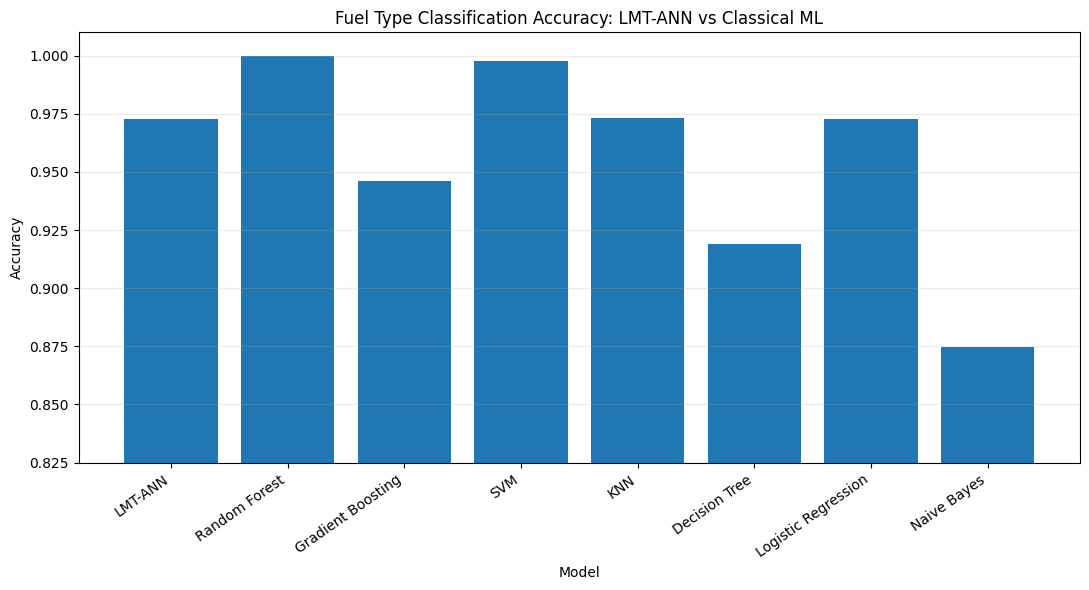

[OK] fuel_type_accuracy_comparison.png


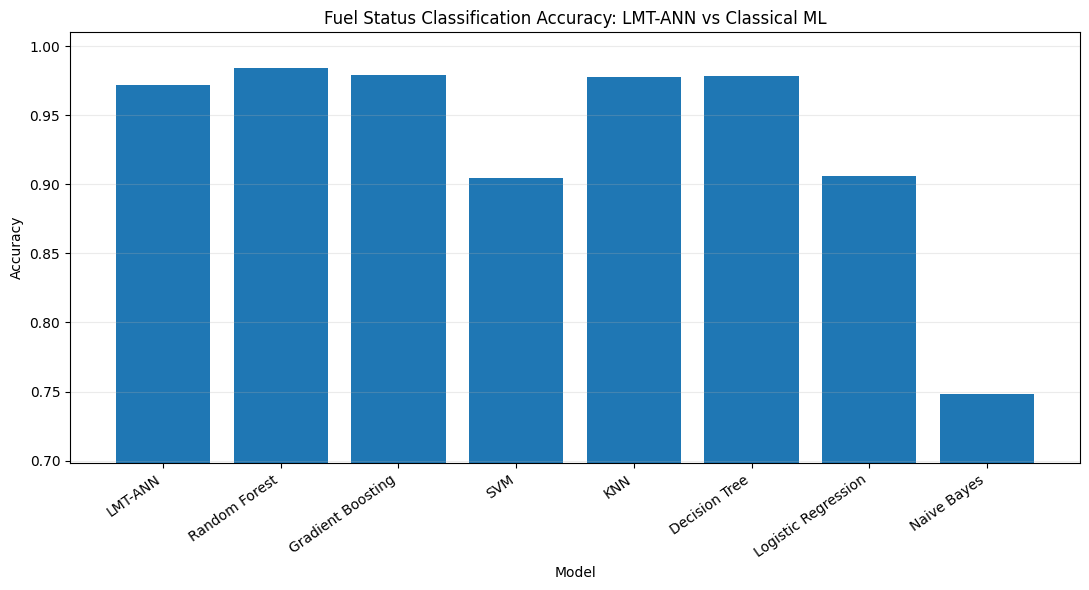

[OK] fuel_status_accuracy_comparison.png


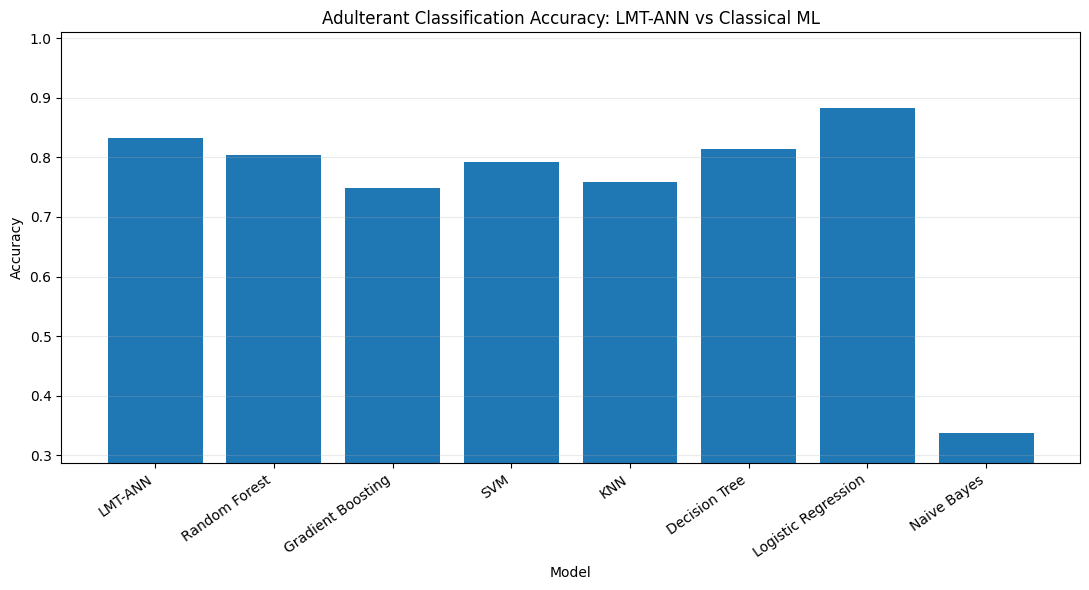

[OK] adulterant_accuracy_comparison.png


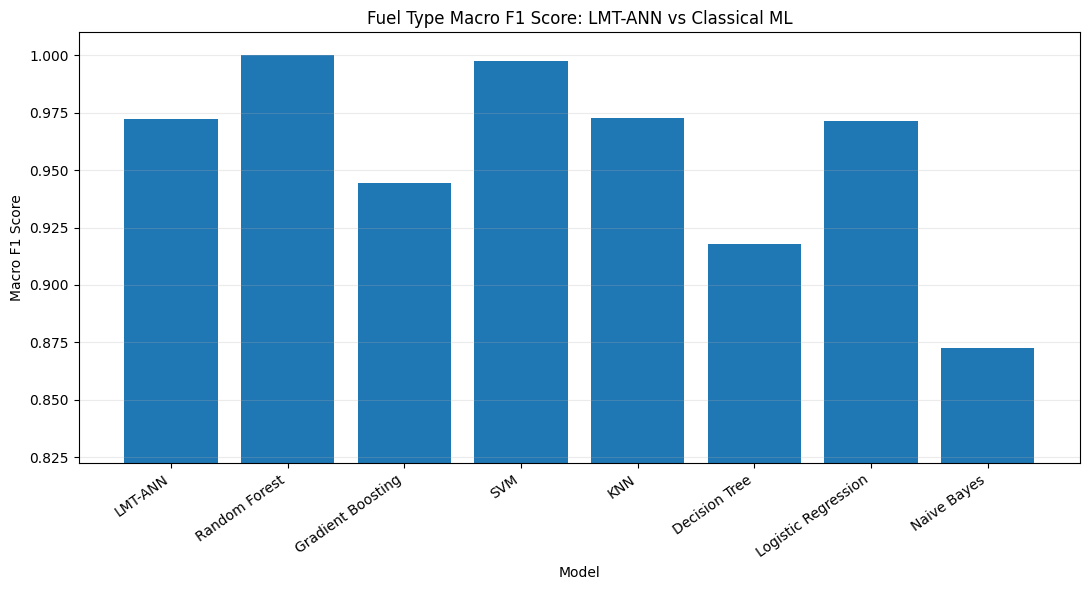

[OK] fuel_type_f1_comparison.png


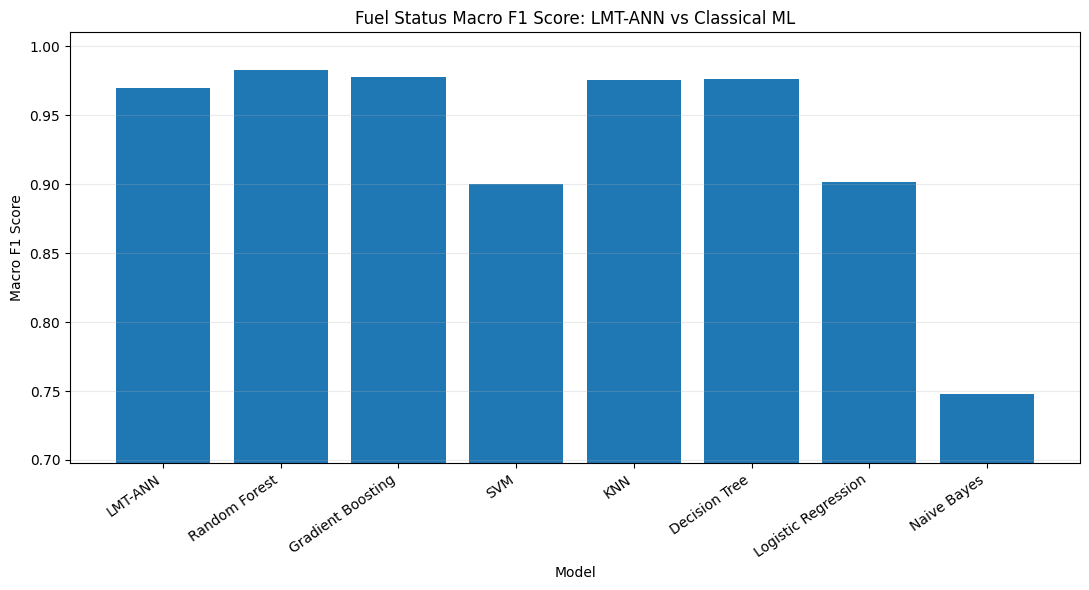

[OK] fuel_status_f1_comparison.png


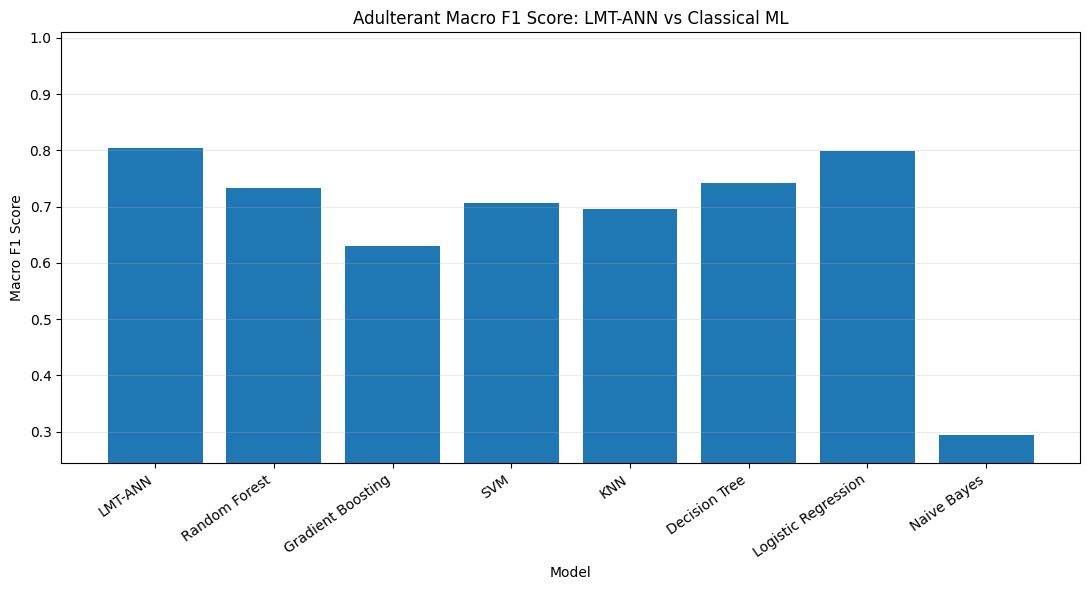

[OK] adulterant_f1_comparison.png


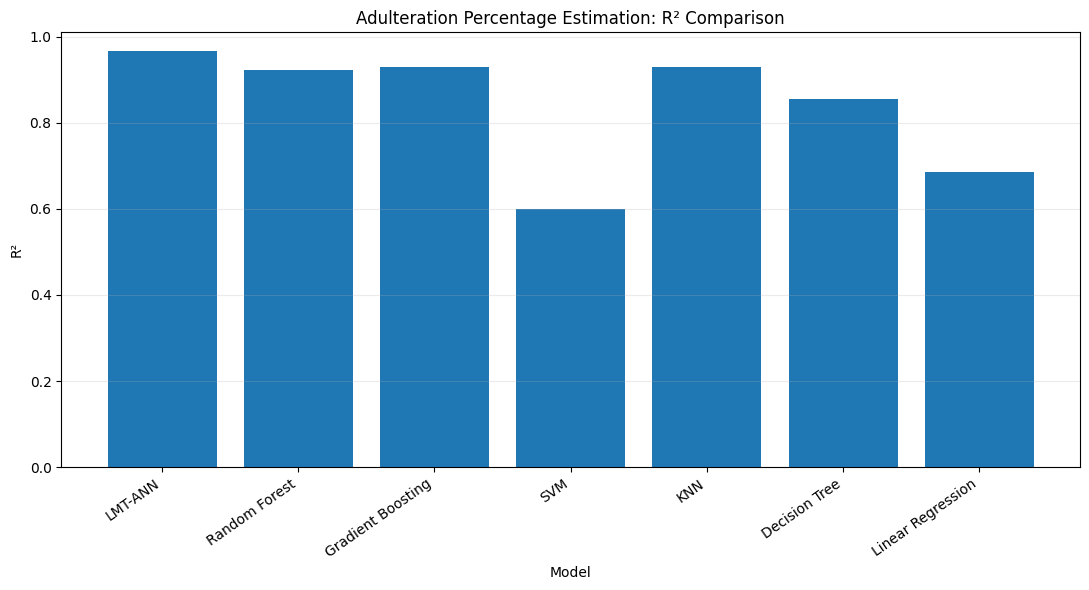

[OK] adulteration_percentage_r2_comparison.png


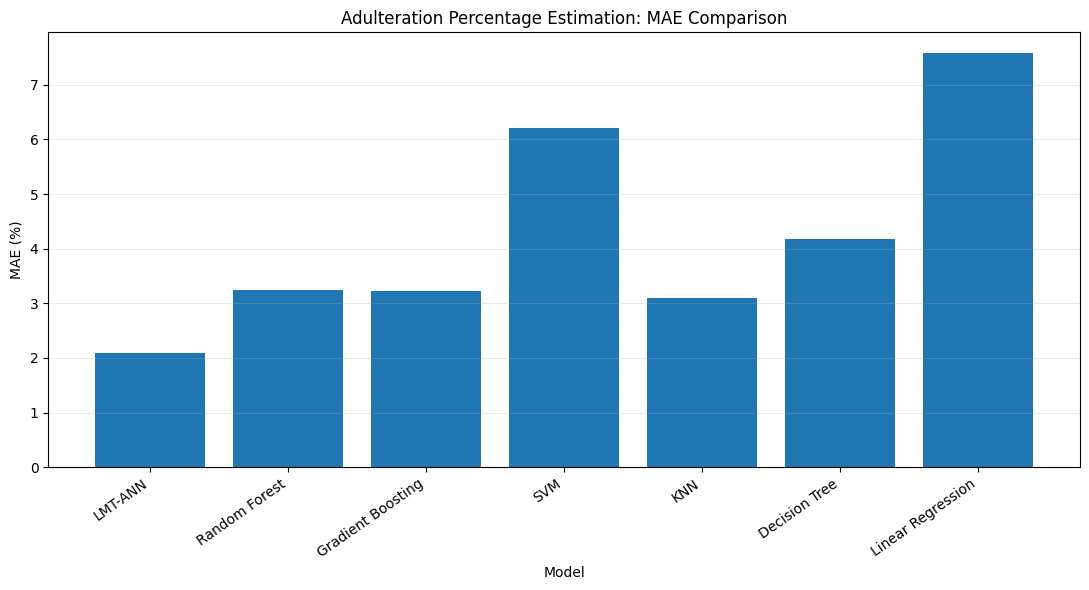

[OK] adulteration_percentage_mae_comparison.png


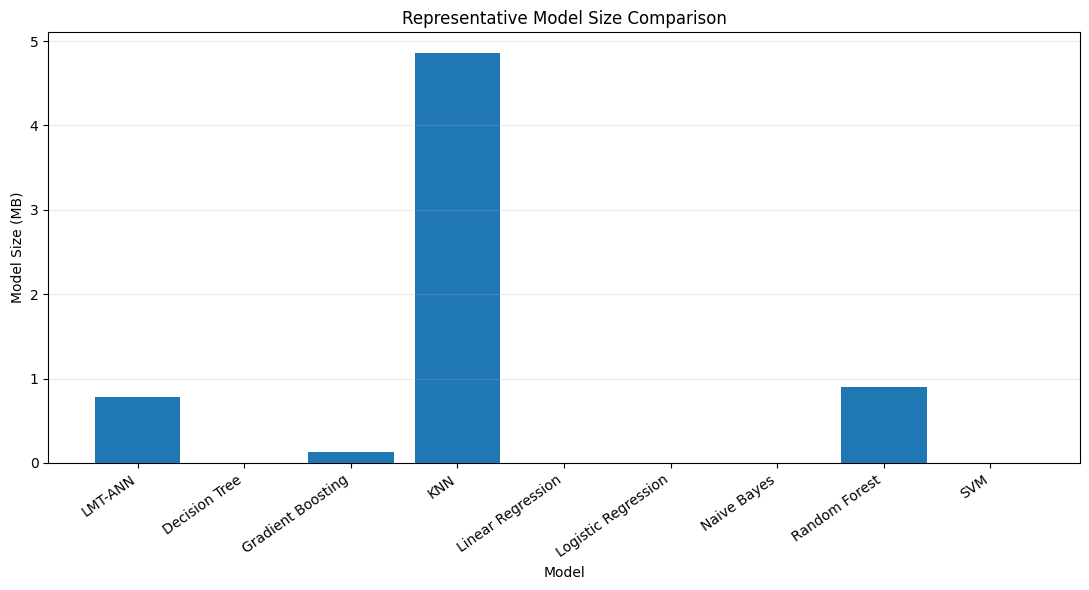

[OK] model_size_comparison.png

FINAL CLASSIFICATION COMPARISONS

----------------------------------------------------------------------------------------------------
Fuel Type
----------------------------------------------------------------------------------------------------


,Task,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_s,Inference_Latency_ms_per_sample,Model_Size_MB,Model_Type
0,Fuel Type,LMT-ANN,0.9728,0.9765,0.9705,0.9724,0.9972,NaN,24.3876,0.7818,Unified Multi-Task
1,Fuel Type,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,47.8515,0.0077,0.8982,Task-Specific
2,Fuel Type,Gradient Boosting,0.9460,0.9566,0.9413,0.9446,1.0000,225.0244,0.0040,0.3736,Task-Specific
3,Fuel Type,SVM,0.9976,0.9976,0.9974,0.9975,NaN,1.3146,0.0002,0.0007,Task-Specific
4,Fuel Type,KNN,0.9730,0.9768,0.9706,0.9726,0.9783,0.1495,0.0190,5.0507,Task-Specific
5,Fuel Type,Decision Tree,0.9190,0.9213,0.9163,0.9178,0.9376,1.0372,0.0001,0.0041,Task-Specific
6,Fuel Type,Logistic Regression,0.9729,0.9750,0.9706,0.9716,0.9998,0.9556,0.0004,0.0008,Task-Specific
7,Fuel Type,Naive Bayes,0.8749,0.8774,0.8710,0.8725,0.9539,0.0222,0.0001,0.0009,Task-Specific



----------------------------------------------------------------------------------------------------
Fuel Status
----------------------------------------------------------------------------------------------------


,Task,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_s,Inference_Latency_ms_per_sample,Model_Size_MB,Model_Type
0,Fuel Status,LMT-ANN,0.9719,0.9630,0.9783,0.9697,0.9969,NaN,24.3876,0.7818,Unified Multi-Task
1,Fuel Status,Random Forest,0.9843,0.9789,0.9876,0.9830,0.9999,46.2076,0.0053,11.4716,Task-Specific
2,Fuel Status,Gradient Boosting,0.9790,0.9722,0.9833,0.9773,0.9940,70.3724,0.0014,0.1326,Task-Specific
3,Fuel Status,SVM,0.9044,0.8928,0.9250,0.9003,0.9230,0.6601,0.0001,0.0006,Task-Specific
4,Fuel Status,KNN,0.9776,0.9702,0.9825,0.9757,0.9865,0.0471,0.0123,5.0507,Task-Specific
5,Fuel Status,Decision Tree,0.9781,0.9716,0.9817,0.9763,0.9817,1.8011,0.0001,0.0551,Task-Specific
6,Fuel Status,Logistic Regression,0.9061,0.8932,0.9229,0.9015,0.9236,0.4443,0.0001,0.0007,Task-Specific
7,Fuel Status,Naive Bayes,0.7483,0.7916,0.8058,0.7478,0.7832,0.0458,0.0001,0.0008,Task-Specific



----------------------------------------------------------------------------------------------------
Adulterant
----------------------------------------------------------------------------------------------------


...


EFFICIENCY COMPARISON


,Task,Model,Path,Training_Samples,Model_Size_MB,Training_Time_s,Inference_Latency_ms_per_sample,Throughput_samples_per_s,Complexity_Indicator,Model_Type,Parameters,Trainable_Parameters,Nontrainable_Parameters,Dense_MACs,Approx_FLOPs
0,Unified Model,LMT-ANN,,151256,0.7818,NaN,24.3876,4.100440e+01,55680.0,Unified Multi-Task,57868.0,57100.0,768.0,55680.0,111360.0
1,Fuel Type,Random Forest,/content/physics_guided_petroleum_dataset/07_S...,151256,0.8982,47.8515,0.0077,1.298420e+05,10176.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
2,Fuel Type,Gradient Boosting,/content/physics_guided_petroleum_dataset/07_S...,151256,0.3736,225.0244,0.0040,2.516414e+05,4472.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
3,Fuel Type,SVM,/content/physics_guided_petroleum_dataset/07_S...,151256,0.0007,1.3146,0.0002,4.662129e+06,21.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
4,Fuel Type,KNN,/content/physics_guided_petroleum_dataset/07_S...,50000,5.0507,0.1495,0.0190,5.257804e+04,NaN,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
5,Fuel Type,Decision Tree,/content/physics_guided_petroleum_dataset/07_S...,151256,0.0041,1.0372,0.0001,1.525084e+07,35.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
6,Fuel Type,Logistic Regression,/content/physics_guided_petroleum_dataset/07_S...,151256,0.0008,0.9556,0.0004,2.224559e+06,21.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
7,Fuel Type,Naive Bayes,/content/physics_guided_petroleum_dataset/07_S...,151256,0.0009,0.0222,0.0001,1.036527e+07,21.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
8,Fuel Status,Random Forest,/content/physics_guided_petroleum_dataset/07_S...,151256,11.4716,46.2076,0.0053,1.878653e+05,149760.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN
9,Fuel Status,Gradient Boosting,/content/physics_guided_petroleum_dataset/07_S...,151256,0.1326,70.3724,0.0014,6.930171e+05,1600.0,Task-Specific Classical ML,NaN,NaN,NaN,NaN,NaN



MULTI-TASK CAPABILITY


,Approach,Unified_Model,Fuel_Type,Fuel_Status,Adulterant,Adulteration_Percentage,Number_of_Task_Specific_Models,Multi_Task_Capability
0,LMT-ANN,Yes,Yes,Yes,Yes,Yes,1,Native
1,Random Forest,No,Yes,Yes,Yes,Yes*,4,Task-specific
2,Gradient Boosting,No,Yes,Yes,Yes,Yes*,4,Task-specific
3,SVM,No,Yes,Yes,Yes,Yes*,4,Task-specific
4,KNN,No,Yes,Yes,Yes,Yes*,4,Task-specific
5,Decision Tree,No,Yes,Yes,Yes,Yes*,4,Task-specific
6,Logistic Regression,No,Yes,Yes,Yes,No,3,Task-specific
7,Naive Bayes,No,Yes,Yes,Yes,No,3,Task-specific



SECTION 5 — CELL 3 COMPLETED SUCCESSFULLY

[OK] Official LMT-ANN results included
[OK] Classical ML results included
[OK] Classification comparison completed
[OK] Regression comparison completed
[OK] Performance differences calculated
[OK] Efficiency comparison completed
[OK] Multi-task capability comparison completed
[OK] Model-size comparison completed
[OK] Thesis-ready figures generated
[OK] Comparison CSV files saved
[OK] Final comparison JSON saved

Figures:
/content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/Figures

Reports:
/content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/Reports

No model was retrained.
No new dataset was created.
The official LMT-ANN results were preserved.

NEXT:
Section 5 — Cell 4:
FINAL PACKAGE ASSEMBLY + README + ZIP



In [ ]:
# ================================================================================================
# SECTION 5 — CELL 3
# LMT-ANN vs CLASSICAL ML — FINAL COMPARISON
# ================================================================================================
#
# PURPOSE:
#   Compare the official LMT-ANN against the seven classical ML approaches
#   using the results already produced in Section 5 Cell 2.
#
# IMPORTANT:
#   - No model retraining
#   - No new dataset
#   - No change to the official LMT-ANN results
#   - Test results from Cell 2 are reused exactly as saved
#   - LMT-ANN values are the official locked Section 3/4 results
#
# ================================================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("=" * 100)
print("SECTION 5 — CELL 3: LMT-ANN VS CLASSICAL ML FINAL COMPARISON")
print("=" * 100)

# ================================================================================================
# 1. DIRECTORIES
# ================================================================================================

ROOT = Path("/content/physics_guided_petroleum_dataset")

SECTION5_DIR = (
    ROOT /
    "07_Section_4_Computational_Analysis" /
    "Section_5_Classical_ML_Comparison"
)

REPORT_DIR = SECTION5_DIR / "Reports"
FIGURE_DIR = SECTION5_DIR / "Figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("\n[1] DIRECTORY CHECK")
print("-" * 100)

print(f"[OK] Section 5 directory : {SECTION5_DIR}")
print(f"[OK] Reports directory   : {REPORT_DIR}")
print(f"[OK] Figures directory   : {FIGURE_DIR}")

# ================================================================================================
# 2. LOAD CELL 2 RESULTS
# ================================================================================================

print("\n[2] LOADING CLASSICAL ML RESULTS")
print("-" * 100)

classification_file = (
    REPORT_DIR /
    "classical_ml_classification_results.csv"
)

regression_file = (
    REPORT_DIR /
    "classical_ml_regression_results.csv"
)

efficiency_file = (
    REPORT_DIR /
    "classical_ml_efficiency_results.csv"
)

assert classification_file.exists(), "Classification results file not found."
assert regression_file.exists(), "Regression results file not found."
assert efficiency_file.exists(), "Efficiency results file not found."

classification_df = pd.read_csv(classification_file)
regression_df = pd.read_csv(regression_file)
efficiency_df = pd.read_csv(efficiency_file)

print(f"[OK] Classification results loaded: {len(classification_df)} rows")
print(f"[OK] Regression results loaded     : {len(regression_df)} rows")
print(f"[OK] Efficiency results loaded     : {len(efficiency_df)} rows")

# ================================================================================================
# 3. OFFICIAL LOCKED LMT-ANN RESULTS
# ================================================================================================
#
# These are the official values already accepted for Section 3/4.
# They are NOT recalculated here.
#
# ================================================================================================

print("\n[3] LOADING OFFICIAL LMT-ANN REFERENCE RESULTS")
print("-" * 100)

LMT_ANN_RESULTS = {

    "Fuel Type": {
        "Accuracy": 0.972819,
        "Precision": 0.976535,
        "Recall": 0.970454,
        "F1": 0.972413,
        "ROC_AUC": 0.997224
    },

    "Fuel Status": {
        "Accuracy": 0.971862,
        "Precision": 0.963009,
        "Recall": 0.978266,
        "F1": 0.969689,
        "ROC_AUC": 0.996855
    },

    "Adulterant": {
        "Accuracy": 0.832531,
        "Precision": 0.851570,
        "Recall": 0.791226,
        "F1": 0.805077,
        "ROC_AUC": 0.975493
    },

    "Adulteration Percentage": {
        "MAE": 2.092393,
        "RMSE": 3.278608,
        "R2": 0.967477
    }
}

# Official computational-efficiency values
LMT_ANN_EFFICIENCY = {
    "Model": "LMT-ANN",

    "Parameters": 57868,
    "Trainable_Parameters": 57100,
    "Nontrainable_Parameters": 768,

    "Dense_Parameters": 56332,
    "Dense_MACs": 55680,
    "Approx_FLOPs": 111360,

    "Model_Size_MB": 0.781849,
    "Model_Size_MiB": 0.745629,

    "CPU_Batch1_Latency_ms": 24.387624,
    "CPU_Batch1_Median_ms": 21.839044,
    "CPU_Batch1_P95_ms": 45.897463,

    "Throughput_samples_per_s": 41.004404,

    "Multi_Task": True,
    "Number_of_Tasks": 4
}

print("[OK] Official LMT-ANN classification metrics loaded")
print("[OK] Official LMT-ANN regression metrics loaded")
print("[OK] Official LMT-ANN efficiency metrics loaded")

# ================================================================================================
# 4. CLASSIFICATION COMPARISON TABLES
# ================================================================================================

print("\n[4] BUILDING CLASSIFICATION COMPARISON TABLES")
print("-" * 100)

classification_comparisons = {}

for task in ["Fuel Type", "Fuel Status", "Adulterant"]:

    classical_task = classification_df[
        classification_df["Task"] == task
    ].copy()

    lmt = LMT_ANN_RESULTS[task]

    lmt_row = pd.DataFrame([{
        "Task": task,
        "Model": "LMT-ANN",
        "Accuracy": lmt["Accuracy"],
        "Precision": lmt["Precision"],
        "Recall": lmt["Recall"],
        "F1": lmt["F1"],
        "ROC_AUC": lmt["ROC_AUC"],
        "Training_Time_s": np.nan,
        "Inference_Latency_ms_per_sample":
            LMT_ANN_EFFICIENCY["CPU_Batch1_Latency_ms"],
        "Model_Size_MB":
            LMT_ANN_EFFICIENCY["Model_Size_MB"],
        "Model_Type": "Unified Multi-Task"
    }])

    classical_task["Model_Type"] = "Task-Specific"

    combined = pd.concat(
        [
            lmt_row,
            classical_task[
                [
                    "Task",
                    "Model",
                    "Accuracy",
                    "Precision",
                    "Recall",
                    "F1",
                    "ROC_AUC",
                    "Training_Time_s",
                    "Inference_Latency_ms_per_sample",
                    "Model_Size_MB",
                    "Model_Type"
                ]
            ]
        ],
        ignore_index=True
    )

    classification_comparisons[task] = combined

    output_name = (
        task.lower()
        .replace(" ", "_")
    )

    combined.to_csv(
        REPORT_DIR /
        f"{output_name}_LMT_ANN_vs_classical_comparison.csv",
        index=False
    )

    print(f"[OK] {task} comparison created")

# ================================================================================================
# 5. REGRESSION COMPARISON
# ================================================================================================

print("\n[5] BUILDING REGRESSION COMPARISON")
print("-" * 100)

regression_lmt_row = pd.DataFrame([{
    "Task": "Adulteration Percentage",
    "Model": "LMT-ANN",
    "MAE": LMT_ANN_RESULTS["Adulteration Percentage"]["MAE"],
    "RMSE": LMT_ANN_RESULTS["Adulteration Percentage"]["RMSE"],
    "R2": LMT_ANN_RESULTS["Adulteration Percentage"]["R2"],
    "Training_Time_s": np.nan,
    "Inference_Latency_ms_per_sample":
        LMT_ANN_EFFICIENCY["CPU_Batch1_Latency_ms"],
    "Model_Size_MB":
        LMT_ANN_EFFICIENCY["Model_Size_MB"],
    "Model_Type": "Unified Multi-Task"
}])

regression_classical = regression_df.copy()
regression_classical["Model_Type"] = "Task-Specific"

regression_comparison = pd.concat(
    [
        regression_lmt_row,
        regression_classical[
            [
                "Task",
                "Model",
                "MAE",
                "RMSE",
                "R2",
                "Training_Time_s",
                "Inference_Latency_ms_per_sample",
                "Model_Size_MB",
                "Model_Type"
            ]
        ]
    ],
    ignore_index=True
)

regression_comparison.to_csv(
    REPORT_DIR /
    "adulteration_percentage_LMT_ANN_vs_classical_comparison.csv",
    index=False
)

print("[OK] Adulteration percentage comparison created")

# ================================================================================================
# 6. DETERMINE BEST CLASSICAL MODEL FOR EACH TASK
# ================================================================================================

print("\n[6] IDENTIFYING BEST CLASSICAL MODELS")
print("-" * 100)

best_models = []

for task in ["Fuel Type", "Fuel Status", "Adulterant"]:

    task_df = classification_df[
        classification_df["Task"] == task
    ].copy()

    best_row = task_df.loc[
        task_df["F1"].idxmax()
    ]

    best_models.append({
        "Task": task,
        "Best_Classical_Model": best_row["Model"],
        "Best_Classical_Accuracy": best_row["Accuracy"],
        "Best_Classical_F1": best_row["F1"],
        "Best_Classical_ROC_AUC": best_row["ROC_AUC"]
    })

best_regression = regression_df.loc[
    regression_df["R2"].idxmax()
]

best_models.append({
    "Task": "Adulteration Percentage",
    "Best_Classical_Model": best_regression["Model"],
    "Best_Classical_Accuracy": np.nan,
    "Best_Classical_F1": np.nan,
    "Best_Classical_ROC_AUC": np.nan,
    "Best_Classical_MAE": best_regression["MAE"],
    "Best_Classical_RMSE": best_regression["RMSE"],
    "Best_Classical_R2": best_regression["R2"]
})

best_models_df = pd.DataFrame(best_models)

best_models_df.to_csv(
    REPORT_DIR /
    "best_classical_models_by_task.csv",
    index=False
)

print(best_models_df.to_string(index=False))

# ================================================================================================
# 7. LMT-ANN ADVANTAGE CALCULATIONS
# ================================================================================================

print("\n[7] CALCULATING PERFORMANCE DIFFERENCES")
print("-" * 100)

advantage_rows = []

for task in ["Fuel Type", "Fuel Status", "Adulterant"]:

    task_df = classification_df[
        classification_df["Task"] == task
    ].copy()

    lmt_acc = LMT_ANN_RESULTS[task]["Accuracy"]
    lmt_f1 = LMT_ANN_RESULTS[task]["F1"]

    best_acc_row = task_df.loc[
        task_df["Accuracy"].idxmax()
    ]

    best_f1_row = task_df.loc[
        task_df["F1"].idxmax()
    ]

    advantage_rows.append({
        "Task": task,
        "LMT_ANN_Accuracy": lmt_acc,
        "Best_Classical_Accuracy":
            best_acc_row["Accuracy"],
        "Accuracy_Difference_LMT_minus_BestClassical":
            lmt_acc - best_acc_row["Accuracy"],
        "Best_Classical_Accuracy_Model":
            best_acc_row["Model"],

        "LMT_ANN_F1": lmt_f1,
        "Best_Classical_F1":
            best_f1_row["F1"],
        "F1_Difference_LMT_minus_BestClassical":
            lmt_f1 - best_f1_row["F1"],
        "Best_Classical_F1_Model":
            best_f1_row["Model"]
    })

# Regression
best_reg = regression_df.loc[
    regression_df["R2"].idxmax()
]

advantage_rows.append({
    "Task": "Adulteration Percentage",

    "LMT_ANN_MAE":
        LMT_ANN_RESULTS["Adulteration Percentage"]["MAE"],

    "Best_Classical_MAE":
        best_reg["MAE"],

    "MAE_Improvement_LMT_ANN":
        best_reg["MAE"] -
        LMT_ANN_RESULTS["Adulteration Percentage"]["MAE"],

    "LMT_ANN_RMSE":
        LMT_ANN_RESULTS["Adulteration Percentage"]["RMSE"],

    "Best_Classical_RMSE":
        best_reg["RMSE"],

    "RMSE_Improvement_LMT_ANN":
        best_reg["RMSE"] -
        LMT_ANN_RESULTS["Adulteration Percentage"]["RMSE"],

    "LMT_ANN_R2":
        LMT_ANN_RESULTS["Adulteration Percentage"]["R2"],

    "Best_Classical_R2":
        best_reg["R2"],

    "R2_Improvement_LMT_ANN":
        LMT_ANN_RESULTS["Adulteration Percentage"]["R2"] -
        best_reg["R2"],

    "Best_Classical_Model":
        best_reg["Model"]
})

advantage_df = pd.DataFrame(advantage_rows)

advantage_df.to_csv(
    REPORT_DIR /
    "LMT_ANN_performance_advantage.csv",
    index=False
)

print("[OK] Performance differences calculated")

# ================================================================================================
# 8. EFFICIENCY COMPARISON
# ================================================================================================

print("\n[8] BUILDING EFFICIENCY COMPARISON")
print("-" * 100)

efficiency_comparison = efficiency_df.copy()

efficiency_comparison["Model_Type"] = "Task-Specific Classical ML"

# Add LMT-ANN reference
lmt_efficiency_row = pd.DataFrame([{
    "Task": "Unified Model",
    "Model": "LMT-ANN",

    "Path": "",
    "Training_Samples": 151256,

    "Model_Size_MB":
        LMT_ANN_EFFICIENCY["Model_Size_MB"],

    "Training_Time_s": np.nan,

    "Inference_Latency_ms_per_sample":
        LMT_ANN_EFFICIENCY["CPU_Batch1_Latency_ms"],

    "Throughput_samples_per_s":
        LMT_ANN_EFFICIENCY["Throughput_samples_per_s"],

    "Complexity_Indicator":
        LMT_ANN_EFFICIENCY["Dense_MACs"],

    "Model_Type": "Unified Multi-Task",

    "Parameters":
        LMT_ANN_EFFICIENCY["Parameters"],

    "Trainable_Parameters":
        LMT_ANN_EFFICIENCY["Trainable_Parameters"],

    "Nontrainable_Parameters":
        LMT_ANN_EFFICIENCY["Nontrainable_Parameters"],

    "Dense_MACs":
        LMT_ANN_EFFICIENCY["Dense_MACs"],

    "Approx_FLOPs":
        LMT_ANN_EFFICIENCY["Approx_FLOPs"]
}])

efficiency_comparison = pd.concat(
    [
        lmt_efficiency_row,
        efficiency_comparison
    ],
    ignore_index=True
)

efficiency_comparison.to_csv(
    REPORT_DIR /
    "LMT_ANN_vs_classical_efficiency_comparison.csv",
    index=False
)

print("[OK] Efficiency comparison saved")

# ================================================================================================
# 9. MULTI-TASK CAPABILITY TABLE
# ================================================================================================

print("\n[9] BUILDING MULTI-TASK CAPABILITY COMPARISON")
print("-" * 100)

multi_task_rows = [

    {
        "Approach": "LMT-ANN",
        "Unified_Model": "Yes",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "Yes",
        "Number_of_Task_Specific_Models": 1,
        "Multi_Task_Capability": "Native"
    },

    {
        "Approach": "Random Forest",
        "Unified_Model": "No",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "Yes*",
        "Number_of_Task_Specific_Models": 4,
        "Multi_Task_Capability": "Task-specific"
    },

    {
        "Approach": "Gradient Boosting",
        "Unified_Model": "No",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "Yes*",
        "Number_of_Task_Specific_Models": 4,
        "Multi_Task_Capability": "Task-specific"
    },

    {
        "Approach": "SVM",
        "Unified_Model": "No",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "Yes*",
        "Number_of_Task_Specific_Models": 4,
        "Multi_Task_Capability": "Task-specific"
    },

    {
        "Approach": "KNN",
        "Unified_Model": "No",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "Yes*",
        "Number_of_Task_Specific_Models": 4,
        "Multi_Task_Capability": "Task-specific"
    },

    {
        "Approach": "Decision Tree",
        "Unified_Model": "No",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "Yes*",
        "Number_of_Task_Specific_Models": 4,
        "Multi_Task_Capability": "Task-specific"
    },

    {
        "Approach": "Logistic Regression",
        "Unified_Model": "No",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "No",
        "Number_of_Task_Specific_Models": 3,
        "Multi_Task_Capability": "Task-specific"
    },

    {
        "Approach": "Naive Bayes",
        "Unified_Model": "No",
        "Fuel_Type": "Yes",
        "Fuel_Status": "Yes",
        "Adulterant": "Yes",
        "Adulteration_Percentage": "No",
        "Number_of_Task_Specific_Models": 3,
        "Multi_Task_Capability": "Task-specific"
    }
]

multi_task_df = pd.DataFrame(multi_task_rows)

multi_task_df.to_csv(
    REPORT_DIR /
    "multi_task_capability_comparison.csv",
    index=False
)

print("[OK] Multi-task capability table saved")

# ================================================================================================
# 10. FIGURE 1 — CLASSIFICATION ACCURACY
# ================================================================================================

print("\n[10] GENERATING FIGURES")
print("-" * 100)

for task in ["Fuel Type", "Fuel Status", "Adulterant"]:

    comparison = classification_comparisons[task].copy()

    plt.figure(figsize=(11, 6))

    plt.bar(
        comparison["Model"],
        comparison["Accuracy"]
    )

    plt.ylabel("Accuracy")
    plt.xlabel("Model")
    plt.title(
        f"{task} Classification Accuracy: LMT-ANN vs Classical ML"
    )

    plt.ylim(
        max(0, comparison["Accuracy"].min() - 0.05),
        1.01
    )

    plt.xticks(
        rotation=35,
        ha="right"
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    filename = (
        task.lower()
        .replace(" ", "_")
        + "_accuracy_comparison.png"
    )

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"[OK] {filename}")

# ================================================================================================
# 11. FIGURE 2 — F1 SCORE
# ================================================================================================

for task in ["Fuel Type", "Fuel Status", "Adulterant"]:

    comparison = classification_comparisons[task].copy()

    plt.figure(figsize=(11, 6))

    plt.bar(
        comparison["Model"],
        comparison["F1"]
    )

    plt.ylabel("Macro F1 Score")
    plt.xlabel("Model")
    plt.title(
        f"{task} Macro F1 Score: LMT-ANN vs Classical ML"
    )

    plt.ylim(
        max(0, comparison["F1"].min() - 0.05),
        1.01
    )

    plt.xticks(
        rotation=35,
        ha="right"
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    filename = (
        task.lower()
        .replace(" ", "_")
        + "_f1_comparison.png"
    )

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"[OK] {filename}")

# ================================================================================================
# 12. FIGURE 3 — REGRESSION R²
# ================================================================================================

plt.figure(figsize=(11, 6))

plt.bar(
    regression_comparison["Model"],
    regression_comparison["R2"]
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title(
    "Adulteration Percentage Estimation: R² Comparison"
)

plt.ylim(
    min(0, regression_comparison["R2"].min() - 0.05),
    1.01
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "adulteration_percentage_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("[OK] adulteration_percentage_r2_comparison.png")

# ================================================================================================
# 13. FIGURE 4 — REGRESSION ERROR
# ================================================================================================

plt.figure(figsize=(11, 6))

plt.bar(
    regression_comparison["Model"],
    regression_comparison["MAE"]
)

plt.ylabel("MAE (%)")
plt.xlabel("Model")
plt.title(
    "Adulteration Percentage Estimation: MAE Comparison"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "adulteration_percentage_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("[OK] adulteration_percentage_mae_comparison.png")

# ================================================================================================
# 14. FIGURE 5 — MODEL SIZE
# ================================================================================================

# To avoid mixing task-specific duplicate models with the unified LMT-ANN,
# show the smallest representative model size per algorithm family.

size_summary = (
    efficiency_df
    .groupby("Model")["Model_Size_MB"]
    .min()
    .reset_index()
)

size_summary = pd.concat(
    [
        pd.DataFrame([
            {
                "Model": "LMT-ANN",
                "Model_Size_MB":
                    LMT_ANN_EFFICIENCY["Model_Size_MB"]
            }
        ]),
        size_summary
    ],
    ignore_index=True
)

plt.figure(figsize=(11, 6))

plt.bar(
    size_summary["Model"],
    size_summary["Model_Size_MB"]
)

plt.ylabel("Model Size (MB)")
plt.xlabel("Model")
plt.title(
    "Representative Model Size Comparison"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "model_size_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("[OK] model_size_comparison.png")

# ================================================================================================
# 15. FIGURE 6 — LMT-ANN PARAMETER / COMPLEXITY SUMMARY
# ================================================================================================

complexity_summary = pd.DataFrame([
    {
        "Metric": "Total Parameters",
        "Value": LMT_ANN_EFFICIENCY["Parameters"]
    },
    {
        "Metric": "Trainable Parameters",
        "Value": LMT_ANN_EFFICIENCY["Trainable_Parameters"]
    },
    {
        "Metric": "Dense MACs",
        "Value": LMT_ANN_EFFICIENCY["Dense_MACs"]
    },
    {
        "Metric": "Approx. FLOPs",
        "Value": LMT_ANN_EFFICIENCY["Approx_FLOPs"]
    }
])

complexity_summary.to_csv(
    REPORT_DIR /
    "LMT_ANN_complexity_summary.csv",
    index=False
)

# ================================================================================================
# 16. PRINT FINAL COMPARISON TABLES
# ================================================================================================

print("\n" + "=" * 100)
print("FINAL CLASSIFICATION COMPARISONS")
print("=" * 100)

for task in ["Fuel Type", "Fuel Status", "Adulterant"]:

    print("\n" + "-" * 100)
    print(task)
    print("-" * 100)

    display(
        classification_comparisons[task].round(4)
    )

print("\n" + "=" * 100)
print("FINAL REGRESSION COMPARISON")
print("=" * 100)

display(
    regression_comparison.round(4)
)

print("\n" + "=" * 100)
print("EFFICIENCY COMPARISON")
print("=" * 100)

display(
    efficiency_comparison.round(4)
)

print("\n" + "=" * 100)
print("MULTI-TASK CAPABILITY")
print("=" * 100)

display(
    multi_task_df
)

# ================================================================================================
# 17. FINAL SECTION 5 SUMMARY JSON
# ================================================================================================

summary = {

    "section": "Section 5 — Classical ML Comparison",

    "dataset": {
        "total_observations": 216080,
        "training_observations": 151256,
        "validation_observations": 32412,
        "test_observations": 32412
    },

    "input_features": [
        "Density_g_mL",
        "Viscosity_cP",
        "Refractive_Index",
        "Dielectric_Constant",
        "Optical_Sensor",
        "Colour_Value",
        "Temperature"
    ],

    "lmt_ann": LMT_ANN_RESULTS,

    "lmt_ann_efficiency": LMT_ANN_EFFICIENCY,

    "classical_models": [
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "KNN",
        "Decision Tree",
        "Logistic Regression",
        "Naive Bayes"
    ],

    "knn_reference_samples": 50000,

    "raspberry_pi_hardware_tested": False,

    "new_dataset_created": False,

    "lmt_ann_retrained": False
}

with open(
    REPORT_DIR /
    "Section_5_Final_Comparison_Summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

# ================================================================================================
# FINAL STATUS
# ================================================================================================

print("\n" + "=" * 100)
print("SECTION 5 — CELL 3 COMPLETED SUCCESSFULLY")
print("=" * 100)

print(f"""
[OK] Official LMT-ANN results included
[OK] Classical ML results included
[OK] Classification comparison completed
[OK] Regression comparison completed
[OK] Performance differences calculated
[OK] Efficiency comparison completed
[OK] Multi-task capability comparison completed
[OK] Model-size comparison completed
[OK] Thesis-ready figures generated
[OK] Comparison CSV files saved
[OK] Final comparison JSON saved

Figures:
{FIGURE_DIR}

Reports:
{REPORT_DIR}

No model was retrained.
No new dataset was created.
The official LMT-ANN results were preserved.

NEXT:
Section 5 — Cell 4:
FINAL PACKAGE ASSEMBLY + README + ZIP
""")

print("=" * 100)

In [ ]:
# ==================================================================================================
# SECTION 5 — CELL 4: FINAL PACKAGE ASSEMBLY + README + ZIP
# ==================================================================================================

import os
import json
import shutil
import zipfile
from pathlib import Path
from datetime import datetime

print("=" * 100)
print("SECTION 5 — FINAL PACKAGE ASSEMBLY + README + ZIP")
print("=" * 100)

# --------------------------------------------------------------------------------------------------
# 1. ROOT DIRECTORIES
# --------------------------------------------------------------------------------------------------

ROOT = Path("/content/physics_guided_petroleum_dataset")

PREPROCESSING = ROOT / "05_Preprocessing"
MODEL_DIR = ROOT / "06_LMT_ANN_Model"
SECTION4 = ROOT / "07_Section_4_Computational_Analysis"

SECTION5 = SECTION4 / "Section_5_Classical_ML_Comparison"
CLASSICAL_MODELS = SECTION5 / "Classical_Models"
REPORTS = SECTION5 / "Reports"
FIGURES = SECTION5 / "Figures"

DEPLOYMENT = SECTION4 / "Deployment_Package"
TFLITE_DIR = SECTION4 / "TFLite_Models"

FINAL_DIR = SECTION5 / "FINAL_PACKAGE"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = SECTION5 / "FINAL_Petroleum_Adulteration_LMT_ANN_Classical_ML_Package.zip"

# --------------------------------------------------------------------------------------------------
# 2. DIRECTORY CHECK
# --------------------------------------------------------------------------------------------------

print("\n[1] DIRECTORY CHECK")
print("-" * 100)

required_dirs = {
    "Root dataset directory": ROOT,
    "Preprocessing": PREPROCESSING,
    "LMT-ANN model": MODEL_DIR,
    "Section 4": SECTION4,
    "Section 5": SECTION5,
    "Classical models": CLASSICAL_MODELS,
    "Reports": REPORTS,
    "Figures": FIGURES,
}

for name, path in required_dirs.items():
    if path.exists():
        print(f"[OK] {name:<30} {path}")
    else:
        print(f"[WARNING] Missing: {name:<25} {path}")

# --------------------------------------------------------------------------------------------------
# 3. HELPER FUNCTION
# --------------------------------------------------------------------------------------------------

def copy_if_exists(source, destination):
    source = Path(source)
    destination = Path(destination)

    if not source.exists():
        print(f"[WARNING] Not found: {source}")
        return False

    if source.is_dir():
        if destination.exists():
            shutil.rmtree(destination)
        shutil.copytree(source, destination)
    else:
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, destination)

    return True


def copy_tree_contents(source_dir, destination_dir):
    source_dir = Path(source_dir)
    destination_dir = Path(destination_dir)
    destination_dir.mkdir(parents=True, exist_ok=True)

    if not source_dir.exists():
        print(f"[WARNING] Directory not found: {source_dir}")
        return

    for item in source_dir.iterdir():
        target = destination_dir / item.name

        if item.is_dir():
            if target.exists():
                shutil.rmtree(target)
            shutil.copytree(item, target)
        else:
            shutil.copy2(item, target)

# --------------------------------------------------------------------------------------------------
# 4. CLEAN PREVIOUS FINAL PACKAGE
# --------------------------------------------------------------------------------------------------

print("\n[2] PREPARING FINAL PACKAGE DIRECTORY")
print("-" * 100)

if FINAL_DIR.exists():
    for item in FINAL_DIR.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()

print(f"[OK] Final package directory prepared:")
print(FINAL_DIR)

# --------------------------------------------------------------------------------------------------
# 5. CREATE FINAL PACKAGE STRUCTURE
# --------------------------------------------------------------------------------------------------

package_dirs = [
    "01_LMT_ANN_Model",
    "02_Deployment_Package",
    "03_TFLite_Models",
    "04_Preprocessing",
    "05_Classical_ML_Models",
    "06_Reports",
    "07_Figures",
    "08_Training_History",
    "09_Prediction_and_Comparison_Results",
    "10_Documentation",
]

for d in package_dirs:
    (FINAL_DIR / d).mkdir(parents=True, exist_ok=True)

print("[OK] Final package structure created.")

# --------------------------------------------------------------------------------------------------
# 6. LMT-ANN MODEL
# --------------------------------------------------------------------------------------------------

print("\n[3] COLLECTING LMT-ANN MODEL")
print("-" * 100)

model_files = [
    "LMT_ANN_Petroleum_Adulteration.keras",
]

for filename in model_files:
    src = MODEL_DIR / filename
    dst = FINAL_DIR / "01_LMT_ANN_Model" / filename

    if copy_if_exists(src, dst):
        print(f"[OK] {filename}")

# Copy model configuration/history files if available
for filename in [
    "model_config.json",
    "parameter_summary.csv",
    "training_history.csv",
    "training_history.json",
]:
    src = MODEL_DIR / filename
    dst = FINAL_DIR / "08_Training_History" / filename

    if src.exists():
        copy_if_exists(src, dst)
        print(f"[OK] {filename}")

# --------------------------------------------------------------------------------------------------
# 7. DEPLOYMENT PACKAGE
# --------------------------------------------------------------------------------------------------

print("\n[4] COLLECTING DEPLOYMENT PACKAGE")
print("-" * 100)

deployment_files = [
    "LMT_ANN_Model.keras",
    "FeatureScaler.pkl",
    "FuelTypeEncoder.pkl",
    "AdulterantEncoder.pkl",
    "FeatureNames.pkl",
    "deployment_config.json",
    "README.txt",
]

for filename in deployment_files:
    src = DEPLOYMENT / filename
    dst = FINAL_DIR / "02_Deployment_Package" / filename

    if copy_if_exists(src, dst):
        print(f"[OK] {filename}")

# --------------------------------------------------------------------------------------------------
# 8. TFLITE MODELS
# --------------------------------------------------------------------------------------------------

print("\n[5] COLLECTING TFLITE MODELS")
print("-" * 100)

if TFLITE_DIR.exists():

    tflite_count = 0

    for item in TFLITE_DIR.iterdir():

        if item.is_file():
            if item.suffix.lower() in [".tflite", ".json", ".txt"]:
                copy_if_exists(
                    item,
                    FINAL_DIR / "03_TFLite_Models" / item.name
                )
                print(f"[OK] {item.name}")
                tflite_count += 1

    if tflite_count == 0:
        print("[INFO] No TFLite files found in TFLite_Models directory.")

else:
    print("[INFO] TFLite directory not found.")

# --------------------------------------------------------------------------------------------------
# 9. PREPROCESSING ARTIFACTS
# --------------------------------------------------------------------------------------------------

print("\n[6] COLLECTING PREPROCESSING ARTIFACTS")
print("-" * 100)

preprocessing_files = [
    "standard_scaler.pkl",
    "fuel_label_encoder.pkl",
    "adulterant_label_encoder.pkl",
    "preprocessing_config.json",
    "seven_feature_summary.csv",
    "data_split_summary.csv",
    "condition_summary.csv",
]

for filename in preprocessing_files:

    src = PREPROCESSING / filename
    dst = FINAL_DIR / "04_Preprocessing" / filename

    if copy_if_exists(src, dst):
        print(f"[OK] {filename}")

# --------------------------------------------------------------------------------------------------
# 10. CLASSICAL ML MODELS
# --------------------------------------------------------------------------------------------------

print("\n[7] COLLECTING CLASSICAL ML MODELS")
print("-" * 100)

if CLASSICAL_MODELS.exists():

    copied_models = 0

    for item in CLASSICAL_MODELS.iterdir():

        if item.is_file():
            copy_if_exists(
                item,
                FINAL_DIR / "05_Classical_ML_Models" / item.name
            )
            print(f"[OK] {item.name}")
            copied_models += 1

    print(f"[OK] Classical ML model files collected: {copied_models}")

else:
    print("[WARNING] Classical ML model directory not found.")

# --------------------------------------------------------------------------------------------------
# 11. REPORTS
# --------------------------------------------------------------------------------------------------

print("\n[8] COLLECTING REPORTS")
print("-" * 100)

if REPORTS.exists():

    report_count = 0

    for item in REPORTS.iterdir():

        if item.is_file():
            copy_if_exists(
                item,
                FINAL_DIR / "06_Reports" / item.name
            )
            print(f"[OK] {item.name}")
            report_count += 1

    print(f"[OK] Reports collected: {report_count}")

else:
    print("[WARNING] Reports directory not found.")

# --------------------------------------------------------------------------------------------------
# 12. FIGURES
# --------------------------------------------------------------------------------------------------

print("\n[9] COLLECTING FIGURES")
print("-" * 100)

if FIGURES.exists():

    figure_count = 0

    for item in FIGURES.iterdir():

        if item.is_file():
            copy_if_exists(
                item,
                FINAL_DIR / "07_Figures" / item.name
            )
            print(f"[OK] {item.name}")
            figure_count += 1

    print(f"[OK] Figures collected: {figure_count}")

else:
    print("[WARNING] Figures directory not found.")

# --------------------------------------------------------------------------------------------------
# 13. TRAINING HISTORY FROM SECTION 2
# --------------------------------------------------------------------------------------------------

print("\n[10] COLLECTING TRAINING HISTORY")
print("-" * 100)

training_history_candidates = [
    MODEL_DIR / "training_history.csv",
    MODEL_DIR / "training_history.json",
    MODEL_DIR / "LMT_ANN_training_history.csv",
    MODEL_DIR / "LMT_ANN_training_history.json",
]

history_count = 0

for src in training_history_candidates:

    if src.exists():

        copy_if_exists(
            src,
            FINAL_DIR / "08_Training_History" / src.name
        )

        print(f"[OK] {src.name}")
        history_count += 1

if history_count == 0:
    print("[INFO] No standalone training history file found.")
    print("[INFO] Existing model and Section 2 reports remain included.")

# --------------------------------------------------------------------------------------------------
# 14. COMPARISON RESULTS
# --------------------------------------------------------------------------------------------------

print("\n[11] COLLECTING PREDICTION AND COMPARISON RESULTS")
print("-" * 100)

comparison_files = [
    "classical_ml_classification_results.csv",
    "classical_ml_regression_results.csv",
    "classical_ml_efficiency_results.csv",
    "lmt_ann_vs_classical_classification_comparison.csv",
    "lmt_ann_vs_classical_regression_comparison.csv",
    "lmt_ann_vs_classical_efficiency_comparison.csv",
    "multi_task_capability_comparison.csv",
    "performance_differences.csv",
    "final_comparison.json",
]

result_count = 0

for filename in comparison_files:

    src = REPORTS / filename

    if src.exists():

        copy_if_exists(
            src,
            FINAL_DIR / "09_Prediction_and_Comparison_Results" / filename
        )

        print(f"[OK] {filename}")
        result_count += 1

print(f"[OK] Comparison/result files collected: {result_count}")

# --------------------------------------------------------------------------------------------------
# 15. COPY SECTION 4 REPORTS / METRICS
# --------------------------------------------------------------------------------------------------

print("\n[12] COLLECTING SECTION 4 COMPUTATIONAL ANALYSIS")
print("-" * 100)

section4_files = [
    SECTION4 / "section4_final_metrics.json",
    SECTION4 / "section4_efficiency_results.csv",
    SECTION4 / "section4_computational_complexity.json",
    SECTION4 / "Section_4_Computational_Complexity_Complete_Package.zip",
]

for src in section4_files:

    if src.exists():

        copy_if_exists(
            src,
            FINAL_DIR / "06_Reports" / src.name
        )

        print(f"[OK] {src.name}")

# --------------------------------------------------------------------------------------------------
# 16. SECTION 3 PERFORMANCE RESULTS
# --------------------------------------------------------------------------------------------------

print("\n[13] COLLECTING OFFICIAL PERFORMANCE RESULTS")
print("-" * 100)

section3_candidates = [
    ROOT / "Section_3_Performance_Evaluation_Complete_Package.zip",
    ROOT / "06_LMT_ANN_Model" / "Section_3_Performance_Evaluation_Complete_Package.zip",
    SECTION4 / "Section_3_Performance_Evaluation_Complete_Package.zip",
]

for src in section3_candidates:

    if src.exists():

        copy_if_exists(
            src,
            FINAL_DIR / "06_Reports" / src.name
        )

        print(f"[OK] {src.name}")

# --------------------------------------------------------------------------------------------------
# 17. CREATE FINAL CONFIGURATION
# --------------------------------------------------------------------------------------------------

print("\n[14] CREATING FINAL CONFIGURATION")
print("-" * 100)

final_config = {
    "project": "Physics-Guided Edge AI Framework for Real-Time Petroleum Product Adulteration Detection",

    "dataset": {
        "observations": 216080,
        "raw_features": 5,
        "model_input_features": 7,
        "train_observations": 151256,
        "validation_observations": 32412,
        "test_observations": 32412
    },

    "input_features": [
        "Density_g_mL",
        "Viscosity_cP",
        "Refractive_Index",
        "Dielectric_Constant",
        "Optical_Sensor",
        "Colour_Value",
        "Temperature"
    ],

    "targets": [
        "Fuel_Type",
        "Fuel_Status",
        "Adulterant",
        "Adulteration_Percentage"
    ],

    "lmt_ann": {
        "model_type": "Unified Multi-Task Artificial Neural Network",
        "total_parameters": 57868,
        "trainable_parameters": 57100,
        "nontrainable_parameters": 768,
        "dense_parameters": 56332,
        "dense_macs": 55680,
        "approx_dense_flops": 111360,
        "model_size_mib": 0.745629,
        "model_size_mb": 0.781849,
        "cpu_batch1_latency_mean_ms": 24.387624,
        "cpu_batch1_latency_median_ms": 21.839044,
        "cpu_batch1_latency_p95_ms": 45.897463,
        "cpu_throughput_samples_per_second": 41.004404
    },

    "official_lmt_ann_performance": {
        "fuel_accuracy": 0.972819,
        "fuel_f1": 0.972413,
        "fuel_roc_auc": 0.997224,

        "status_accuracy": 0.971862,
        "status_f1": 0.969689,
        "status_roc_auc": 0.996855,

        "adulterant_accuracy": 0.832531,
        "adulterant_f1": 0.805077,
        "adulterant_roc_auc": 0.975493,

        "percentage_mae": 2.092393,
        "percentage_rmse": 3.278608,
        "percentage_r2": 0.967477
    },

    "deployment": {
        "deployment_package_prepared": True,
        "raspberry_pi_hardware_tested": False,
        "power_consumption_measured": False,
        "physical_edge_deployment_completed": False,
        "status": "deployment_preparation"
    },

    "classical_ml": {
        "models": [
            "Random Forest",
            "Gradient Boosting",
            "SVM",
            "KNN",
            "Decision Tree",
            "Logistic Regression",
            "Naive Bayes"
        ],
        "regression_models": [
            "Random Forest",
            "Gradient Boosting",
            "SVM",
            "KNN",
            "Decision Tree",
            "Linear Regression"
        ],
        "knn_reference_samples": 50000
    },

    "multi_task": {
        "lmt_ann_unified_model": True,
        "lmt_ann_task_count": 4,
        "classical_ml_requires_task_specific_models": True
    },

    "study_status": {
        "new_dataset_created": False,
        "lmt_ann_retrained": False,
        "test_set_reused_for_training": False,
        "lab_data_used_for_training": False
    },

    "generated_at": datetime.now().isoformat()
}

config_path = FINAL_DIR / "10_Documentation" / "final_project_configuration.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(final_config, f, indent=4)

print(f"[OK] Final configuration saved:")
print(config_path)

# --------------------------------------------------------------------------------------------------
# 18. CREATE README
# --------------------------------------------------------------------------------------------------

print("\n[15] CREATING FINAL README")
print("-" * 100)

readme = f"""
================================================================================
FINAL PROJECT PACKAGE
PHYSICS-GUIDED EDGE AI FRAMEWORK FOR REAL-TIME PETROLEUM PRODUCT
ADULTERATION DETECTION
================================================================================

PACKAGE STATUS
--------------
This package contains the final simulation-based LMT-ANN study, classical
machine-learning comparison, computational efficiency analysis, deployment
preparation artifacts, figures, reports, preprocessing artifacts and
documentation.

Generated:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

--------------------------------------------------------------------------------
1. DATASET
--------------------------------------------------------------------------------

Total observations: 216,080

Training:    151,256
Validation:   32,412
Testing:      32,412

The existing leakage-controlled dataset was used.

No new dataset was created during Section 5.

--------------------------------------------------------------------------------
2. SEVEN MODEL INPUT FEATURES
--------------------------------------------------------------------------------

1. Density_g_mL
2. Viscosity_cP
3. Refractive_Index
4. Dielectric_Constant
5. Optical_Sensor
6. Colour_Value
7. Temperature

The final LMT-ANN therefore uses seven physicochemical/sensor-level input
features.

--------------------------------------------------------------------------------
3. MULTI-TASK OUTPUTS
--------------------------------------------------------------------------------

The LMT-ANN simultaneously performs:

1. Fuel type identification
2. Fuel status detection
3. Adulterant identification
4. Adulteration percentage estimation

The LMT-ANN is a unified multi-task model.

Classical ML approaches require separate task-specific models.

--------------------------------------------------------------------------------
4. OFFICIAL LMT-ANN PERFORMANCE
--------------------------------------------------------------------------------

Fuel Type
Accuracy : 0.972819
F1       : 0.972413
ROC-AUC  : 0.997224

Fuel Status
Accuracy : 0.971862
F1       : 0.969689
ROC-AUC  : 0.996855

Adulterant
Accuracy : 0.832531
F1       : 0.805077
ROC-AUC  : 0.975493

Adulteration Percentage
MAE  : 2.092393 %
RMSE : 3.278608 %
R2   : 0.967477

--------------------------------------------------------------------------------
5. LMT-ANN COMPUTATIONAL CHARACTERISTICS
--------------------------------------------------------------------------------

Total parameters       : 57,868
Trainable parameters   : 57,100
Non-trainable          : 768
Dense parameters       : 56,332
Dense MACs             : 55,680
Approx. FLOPs          : 111,360

Keras model size       : 0.781849 MB

CPU batch-1 latency
Mean                   : 24.387624 ms
Median                 : 21.839044 ms
95th percentile       : 45.897463 ms

CPU throughput         : 41.004404 samples/s

The latency measurements are for the computational platform used during
analysis. They are NOT Raspberry Pi measurements.

--------------------------------------------------------------------------------
6. CLASSICAL ML COMPARISON
--------------------------------------------------------------------------------

Classification models:

- Random Forest
- Gradient Boosting
- SVM
- KNN
- Decision Tree
- Logistic Regression
- Naive Bayes

Regression models:

- Random Forest
- Gradient Boosting
- SVM
- KNN
- Decision Tree
- Linear Regression

The same seven input features and leakage-controlled partitions were used.

KNN used a 50,000-sample reference set for computational control.

--------------------------------------------------------------------------------
7. MULTI-TASK CAPABILITY
--------------------------------------------------------------------------------

LMT-ANN:
- One unified model
- Four simultaneous outputs
- Native multi-task learning

Classical ML:
- Task-specific models
- Multiple separate models required
- Logistic Regression and Naive Bayes do not directly provide the regression
  task in this comparison

--------------------------------------------------------------------------------
8. DEPLOYMENT PREPARATION
--------------------------------------------------------------------------------

Included deployment artifacts:

- LMT_ANN_Model.keras
- FeatureScaler.pkl
- FuelTypeEncoder.pkl
- AdulterantEncoder.pkl
- FeatureNames.pkl
- deployment_config.json

TFLite conversion artifacts are included where available.

Important:
Actual Raspberry Pi hardware deployment was NOT performed in this study.

Power consumption was NOT physically measured.

Actual Raspberry Pi benchmarking remains future work.

--------------------------------------------------------------------------------
9. INDEPENDENT LAB VALIDATION
--------------------------------------------------------------------------------

The ATBU Petroleum Laboratory work is treated as independent validation.

Laboratory measurements were not used to train the simulation model.

No laboratory values were fabricated or inserted into the training dataset.

--------------------------------------------------------------------------------
10. SECTION 5 STATUS
--------------------------------------------------------------------------------

Cell 1: Data and methodology verification ........ COMPLETED
Cell 2: Classical ML training and benchmarking ... COMPLETED
Cell 3: LMT-ANN vs Classical ML comparison ....... COMPLETED
Cell 4: Final package assembly .................... CURRENT

No LMT-ANN retraining was performed in Section 5.

No new dataset was generated.

--------------------------------------------------------------------------------
11. IMPORTANT INTERPRETATION
--------------------------------------------------------------------------------

The comparison demonstrates that the LMT-ANN provides a unified framework for
four related detection/estimation tasks while maintaining a compact neural
network representation.

Classical models can achieve very strong performance on individual tasks,
but they require separate task-specific models and therefore do not provide
the same native unified multi-task architecture.

Model size, training time and inference latency should be interpreted together
with predictive performance and multi-task capability rather than using a
single metric alone.

--------------------------------------------------------------------------------
12. RECOMMENDED THESIS USE
--------------------------------------------------------------------------------

The Section 5 results can support:

- Classical ML benchmark comparison
- Computational efficiency comparison
- Multi-task capability discussion
- Model compactness discussion
- Edge-readiness discussion
- Contribution-to-knowledge discussion

The results should be reported as simulation/computational findings.

Do not describe the study as having physically deployed the model on a
Raspberry Pi unless such hardware experimentation is subsequently performed.

================================================================================
END OF README
================================================================================
"""

readme_path = FINAL_DIR / "10_Documentation" / "README.txt"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme.strip())

print(f"[OK] README created:")
print(readme_path)

# --------------------------------------------------------------------------------------------------
# 19. CREATE PACKAGE MANIFEST
# --------------------------------------------------------------------------------------------------

print("\n[16] CREATING PACKAGE MANIFEST")
print("-" * 100)

manifest = []

for path in FINAL_DIR.rglob("*"):

    if path.is_file():

        relative = path.relative_to(FINAL_DIR)

        manifest.append({
            "file": str(relative),
            "size_bytes": path.stat().st_size
        })

manifest_path = FINAL_DIR / "10_Documentation" / "package_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=4)

print(f"[OK] Manifest created.")
print(f"[OK] Total files in package: {len(manifest)}")

# --------------------------------------------------------------------------------------------------
# 20. CREATE ZIP
# --------------------------------------------------------------------------------------------------

print("\n[17] CREATING FINAL ZIP")
print("-" * 100)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as zipf:

    for path in FINAL_DIR.rglob("*"):

        if path.is_file():

            arcname = path.relative_to(FINAL_DIR)

            zipf.write(
                path,
                arcname=str(arcname)
            )

print(f"[OK] Final ZIP created:")
print(ZIP_PATH)

# --------------------------------------------------------------------------------------------------
# 21. PACKAGE SIZE
# --------------------------------------------------------------------------------------------------

zip_size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)

print("\n[18] FINAL PACKAGE SIZE")
print("-" * 100)

print(f"ZIP size: {zip_size_mb:.2f} MB")

# --------------------------------------------------------------------------------------------------
# 22. FINAL VALIDATION
# --------------------------------------------------------------------------------------------------

print("\n[19] FINAL PACKAGE VALIDATION")
print("-" * 100)

validation_targets = [
    FINAL_DIR / "01_LMT_ANN_Model" / "LMT_ANN_Petroleum_Adulteration.keras",
    FINAL_DIR / "02_Deployment_Package" / "LMT_ANN_Model.keras",
    FINAL_DIR / "04_Preprocessing" / "standard_scaler.pkl",
    FINAL_DIR / "04_Preprocessing" / "fuel_label_encoder.pkl",
    FINAL_DIR / "04_Preprocessing" / "adulterant_label_encoder.pkl",
    FINAL_DIR / "10_Documentation" / "README.txt",
    FINAL_DIR / "10_Documentation" / "final_project_configuration.json",
    FINAL_DIR / "10_Documentation" / "package_manifest.json",
]

for path in validation_targets:

    if path.exists():
        print(f"[OK] {path.relative_to(FINAL_DIR)}")
    else:
        print(f"[WARNING] Missing: {path.relative_to(FINAL_DIR)}")

# --------------------------------------------------------------------------------------------------
# 23. FINAL SUMMARY
# --------------------------------------------------------------------------------------------------

print("\n")
print("=" * 100)
print("SECTION 5 — CELL 4 COMPLETED SUCCESSFULLY")
print("=" * 100)

print("\n[OK] Final package directory created")
print(f"[OK] {FINAL_DIR}")

print("\n[OK] LMT-ANN model included")
print("[OK] Deployment preparation artifacts included")
print("[OK] TFLite artifacts included where available")
print("[OK] Preprocessing artifacts included")
print("[OK] Classical ML models included")
print("[OK] Classical ML reports included")
print("[OK] Section 5 comparison figures included")
print("[OK] Training history/report artifacts included where available")
print("[OK] Final configuration created")
print("[OK] README created")
print("[OK] Package manifest created")

print("\n[OK] No new dataset created")
print("[OK] No LMT-ANN retraining performed")
print("[OK] Official LMT-ANN results preserved")
print("[OK] Classical ML results preserved")
print("[OK] No Raspberry Pi hardware claim made")

print("\nFINAL ZIP:")
print(ZIP_PATH)

print("\nZIP SIZE:")
print(f"{zip_size_mb:.2f} MB")

print("\n" + "=" * 100)
print("FINAL PROJECT PACKAGE READY")
print("=" * 100)

SECTION 5 — FINAL PACKAGE ASSEMBLY + README + ZIP

[1] DIRECTORY CHECK
----------------------------------------------------------------------------------------------------
[OK] Root dataset directory         /content/physics_guided_petroleum_dataset
[OK] Preprocessing                  /content/physics_guided_petroleum_dataset/05_Preprocessing
[OK] LMT-ANN model                  /content/physics_guided_petroleum_dataset/06_LMT_ANN_Model
[OK] Section 4                      /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis
[OK] Section 5                      /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison
[OK] Classical models               /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/Classical_Models
[OK] Reports                        /content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical

In [ ]:
# ============================================================
# DOWNLOAD COMPLETE PETROLEUM ADULTERATION PROJECT
# SECTIONS 1–5 + FINAL PACKAGE
# ============================================================

import os
import shutil
from pathlib import Path
from google.colab import files

ROOT = Path("/content/physics_guided_petroleum_dataset")

# ------------------------------------------------------------
# 1. CHECK ROOT DIRECTORY
# ------------------------------------------------------------
print("=" * 100)
print("COMPLETE PROJECT DOWNLOAD")
print("=" * 100)

if not ROOT.exists():
    raise FileNotFoundError(
        f"Project directory not found:\n{ROOT}\n"
        "Please make sure the previous Sections 1–5 were run in this Colab session."
    )

print(f"[OK] Project root found:")
print(ROOT)

# ------------------------------------------------------------
# 2. SHOW IMPORTANT SECTION DIRECTORIES
# ------------------------------------------------------------
print("\n" + "-" * 100)
print("CHECKING PROJECT SECTIONS")
print("-" * 100)

important_dirs = [
    ROOT / "01_Dataset",
    ROOT / "02_Plots",
    ROOT / "03_Reports",
    ROOT / "04_Documentation",
    ROOT / "05_Preprocessing",
    ROOT / "06_LMT_ANN_Model",
    ROOT / "07_Section_4_Computational_Analysis",
]

for d in important_dirs:
    if d.exists():
        print(f"[OK] {d.relative_to(ROOT)}")
    else:
        print(f"[INFO] Not found: {d.relative_to(ROOT)}")

# ------------------------------------------------------------
# 3. FIND SECTION 5 FINAL PACKAGE
# ------------------------------------------------------------
section5_final_zip = (
    ROOT
    / "07_Section_4_Computational_Analysis"
    / "Section_5_Classical_ML_Comparison"
    / "FINAL_Petroleum_Adulteration_LMT_ANN_Classical_ML_Package.zip"
)

print("\n" + "-" * 100)
print("SECTION 5 FINAL PACKAGE")
print("-" * 100)

if section5_final_zip.exists():
    size_mb = section5_final_zip.stat().st_size / (1024 * 1024)
    print("[OK] Section 5 final ZIP found")
    print(f"Size: {size_mb:.2f} MB")
    print(section5_final_zip)
else:
    print("[WARNING] Section 5 final ZIP was not found.")

# ------------------------------------------------------------
# 4. CREATE MASTER DOWNLOAD DIRECTORY
# ------------------------------------------------------------
DOWNLOAD_DIR = Path("/content/FINAL_PROJECT_DOWNLOAD")

if DOWNLOAD_DIR.exists():
    shutil.rmtree(DOWNLOAD_DIR)

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "-" * 100)
print("CREATING MASTER DOWNLOAD PACKAGE")
print("-" * 100)

# ------------------------------------------------------------
# 5. COPY COMPLETE PROJECT
# ------------------------------------------------------------
MASTER_PROJECT = DOWNLOAD_DIR / "physics_guided_petroleum_adulteration_complete"

print("[INFO] Copying complete project...")

shutil.copytree(
    ROOT,
    MASTER_PROJECT,
    dirs_exist_ok=True
)

print("[OK] Complete project copied.")

# ------------------------------------------------------------
# 6. CREATE A SIMPLE MASTER README
# ------------------------------------------------------------
readme_text = """
============================================================
PETROLEUM PRODUCT ADULTERATION DETECTION
COMPLETE MSc PROJECT PACKAGE
============================================================

This package contains the complete computational project
for the MSc Embedded Artificial Intelligence research:

"Development of an Edge AI Framework for Real-Time Detection
of Petroleum Products Adulteration"

PROJECT CONTENTS
------------------------------------------------------------

01_Dataset
    Dataset generation and dataset-related outputs.

02_Plots
    Dataset and simulation plots where available.

03_Reports
    Dataset and simulation reports where available.

04_Documentation
    Documentation and methodology files where available.

05_Preprocessing
    Preprocessing configuration, scaler, encoders,
    processed datasets and related artifacts.

06_LMT_ANN_Model
    Official trained LMT-ANN model and model-related outputs.

07_Section_4_Computational_Analysis
    Section 4 computational complexity and edge-readiness
    analysis.

    This includes:
      - LMT-ANN computational analysis
      - deployment preparation
      - TFLite artifacts
      - deployment package
      - Section 5 classical ML comparison
      - final Section 5 package

SECTION 5
------------------------------------------------------------

Section 5 contains:
    - Random Forest
    - Gradient Boosting
    - SVM
    - KNN
    - Decision Tree
    - Logistic Regression
    - Naive Bayes
    - regression comparisons
    - efficiency comparisons
    - multi-task capability comparison
    - comparison figures
    - classical ML models
    - final reports

IMPORTANT
------------------------------------------------------------

No new dataset was created during the final package assembly.

The official LMT-ANN model was not retrained during final
package assembly.

The official LMT-ANN results were preserved.

No Raspberry Pi hardware performance measurements are claimed.

Raspberry Pi physical implementation and hardware benchmarking
remain future work unless independently performed.

RAW DATASET / MODEL INPUT
------------------------------------------------------------

The raw simulation dataset contains the five physicochemical
properties.

The final LMT-ANN preprocessing stage derives/adds:

    1. Optical Sensor
    2. Temperature

The final model therefore uses seven input features:

    Density
    Viscosity
    Refractive Index
    Dielectric Constant
    Optical Sensor
    Colour Value
    Temperature

SECTIONS COMPLETED
------------------------------------------------------------

Section 1  - Dataset verification and preprocessing
Section 2  - LMT-ANN model development/training
Section 3  - Performance evaluation
Section 4  - Computational complexity and edge-readiness
Section 5  - Classical ML comparison and final package

============================================================
END OF PROJECT README
============================================================
"""

with open(
    DOWNLOAD_DIR / "PROJECT_README.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme_text)

print("[OK] Master README created.")

# ------------------------------------------------------------
# 7. CREATE MASTER ZIP
# ------------------------------------------------------------
MASTER_ZIP_BASE = "/content/FINAL_Petroleum_Adulteration_MSc_Project"

print("\n" + "-" * 100)
print("CREATING MASTER ZIP")
print("-" * 100)

# Remove old ZIP if it exists
old_zip = Path(MASTER_ZIP_BASE + ".zip")
if old_zip.exists():
    old_zip.unlink()

master_zip = shutil.make_archive(
    MASTER_ZIP_BASE,
    "zip",
    root_dir=DOWNLOAD_DIR
)

master_zip_path = Path(master_zip)

size_mb = master_zip_path.stat().st_size / (1024 * 1024)

print("[OK] MASTER ZIP CREATED")
print(f"File: {master_zip_path}")
print(f"Size: {size_mb:.2f} MB")

# ------------------------------------------------------------
# 8. VERIFY ZIP
# ------------------------------------------------------------
print("\n" + "-" * 100)
print("VERIFYING MASTER ZIP")
print("-" * 100)

import zipfile

with zipfile.ZipFile(master_zip_path, "r") as z:
    members = z.namelist()

print(f"[OK] ZIP is valid")
print(f"[OK] Files/directories stored: {len(members)}")

# Check important items
checks = [
    "physics_guided_petroleum_adulteration_complete/05_Preprocessing/",
    "physics_guided_petroleum_adulteration_complete/06_LMT_ANN_Model/",
    "physics_guided_petroleum_adulteration_complete/07_Section_4_Computational_Analysis/",
]

for item in checks:
    found = any(name.startswith(item) for name in members)
    if found:
        print(f"[OK] {item}")
    else:
        print(f"[WARNING] Not found in ZIP: {item}")

# ------------------------------------------------------------
# 9. FINAL INFORMATION
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("COMPLETE PROJECT PACKAGE READY")
print("=" * 100)

print(f"""
MASTER ZIP:
{master_zip_path}

SIZE:
{size_mb:.2f} MB

This single ZIP contains the complete project directory,
including the Section 5 final package and all available
Section 1–5 results.
""")

# ------------------------------------------------------------
# 10. DOWNLOAD AUTOMATICALLY
# ------------------------------------------------------------
print("[INFO] Starting download...")
files.download(str(master_zip_path))

print("\n[OK] Download command sent to browser.")
print("=" * 100)

COMPLETE PROJECT DOWNLOAD
[OK] Project root found:
/content/physics_guided_petroleum_dataset

----------------------------------------------------------------------------------------------------
CHECKING PROJECT SECTIONS
----------------------------------------------------------------------------------------------------
[OK] 01_Dataset
[INFO] Not found: 02_Plots
[INFO] Not found: 03_Reports
[INFO] Not found: 04_Documentation
[OK] 05_Preprocessing
[OK] 06_LMT_ANN_Model
[OK] 07_Section_4_Computational_Analysis

----------------------------------------------------------------------------------------------------
SECTION 5 FINAL PACKAGE
----------------------------------------------------------------------------------------------------
[OK] Section 5 final ZIP found
Size: 34.55 MB
/content/physics_guided_petroleum_dataset/07_Section_4_Computational_Analysis/Section_5_Classical_ML_Comparison/FINAL_Petroleum_Adulteration_LMT_ANN_Classical_ML_Package.zip

--------------------------------------

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[OK] Download command sent to browser.
